In [1]:
# =============================================================================
# SECTION 1. Does alignment preserve class specificity.
#
# Each image yields TWO maps from one forward pass, one per class logit.
# Class specificity is the degree to which they point at different tissue.
# Correlation between them is the measurement.
#
# Mauricio's objection: the correlation is inflated because three quarters of
# the grid is background where both maps are near zero. Restricting to lesion
# patches tests that directly.
# =============================================================================
from pathlib import Path
import sys, numpy as np, pandas as pd, cv2, torch
import torchvision.transforms as T
import matplotlib as mpl, matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import spearmanr, wilcoxon

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts" / "generate_finer_cam_panderm.py").exists())
for e in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(e) not in sys.path:
        sys.path.insert(0, str(e))

from src.eval.cam_eval_utils import (mask_to_cam_grid_geom, transform_rgb,
                                     norm01, CAM_GRID, CROP_SIZE)
from run_class_finetuning_ha import (build_attention_gradcam_map, _unwrap_model,
                                     unpack_model_outputs, remap_norm_keys_for_pooling)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict)

GEOMETRY, BLOCK = "squash224", -1
MEL_IDX, NV_IDX = 0, 1
ALPHAS = ["ha0", "ha3", "ha5"]
AV = {"ha0": 0, "ha3": 3, "ha5": 5}
POOLINGS = {"gap": "mean", "cls": "cls"}

HAM_ROOT = REPO / "data" / "HAM10000"
CKPT_DIR = REPO / "external" / "checkpoints5"
OUT = REPO / "results" / "presentation"
OUT.mkdir(parents=True, exist_ok=True)
DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

C_MEL, C_NV = "#C62828", "#1F77B4"
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})

PREPROCESS = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

eval_df = pd.read_csv(REPO / "outputs" / "mel_nv" / "eval_cams" / "gap" /
                      GEOMETRY / "eval_images.csv")
LESION = {r.image_id: mask_to_cam_grid_geom(
              np.array(Image.open((HAM_ROOT / str(r.mask_rel_path)).resolve())
                       .convert("L")) > 127, GEOMETRY) >= 0.5
          for _, r in eval_df.iterrows()}
AREA = np.median([v.mean() for v in LESION.values()])

_cache = {}
def load_model(pool_tag, ck):
    if (pool_tag, ck) in _cache:
        return _cache[(pool_tag, ck)]
    obj = torch.load(CKPT_DIR / f"checkpoint-best-{pool_tag}-{ck}.pth",
                     map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLINGS[pool_tag] == "mean"))
    m.load_state_dict(remap_norm_keys_for_pooling(st, m), strict=False)
    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)
    _cache[(pool_tag, ck)] = m
    return m

def class_cams(model, x):
    """MEL and NV attention CAMs from one forward pass. 14x14 each."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=BLOCK))
        out = [build_attention_gradcam_map(
                   model, logits,
                   torch.full((1,), i, device=logits.device, dtype=torch.long),
                   create_graph=False).detach()[0].float().cpu().numpy()
               for i in (MEL_IDX, NV_IDX)]
    base.clear_xai_state()
    return out[0], out[1]

def to_tensor(arr):
    return PREPROCESS(Image.fromarray(arr)).unsqueeze(0).to(DEVICE)

def native(rel):
    return np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))

print(f"{len(eval_df)} images   lesion covers {AREA:.3f} of the grid   {DEVICE}")

34 images   lesion covers 0.250 of the grid   mps


In [2]:
# Five metrics per image per checkpoint, both poolings.
rows = []
for pt in POOLINGS:
    for ck in ALPHAS:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            cm, cn = class_cams(m, to_tensor(native(r.image_rel_path)))
            a, b = norm01(cm), norm01(cn)
            L = LESION[r.image_id]
            ai, bi = a[L], b[L]
            ok = ai.std() > 1e-8 and bi.std() > 1e-8
            rows.append({
                "pooling": pt, "ckpt": ck, "alpha": AV[ck],
                "image_id": r.image_id, "gt": r.gt_label,
                "r_global": float(np.corrcoef(a.ravel(), b.ravel())[0, 1]),
                "r_lesion": float(np.corrcoef(ai, bi)[0, 1]) if ok else np.nan,
                "rho_lesion": float(spearmanr(ai, bi).statistic) if ok else np.nan,
                "mass_mel": float(a[L].sum() / (a.sum() + 1e-8)),
                "mass_nv": float(b[L].sum() / (b.sum() + 1e-8))})
    print(f"  {pt} done")

S1 = pd.DataFrame(rows)
S1.to_csv(OUT / "s1_class_specificity.csv", index=False)

tbl = (S1[S1.ckpt.isin(["ha0", "ha5"])]
       .groupby(["pooling", "ckpt"])
       [["r_global", "r_lesion", "rho_lesion", "mass_mel", "mass_nv"]]
       .median().round(3))
tbl.columns = ["r global", "r in lesion", "Spearman in lesion",
               "MEL mass", "NV mass"]
print(f"\nlesion area = chance level for mass = {AREA:.3f}\n")
print(tbl.to_string())

print("\npaired, alpha 0 to alpha 5, in lesion correlation")
for pt in POOLINGS:
    p = (S1[S1.pooling == pt].pivot_table(index="image_id", columns="ckpt",
                                          values="r_lesion")
         .reindex(columns=["ha0", "ha5"]).dropna())
    _, pv = wilcoxon(p.ha5, p.ha0)
    print(f"  {pt.upper():4} {p.ha0.median():+.3f} -> {p.ha5.median():+.3f}"
          f"   p {pv:.1e}   n {len(p)}")

  gap done
  cls done

lesion area = chance level for mass = 0.250

              r global  r in lesion  Spearman in lesion  MEL mass  NV mass
pooling ckpt                                                              
cls     ha0     -0.140       -0.293              -0.669     0.350    0.568
        ha5      0.985        0.917               0.816     0.837    0.876
gap     ha0     -0.241       -0.327              -0.481     0.517    0.205
        ha5      0.970        0.900               0.748     0.851    0.879

paired, alpha 0 to alpha 5, in lesion correlation
  GAP  -0.327 -> +0.908   p 4.7e-10   n 32
  CLS  -0.293 -> +0.916   p 2.3e-10   n 33


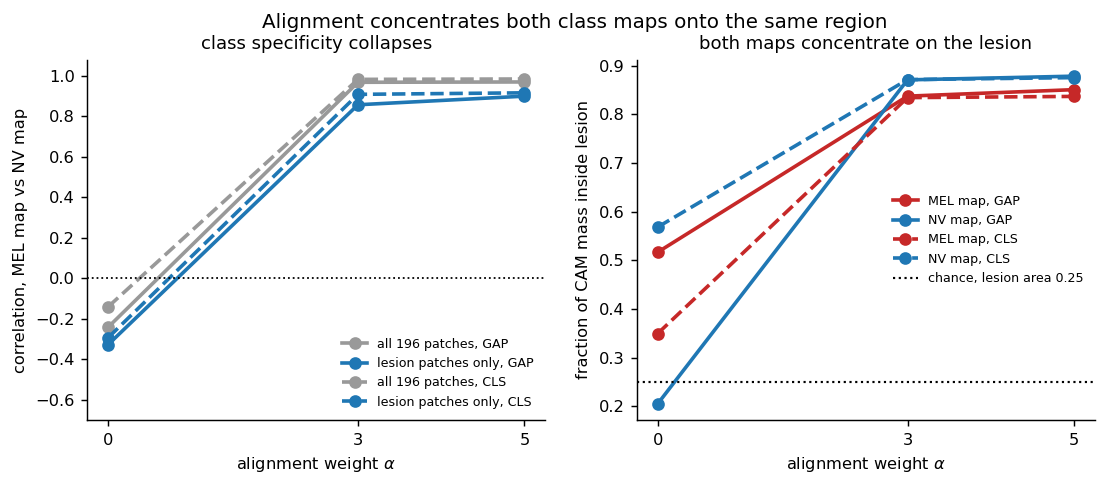

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
XT = [AV[c] for c in ALPHAS]

for pt, ls in [("gap", "-"), ("cls", "--")]:
    s = S1[S1.pooling == pt]
    for col, c, lab in [("r_global", "#999999", "all 196 patches"),
                        ("r_lesion", C_NV, "lesion patches only")]:
        ax[0].plot(XT, s.groupby("ckpt")[col].median().reindex(ALPHAS).values,
                   ls, marker="o", color=c, lw=2, ms=6,
                   label=f"{lab}, {pt.upper()}")
ax[0].axhline(0, color="k", ls=":", lw=1)
ax[0].set(xticks=XT, xlabel=r"alignment weight $\alpha$",
          ylabel="correlation, MEL map vs NV map", ylim=(-0.7, 1.08))
ax[0].legend(frameon=False, fontsize=7, loc="lower right")
ax[0].set_title("class specificity collapses", fontsize=10)

for pt, ls in [("gap", "-"), ("cls", "--")]:
    s = S1[S1.pooling == pt]
    for col, c, lab in [("mass_mel", C_MEL, "MEL"), ("mass_nv", C_NV, "NV")]:
        ax[1].plot(XT, s.groupby("ckpt")[col].median().reindex(ALPHAS).values,
                   ls, marker="o", color=c, lw=2, ms=6,
                   label=f"{lab} map, {pt.upper()}")
ax[1].axhline(AREA, color="k", ls=":", lw=1.2,
              label=f"chance, lesion area {AREA:.2f}")
ax[1].set(xticks=XT, xlabel=r"alignment weight $\alpha$",
          ylabel="fraction of CAM mass inside lesion")
ax[1].legend(frameon=False, fontsize=7)
ax[1].set_title("both maps concentrate on the lesion", fontsize=10)

fig.suptitle("Alignment concentrates both class maps onto the same region",
             fontsize=11)
fig.savefig(OUT / "fig_s1_collapse.png")
plt.show()

showing: ['ISIC_0024756', 'ISIC_0024886', 'ISIC_0025214']


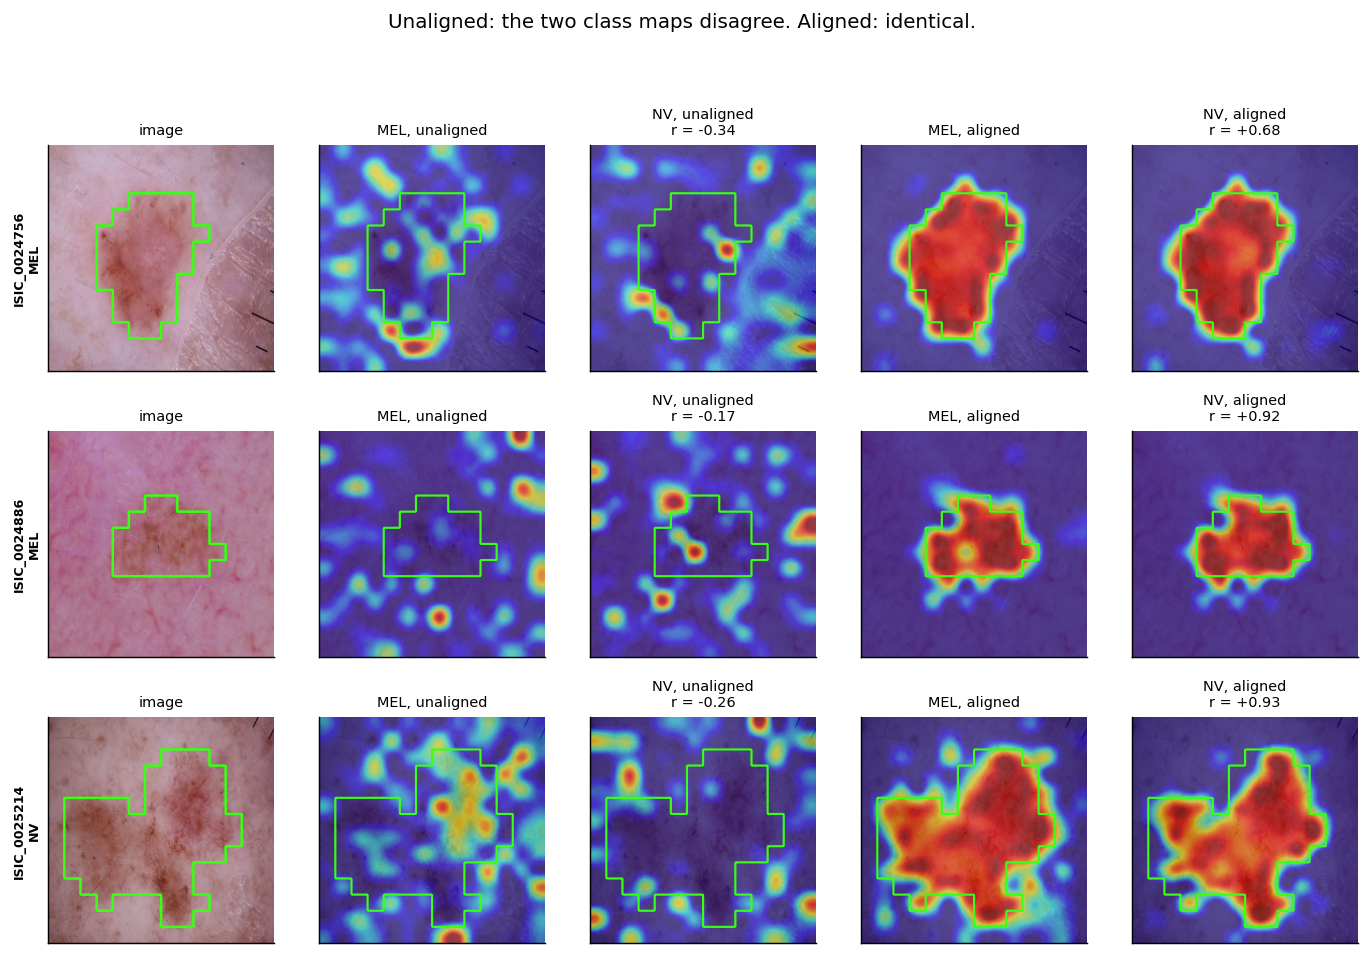

In [4]:
# Three images, MEL and NV side by side, unaligned against aligned.
SHOW = (eval_df[eval_df.gt_label == "MEL"].image_id.head(2).tolist()
        + eval_df[eval_df.gt_label == "NV"].image_id.head(1).tolist())
PT = "gap"
print("showing:", SHOW)
fig, ax = plt.subplots(len(SHOW), 5, figsize=(13, 2.7 * len(SHOW)))
ax = np.atleast_2d(ax)
for i, iid in enumerate(SHOW):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(native(r.image_rel_path), GEOMETRY)
    L224 = cv2.resize(LESION[iid].astype(np.float32), (CROP_SIZE, CROP_SIZE),
                      interpolation=cv2.INTER_NEAREST)
    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(L224, [0.5], colors="#39FF14", linewidths=1.4)
    ax[i, 0].set_ylabel(f"{iid}\n{r.gt_label}", fontsize=7, fontweight="bold")
    ax[i, 0].set_title("image", fontsize=8)
    for j, (ck, lab) in enumerate([("ha0", "unaligned"), ("ha5", "aligned")]):
        cm, cn = class_cams(load_model(PT, ck), to_tensor(native(r.image_rel_path)))
        rr = np.corrcoef(norm01(cm)[LESION[iid]], norm01(cn)[LESION[iid]])[0, 1]
        for k, (cam, cls) in enumerate([(cm, "MEL"), (cn, "NV")]):
            a = ax[i, 1 + 2 * j + k]
            a.imshow(rgb)
            a.imshow(cv2.resize(norm01(cam), (CROP_SIZE, CROP_SIZE),
                                interpolation=cv2.INTER_CUBIC),
                     cmap="jet", alpha=0.55, vmin=0, vmax=1)
            a.contour(L224, [0.5], colors="#39FF14", linewidths=1.2)
            a.set_title(f"{cls}, {lab}" + (f"\nr = {rr:+.2f}" if k else ""),
                        fontsize=8)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])

fig.suptitle("Unaligned: the two class maps disagree. Aligned: identical.",
             fontsize=11, y=1.0)
fig.savefig(OUT / "fig_s1_examples.png")
plt.show()

lesion area  original 0.133   shifted 0.138


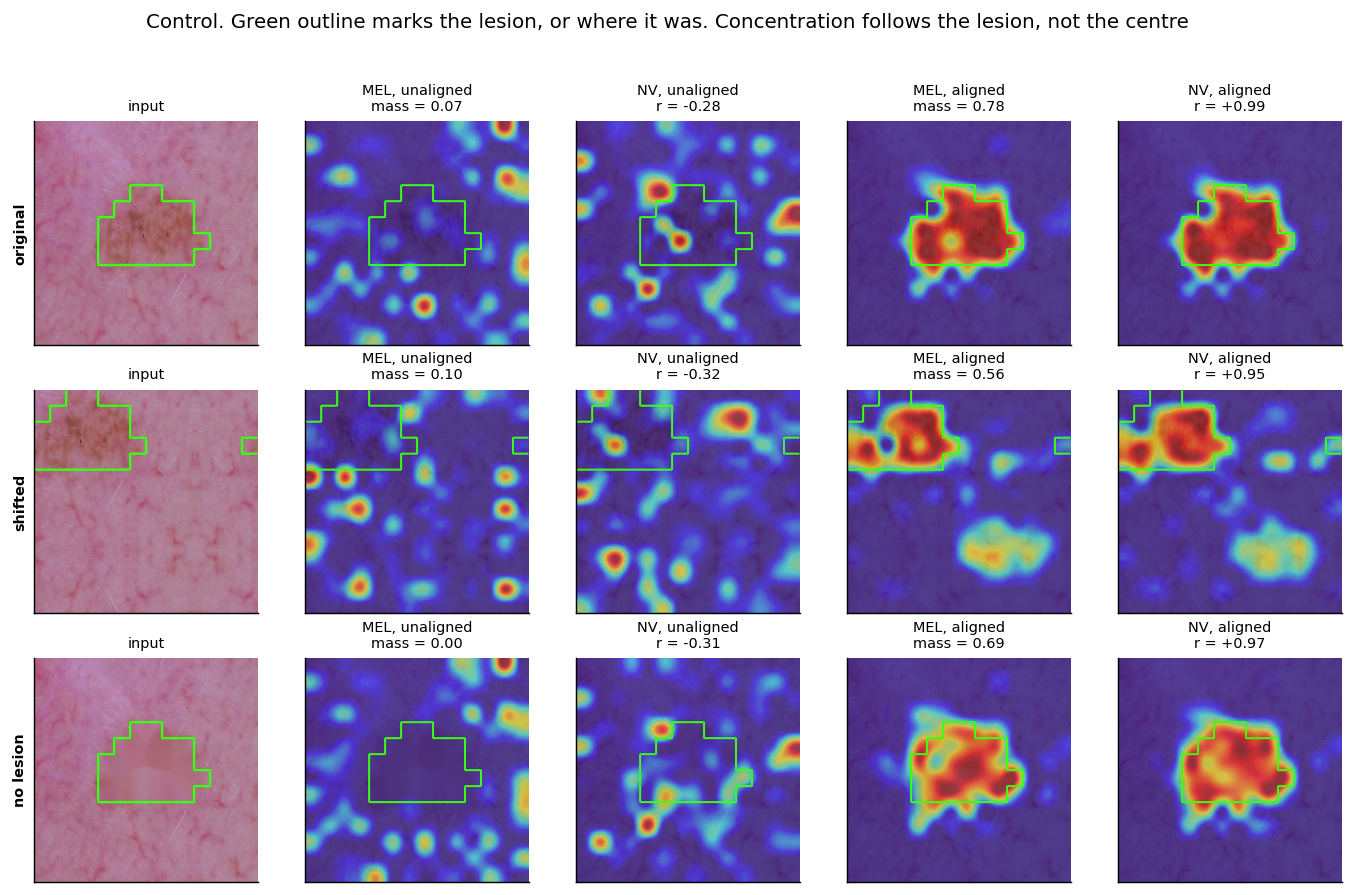

In [5]:
# =============================================================================
# CONTROL. Is the concentration lesion driven or centre driven.
#
#   original   lesion in place
#   shifted    lesion translated off centre, reflected fill
#   no lesion  lesion inpainted out at native scale, same framing
#
# Inpainting rather than cropping keeps scale and framing fixed, so the only
# thing that changes is the presence of the lesion.
# =============================================================================
def shift_img(img, frac=0.28):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, -frac * w], [0, 1, -frac * h]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def native_lesion(iid, shape):
    return cv2.resize(LESION[iid].astype(np.uint8), (shape[1], shape[0]),
                      interpolation=cv2.INTER_NEAREST).astype(bool)

def inpaint(img, mask, radius=9):
    from scipy.ndimage import binary_dilation
    m = binary_dilation(mask, iterations=2).astype(np.uint8) * 255
    return cv2.inpaint(img, m, radius, cv2.INPAINT_TELEA)

IID = SHOW[1]
r = eval_df.set_index("image_id").loc[IID]
img0 = native(r.image_rel_path)
Ln = native_lesion(IID, img0.shape[:2])

# grid masks for each condition, shifted one derived from the NATIVE mask
L_orig = LESION[IID]
L_shift = mask_to_cam_grid_geom(
    shift_img(Ln.astype(np.uint8) * 255) > 127, GEOMETRY) >= 0.5

CONDS = [("original",  img0,              L_orig),
         ("shifted",   shift_img(img0),   L_shift),
         ("no lesion", inpaint(img0, Ln), L_orig)]   # former lesion location

print(f"lesion area  original {L_orig.mean():.3f}   shifted {L_shift.mean():.3f}")
if L_shift.mean() > L_orig.mean() * 1.15:
    print("  NOTE reflected fill duplicated lesion content into the frame")

fig, ax = plt.subplots(3, 5, figsize=(13, 7.6))
for i, (cname, im, msk) in enumerate(CONDS):
    rgb = transform_rgb(im, GEOMETRY)
    m224 = cv2.resize(msk.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                      interpolation=cv2.INTER_NEAREST)
    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(m224, [0.5], colors="#39FF14", linewidths=1.3)
    ax[i, 0].set_ylabel(cname, fontsize=8, fontweight="bold")
    ax[i, 0].set_title("input", fontsize=8)
    for j, (ck, lab) in enumerate([("ha0", "unaligned"), ("ha5", "aligned")]):
        cm, cn = class_cams(load_model(PT, ck), to_tensor(im))
        rr = np.corrcoef(norm01(cm).ravel(), norm01(cn).ravel())[0, 1]
        mass = norm01(cm)[msk].sum() / (norm01(cm).sum() + 1e-8)
        for k, (cam, cls) in enumerate([(cm, "MEL"), (cn, "NV")]):
            a = ax[i, 1 + 2 * j + k]
            a.imshow(rgb)
            a.imshow(cv2.resize(norm01(cam), (CROP_SIZE, CROP_SIZE),
                                interpolation=cv2.INTER_CUBIC),
                     cmap="jet", alpha=0.55, vmin=0, vmax=1)
            a.contour(m224, [0.5], colors="#39FF14", linewidths=1.1)
            a.set_title(f"{cls}, {lab}\n" +
                        (f"r = {rr:+.2f}" if k else f"mass = {mass:.2f}"),
                        fontsize=8)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])

fig.suptitle("Control. Green outline marks the lesion, or where it was. "
             "Concentration follows the lesion, not the centre",
             fontsize=11, y=0.99)
fig.savefig(OUT / "fig_s1_control.png")
plt.show()

In [6]:
# =============================================================================
# Does the aligned model respond to the LESION or to the INPAINTING ARTEFACT.
#
# Telea reconstruction leaves a smooth texture free patch that is itself
# anomalous. Alignment may have taught the model to find anomalous regions
# rather than lesions.
#
#   bg inpaint   lesion intact, a matched area of background inpainted
#                mass stays on the lesion  -> genuine lesion response
#                mass moves to the patch   -> artefact detection
# =============================================================================
from scipy.ndimage import binary_dilation

def bg_patch(L, rng):
    """Background region matched in area to the lesion, grown from a seed."""
    free = ~binary_dilation(L, iterations=2)
    if free.sum() < L.sum():
        return None
    ys, xs = np.nonzero(free)
    i = rng.integers(len(ys))
    sel = np.zeros_like(L)
    sel[ys[i], xs[i]] = True
    while sel.sum() < L.sum():
        g = binary_dilation(sel) & free & ~sel
        if not g.any():
            break
        gy, gx = np.nonzero(g)
        sel[gy[rng.integers(len(gy))], gx[rng.integers(len(gx))]] = True
    return sel

rows = []
for _, rr_ in eval_df.iterrows():
    iid = rr_.image_id
    img0 = native(rr_.image_rel_path)
    L = LESION[iid]
    rng = np.random.default_rng(abs(hash(iid)) % (2**32))
    B = bg_patch(L, rng)
    if B is None or B.sum() < 3:
        continue
    Bn = cv2.resize(B.astype(np.uint8), (img0.shape[1], img0.shape[0]),
                    interpolation=cv2.INTER_NEAREST).astype(bool)
    im = inpaint(img0, Bn)
    for ck in ["ha0", "ha5"]:
        cm, cn = class_cams(load_model(PT, ck), to_tensor(im))
        a = norm01(cm)
        rows.append({"ckpt": ck, "image_id": iid,
                     "mass_lesion": float(a[L].sum() / (a.sum() + 1e-8)),
                     "mass_patch": float(a[B].sum() / (a.sum() + 1e-8)),
                     "area": float(L.mean())})

BG = pd.DataFrame(rows)
BG.to_csv(OUT / "s1_bg_inpaint.csv", index=False)
print("lesion intact, a matched background region inpainted\n")
print(BG.groupby("ckpt")[["mass_lesion", "mass_patch", "area"]]
        .median().round(3).to_string())
for ck in ["ha0", "ha5"]:
    s = BG[BG.ckpt == ck]
    _, pv = wilcoxon(s.mass_patch, s.area)
    print(f"  {ck} patch mass {s.mass_patch.median():.3f} vs area "
          f"{s.area.median():.3f}  diff {(s.mass_patch - s.area).median():+.3f}"
          f"  p {pv:.1e}")

lesion intact, a matched background region inpainted

      mass_lesion  mass_patch   area
ckpt                                
ha0         0.482       0.044  0.224
ha5         0.731       0.031  0.224
  ha0 patch mass 0.044 vs area 0.224  diff -0.145  p 6.0e-08
  ha5 patch mass 0.031 vs area 0.224  diff -0.157  p 6.0e-08


In [7]:
# =============================================================================
# Same three conditions across all images. The figure is one case, this is
# the evidence.
#
#   mass      fraction of CAM mass inside the lesion, or its former location.
#             Compare to the lesion area column, which is the chance level.
#   r         correlation between the two class maps.
#             Under 'no lesion' this asks whether the collapse needs a lesion.
# =============================================================================
rows = []
for _, rr_ in eval_df.iterrows():
    iid = rr_.image_id
    img0 = native(rr_.image_rel_path)
    Ln = native_lesion(iid, img0.shape[:2])
    L_orig = LESION[iid]
    L_shift = mask_to_cam_grid_geom(
        shift_img(Ln.astype(np.uint8) * 255) > 127, GEOMETRY) >= 0.5
    conds = [("original",  img0,              L_orig),
             ("shifted",   shift_img(img0),   L_shift),
             ("no lesion", inpaint(img0, Ln), L_orig)]
    for ck in ["ha0", "ha5"]:
        m = load_model(PT, ck)
        for cname, im, msk in conds:
            cm, cn = class_cams(m, to_tensor(im))
            a, b = norm01(cm), norm01(cn)
            ok = msk.sum() >= 3
            rows.append({
                "ckpt": ck, "cond": cname, "image_id": iid,
                "r_global": float(np.corrcoef(a.ravel(), b.ravel())[0, 1]),
                "mass_mel": float(a[msk].sum() / (a.sum() + 1e-8)) if ok else np.nan,
                "mass_nv": float(b[msk].sum() / (b.sum() + 1e-8)) if ok else np.nan,
                "area": float(msk.mean()) if ok else np.nan})

CTRL = pd.DataFrame(rows)
CTRL.to_csv(OUT / "s1_control.csv", index=False)

out = (CTRL.groupby(["ckpt", "cond"])[["r_global", "mass_mel", "mass_nv", "area"]]
       .median().round(3)
       .reindex([(c, k) for c in ["ha0", "ha5"]
                 for k in ["original", "shifted", "no lesion"]]))
out.columns = ["r MEL vs NV", "MEL mass", "NV mass", "lesion area"]
print(out.to_string())

print("\nmass above area means concentration on the lesion, not the centre")
print("under 'no lesion' the mask marks where the lesion WAS, so mass at or")
print("below area means the model no longer finds anything there\n")

for ck in ["ha0", "ha5"]:
    for cd in ["original", "shifted", "no lesion"]:
        s = CTRL[(CTRL.ckpt == ck) & (CTRL.cond == cd)].dropna(subset=["mass_mel"])
        if len(s) < 5:
            continue
        _, pv = wilcoxon(s.mass_mel, s.area)
        print(f"  {ck} {cd:10} MEL mass {s.mass_mel.median():.3f} vs area "
              f"{s.area.median():.3f}   diff {(s.mass_mel - s.area).median():+.3f}"
              f"   p {pv:.1e}")

print("\ncollapse under each condition, paired against original")
for ck in ["ha0", "ha5"]:
    for cd in ["shifted", "no lesion"]:
        q = (CTRL[CTRL.ckpt == ck].pivot_table(index="image_id", columns="cond",
                                               values="r_global")
             .reindex(columns=["original", cd]).dropna())
        _, pv = wilcoxon(q[cd], q.original)
        print(f"  {ck} {cd:10} {q.original.median():+.3f} -> {q[cd].median():+.3f}"
              f"   diff {(q[cd] - q.original).median():+.3f}   p {pv:.1e}")

                r MEL vs NV  MEL mass  NV mass  lesion area
ckpt cond                                                  
ha0  original        -0.241     0.517    0.205        0.250
     shifted         -0.267     0.548    0.174        0.235
     no lesion       -0.301     0.043    0.533        0.250
ha5  original         0.970     0.851    0.879        0.250
     shifted          0.910     0.649    0.584        0.235
     no lesion        0.899     0.816    0.857        0.250

mass above area means concentration on the lesion, not the centre
under 'no lesion' the mask marks where the lesion WAS, so mass at or
below area means the model no longer finds anything there

  ha0 original   MEL mass 0.517 vs area 0.250   diff +0.110   p 3.8e-05
  ha0 shifted    MEL mass 0.548 vs area 0.235   diff +0.256   p 5.8e-10
  ha0 no lesion  MEL mass 0.043 vs area 0.250   diff -0.180   p 1.1e-03
  ha5 original   MEL mass 0.851 vs area 0.250   diff +0.555   p 1.2e-10
  ha5 shifted    MEL mass 0.649 vs ar

In [8]:
# =============================================================================
# MECHANISM. Attention or gradient.
#
# CAM = reduce(A ⊙ G). Attention A is computed in the forward pass and is
# IDENTICAL for both classes. Only the gradient G carries class information.
#
# Replacing one factor by its spatial mean isolates the other's contribution.
#   attn_only = A ⊙ mean(G)   spatial structure from attention alone
#   grad_only = mean(A) ⊙ G   spatial structure from the gradient alone
#
# PREDICTION. At alpha 0 the gradient dominates, which is how the maps can be
# anticorrelated at all. At alpha 5 attention dominates, because alignment has
# sharpened it into a lesion mask that overrides the class specific gradient.
# =============================================================================
import torch.nn.functional as F

def cam_factors(model, x, cls_idx, block=BLOCK):
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        A = base.blocks[block].attn.last_attn
        G = torch.autograd.grad(logits[0, cls_idx], A, retain_graph=True)[0]

    mp = bool(getattr(base, "use_mean_pooling", False))
    h, w = base.patch_embed.patch_shape
    if mp:
        a, g = A[:, :, 1:, 1:], G[:, :, 1:, 1:]
        red = lambda t: F.relu(t.mean(1).sum(1))
        am, gm = a.mean(3, keepdim=True), g.mean(3, keepdim=True)
    else:
        a, g = A[:, :, 0, 1:], G[:, :, 0, 1:]
        red = lambda t: F.relu(t.mean(1))
        am, gm = a.mean(2, keepdim=True), g.mean(2, keepdim=True)

    f = lambda t: red(t)[0].detach().float().cpu().numpy().reshape(h, w)
    out = {"real": f(a * g), "attn_only": f(a * gm), "grad_only": f(am * g)}
    base.clear_xai_state()
    return out

def rc(x, y):
    x, y = np.asarray(x).ravel(), np.asarray(y).ravel()
    return float(np.corrcoef(x, y)[0, 1]) if x.std() > 1e-9 and y.std() > 1e-9 else np.nan

rows = []
for pt in POOLINGS:
    for ck in ["ha0", "ha5"]:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            x = to_tensor(native(r.image_rel_path))
            fm = cam_factors(m, x, MEL_IDX)
            fn = cam_factors(m, x, NV_IDX)
            rows.append({
                "pooling": pt, "ckpt": ck, "image_id": r.image_id,
                # how class specific is each object
                "r_real":  rc(fm["real"],      fn["real"]),
                "r_attn":  rc(fm["attn_only"], fn["attn_only"]),
                "r_grad":  rc(fm["grad_only"], fn["grad_only"]),
                # which surrogate reproduces the real map
                "fit_attn": rc(fm["real"], fm["attn_only"]),
                "fit_grad": rc(fm["real"], fm["grad_only"])})
    print(f"  {pt} done")

FAC = pd.DataFrame(rows)
FAC.to_csv(OUT / "s1_factor_decomposition.csv", index=False)

t = FAC.groupby(["pooling", "ckpt"])[
        ["r_real", "r_attn", "r_grad", "fit_attn", "fit_grad"]].median().round(3)
t.columns = ["r MEL/NV real", "r attn only", "r grad only",
             "fit to attn", "fit to grad"]
print("\nleft three: class specificity of each object, lower is more specific")
print("right two: which surrogate reproduces the real map, higher dominates\n")
print(t.to_string())

print("\nNaN counts, a NaN means that surrogate map was constant")
print(FAC.groupby(["pooling", "ckpt"])[
        ["r_real", "r_attn", "r_grad", "fit_attn", "fit_grad"]]
      .apply(lambda g: g.isna().sum()).to_string())
      
print("\ndominance, fit_attn minus fit_grad, positive means attention dominates")
for (pt, ck), g in FAC.groupby(["pooling", "ckpt"]):
    q = g[["fit_attn", "fit_grad"]].dropna()
    if len(q) < 5:
        print(f"  {pt.upper():4} {ck}  n {len(q)}, too few")
        continue
    d = q.fit_attn - q.fit_grad
    _, pv = wilcoxon(q.fit_attn, q.fit_grad)
    print(f"  {pt.upper():4} {ck}  {d.median():+.3f}   p {pv:.1e}   n {len(q)}   "
          f"{'ATTENTION' if d.median() > 0 else 'GRADIENT'} dominates")

  gap done
  cls done

left three: class specificity of each object, lower is more specific
right two: which surrogate reproduces the real map, higher dominates

              r MEL/NV real  r attn only  r grad only  fit to attn  fit to grad
pooling ckpt                                                                   
cls     ha0          -0.140       -0.096       -0.418        0.104        0.654
        ha5           0.985        0.439        0.992        0.408        0.984
gap     ha0          -0.241        0.013       -0.315        0.593        0.792
        ha5           0.970       -0.010        0.984       -0.316        0.983

NaN counts, a NaN means that surrogate map was constant
              r_real  r_attn  r_grad  fit_attn  fit_grad
pooling ckpt                                            
cls     ha0        0       4       0         4         0
        ha5        0      13       0         9         0
gap     ha0        0      24       0        10         0
        ha5     

  gap ha0 done
  gap ha5 done
  cls ha0 done
  cls ha5 done

beta 1.0 is the current construction, beta 0 is pure gradient

                   r_lesion  lesion_auc  mass_in_lesion
pooling ckpt beta                                      
cls     ha0  0.00    -0.342       0.416           0.237
             0.25    -0.406       0.468           0.334
             0.50    -0.397       0.512           0.435
             0.75    -0.345       0.539           0.501
             1.00    -0.293       0.577           0.571
        ha5  0.00     0.963       0.991           0.900
             0.25     0.962       0.991           0.886
             0.50     0.953       0.991           0.880
             0.75     0.936       0.990           0.873
             1.00     0.917       0.988           0.867
gap     ha0  0.00    -0.334       0.500           0.238
             0.25    -0.336       0.531           0.260
             0.50    -0.366       0.545           0.294
             0.75    -0.338       0.

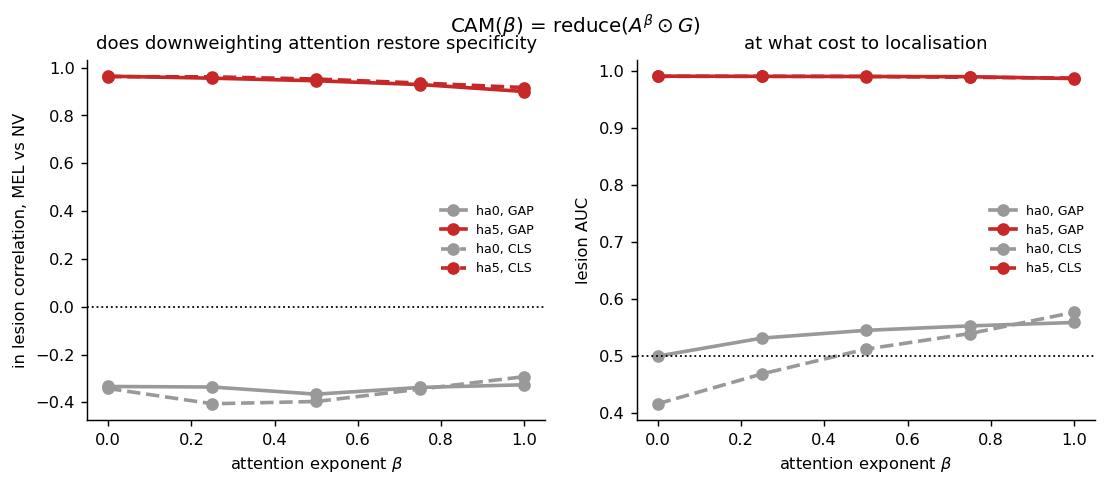

In [9]:
# =============================================================================
# CAN THE COLLAPSE BE UNDONE WITHOUT RETRAINING.
#
#   CAM(beta) = reduce(A^beta ⊙ G)
#
# beta = 1 is the current construction. beta = 0 removes attention entirely,
# leaving a pure gradient map. If attention is what homogenises the two class
# maps, lowering beta should restore class specificity.
#
# The cost to watch is localisation. Attention supplies the spatial coherence,
# so a pure gradient map may be specific and useless.
# =============================================================================
from sklearn.metrics import roc_auc_score

def cam_beta(model, x, cls_idx, beta, block=BLOCK):
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        A = base.blocks[block].attn.last_attn
        G = torch.autograd.grad(logits[0, cls_idx], A, retain_graph=True)[0]
    mp = bool(getattr(base, "use_mean_pooling", False))
    h, w = base.patch_embed.patch_shape
    if mp:
        a, g = A[:, :, 1:, 1:], G[:, :, 1:, 1:]
        v = F.relu(((a.clamp_min(1e-12) ** beta) * g).mean(1).sum(1))
    else:
        a, g = A[:, :, 0, 1:], G[:, :, 0, 1:]
        v = F.relu(((a.clamp_min(1e-12) ** beta) * g).mean(1))
    base.clear_xai_state()
    return v[0].detach().float().cpu().numpy().reshape(h, w)

BETAS = [0.0, 0.25, 0.5, 0.75, 1.0]
rows = []
for pt in POOLINGS:
    for ck in ["ha0", "ha5"]:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            L = LESION[r.image_id]
            if not (0 < L.sum() < L.size):
                continue
            tgt_idx = MEL_IDX if r.gt_label == "MEL" else NV_IDX
            for b in BETAS:
                cm = cam_beta(m, to_tensor(native(r.image_rel_path)), MEL_IDX, b)
                cn = cam_beta(m, to_tensor(native(r.image_rel_path)), NV_IDX, b)
                tg = cm if tgt_idx == MEL_IDX else cn
                a, bb = norm01(cm), norm01(cn)
                rows.append({
                    "pooling": pt, "ckpt": ck, "beta": b,
                    "image_id": r.image_id,
                    "r_lesion": rc(a[L], bb[L]),
                    "lesion_auc": (float(roc_auc_score(L.ravel(),
                                                       norm01(tg).ravel()))
                                   if norm01(tg).std() > 1e-9 else np.nan),
                    "mass_in_lesion": float(norm01(tg)[L].sum()
                                            / (norm01(tg).sum() + 1e-8))})
        print(f"  {pt} {ck} done")

BS = pd.DataFrame(rows)
BS.to_csv(OUT / "s1_beta_sweep.csv", index=False)

print("\nbeta 1.0 is the current construction, beta 0 is pure gradient\n")
print(BS.groupby(["pooling", "ckpt", "beta"])
        [["r_lesion", "lesion_auc", "mass_in_lesion"]]
        .median().round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for pt, ls in [("gap", "-"), ("cls", "--")]:
    for ck, c in [("ha0", "#999999"), ("ha5", C_MEL)]:
        s = BS[(BS.pooling == pt) & (BS.ckpt == ck)].groupby("beta")
        ax[0].plot(BETAS, s.r_lesion.median().reindex(BETAS), ls, marker="o",
                   color=c, lw=2, ms=6, label=f"{ck}, {pt.upper()}")
        ax[1].plot(BETAS, s.lesion_auc.median().reindex(BETAS), ls, marker="o",
                   color=c, lw=2, ms=6, label=f"{ck}, {pt.upper()}")
ax[0].axhline(0, color="k", ls=":", lw=1)
ax[0].set(xlabel=r"attention exponent $\beta$",
          ylabel="in lesion correlation, MEL vs NV")
ax[0].set_title("does downweighting attention restore specificity", fontsize=10)
ax[1].axhline(0.5, color="k", ls=":", lw=1)
ax[1].set(xlabel=r"attention exponent $\beta$", ylabel="lesion AUC")
ax[1].set_title("at what cost to localisation", fontsize=10)
for a in ax:
    a.legend(frameon=False, fontsize=7)
fig.suptitle(r"CAM($\beta$) = reduce($A^\beta \odot G$)", fontsize=11)
fig.savefig(OUT / "fig_s1_beta.png")
plt.show()

In [10]:
# =============================================================================
# MARGIN CAM. The difference formed BEFORE the ReLU.
#
# The two class gradients are near parallel at ha5, r = 0.98. Their DIFFERENCE
# is the margin gradient, d(y_mel - y_nv)/dA, which is what drives the
# decision. Small in magnitude, but the model still classifies at AUC 0.97,
# so it is not zero.
#
# This is FinerCAM at alpha=1 in the ATTENTION pathway. Section 3 tested the
# activation pathway. Section 2 tested post hoc subtraction, which is a
# different and lossy operation.
# =============================================================================
from sklearn.metrics import roc_auc_score
from scipy.ndimage import center_of_mass

def grad_tensors(model, x, block=BLOCK):
    """Raw pre-ReLU gradients for both classes, plus the attention."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        A = base.blocks[block].attn.last_attn
        Gm = torch.autograd.grad(logits[0, MEL_IDX], A, retain_graph=True)[0]
        Gn = torch.autograd.grad(logits[0, NV_IDX], A, retain_graph=True)[0]
    base.clear_xai_state()
    return A.detach(), Gm.detach(), Gn.detach()

def reduce_map(model, A, G):
    base = _unwrap_model(model)
    h, w = base.patch_embed.patch_shape
    if bool(getattr(base, "use_mean_pooling", False)):
        v = F.relu((A[:, :, 1:, 1:] * G[:, :, 1:, 1:]).mean(1).sum(1))
    else:
        v = F.relu((A[:, :, 0, 1:] * G[:, :, 0, 1:]).mean(1))
    return v[0].float().cpu().numpy().reshape(h, w)

def centre_map(L):
    cy, cx = center_of_mass(L.astype(float))
    yy, xx = np.mgrid[0:CAM_GRID, 0:CAM_GRID]
    return norm01(-np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2))

rows = []
for pt in POOLINGS:
    for ck in ["ha0", "ha5"]:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            L = LESION[r.image_id]
            if not (0 < L.sum() < L.size):
                continue
            A, Gm, Gn = grad_tensors(m, to_tensor(native(r.image_rel_path)))
            gm, gn = Gm.flatten(), Gn.flatten()
            sh, df = (Gm + Gn) / 2, (Gm - Gn) / 2
            tgt = reduce_map(m, A, Gm if r.gt_label == "MEL" else Gn)
            mar = reduce_map(m, A, Gm - Gn)      # margin, MEL minus NV
            rows.append({
                "pooling": pt, "ckpt": ck, "image_id": r.image_id,
                "gt": r.gt_label,
                "cos_grad": float(F.cosine_similarity(gm, gn, dim=0)),
                "diff_energy": float(df.norm() / (sh.norm() + 1e-12)),
                "margin_nonzero": float((mar > 1e-8).mean()),
                "margin_in_lesion": float(norm01(mar)[L].sum()
                                          / (norm01(mar).sum() + 1e-8)),
                "margin_lesion_auc": (float(roc_auc_score(L.ravel(),
                                                          norm01(mar).ravel()))
                                      if mar.std() > 1e-9 else np.nan),
                "target_lesion_auc": (float(roc_auc_score(L.ravel(),
                                                          norm01(tgt).ravel()))
                                      if tgt.std() > 1e-9 else np.nan),
                "r_margin_vs_target": (float(np.corrcoef(norm01(mar).ravel(),
                                                         norm01(tgt).ravel())[0, 1])
                                       if mar.std() > 1e-9 and tgt.std() > 1e-9
                                       else np.nan)})
        print(f"  {pt} {ck} done")

MG = pd.DataFrame(rows)
MG.to_csv(OUT / "s1_margin_cam.csv", index=False)

t = MG.groupby(["pooling", "ckpt"])[
        ["cos_grad", "diff_energy", "margin_nonzero", "margin_in_lesion",
         "margin_lesion_auc", "target_lesion_auc", "r_margin_vs_target"]
    ].median().round(3)
print("\ncos_grad          +1 parallel, -1 anti parallel")
print("diff_energy       ||G_mel - G_nv|| / ||G_mel + G_nv||, discriminative share")
print("margin_nonzero    fraction of patches surviving the ReLU")
print("r_margin_vs_tgt   if near 1 the margin map is just the target map\n")
print(t.to_string())

  gap ha0 done
  gap ha5 done
  cls ha0 done
  cls ha5 done

cos_grad          +1 parallel, -1 anti parallel
diff_energy       ||G_mel - G_nv|| / ||G_mel + G_nv||, discriminative share
margin_nonzero    fraction of patches surviving the ReLU
r_margin_vs_tgt   if near 1 the margin map is just the target map

              cos_grad  diff_energy  margin_nonzero  margin_in_lesion  margin_lesion_auc  target_lesion_auc  r_margin_vs_target
pooling ckpt                                                                                                                   
cls     ha0     -0.585        1.948           0.594             0.434              0.548              0.577              -0.138
        ha5      0.705        0.426           0.717             0.283              0.648              0.988               0.099
gap     ha0     -0.352        1.440           0.628             0.563              0.690              0.559              -0.237
        ha5      0.608        0.497           0.926

In [11]:
# Clinician MEL feature union per image, at grid resolution.
qcp = pd.read_csv(REPO / "results" / "annotation_qc" / GEOMETRY /
                  "annotation_qc_manifest.csv").query("qc_pass")

def mel_union_grid(iid):
    sub = qcp[(qcp.Image_ID == iid) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for p in sub.mask_path:
        m = np.array(Image.open(p).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return mask_to_cam_grid_geom(acc, GEOMETRY) >= 0.5

HUM = {i: mel_union_grid(i) for i in eval_df.image_id}
HUM = {k: v for k, v in HUM.items()
       if v is not None and k in LESION and LESION[k].sum() >= 8
       and 0 < v[LESION[k]].sum() < LESION[k].sum()}
print(f"{len(HUM)} images with a usable in-lesion MEL union")

31 images with a usable in-lesion MEL union


In [12]:
# Does the margin map beat the target map, and the centre oracle, in lesion.
rows = []
for pt in POOLINGS:
    m = load_model(pt, "ha5")
    for iid, u in HUM.items():
        L = LESION[iid]
        ui = u[L]
        if ui.sum() == 0 or ui.all():
            continue
        r = eval_df.set_index("image_id").loc[iid]
        A, Gm, Gn = grad_tensors(m, to_tensor(native(r.image_rel_path)))
        tgt = norm01(reduce_map(m, A, Gm if r.gt_label == "MEL" else Gn))
        mar = norm01(reduce_map(m, A, Gm - Gn))
        cen = centre_map(L)
        f = lambda v: (float(roc_auc_score(ui.astype(int), v[L]))
                       if v[L].std() > 1e-9 else np.nan)
        rows.append({"pooling": pt, "image_id": iid,
                     "target": f(tgt), "margin": f(mar), "centre": f(cen)})

HM = pd.DataFrame(rows)
print("\nin lesion AUC against clinician MEL union, ha5\n")
print(HM.groupby("pooling")[["target", "margin", "centre"]]
        .agg(["median", "count"]).round(3).to_string())
for pt, g in HM.groupby("pooling"):
    q = g[["margin", "target"]].dropna()
    if len(q) >= 5:
        _, pv = wilcoxon(q.margin, q.target)
        print(f"  {pt.upper()} margin vs target  "
              f"{(q.margin - q.target).median():+.3f}  p {pv:.1e}  n {len(q)}")
    q = g[["margin", "centre"]].dropna()
    if len(q) >= 5:
        _, pv = wilcoxon(q.margin, q.centre)
        print(f"  {pt.upper()} margin vs centre  "
              f"{(q.margin - q.centre).median():+.3f}  p {pv:.1e}  n {len(q)}")


in lesion AUC against clinician MEL union, ha5

        target       margin       centre      
        median count median count median count
pooling                                       
cls      0.731    31  0.419    31  0.828    31
gap      0.743    31  0.278    24  0.828    31
  CLS margin vs target  -0.294  p 6.0e-07  n 31
  CLS margin vs centre  -0.447  p 2.8e-09  n 31
  GAP margin vs target  -0.549  p 1.2e-07  n 24
  GAP margin vs centre  -0.553  p 1.2e-07  n 24


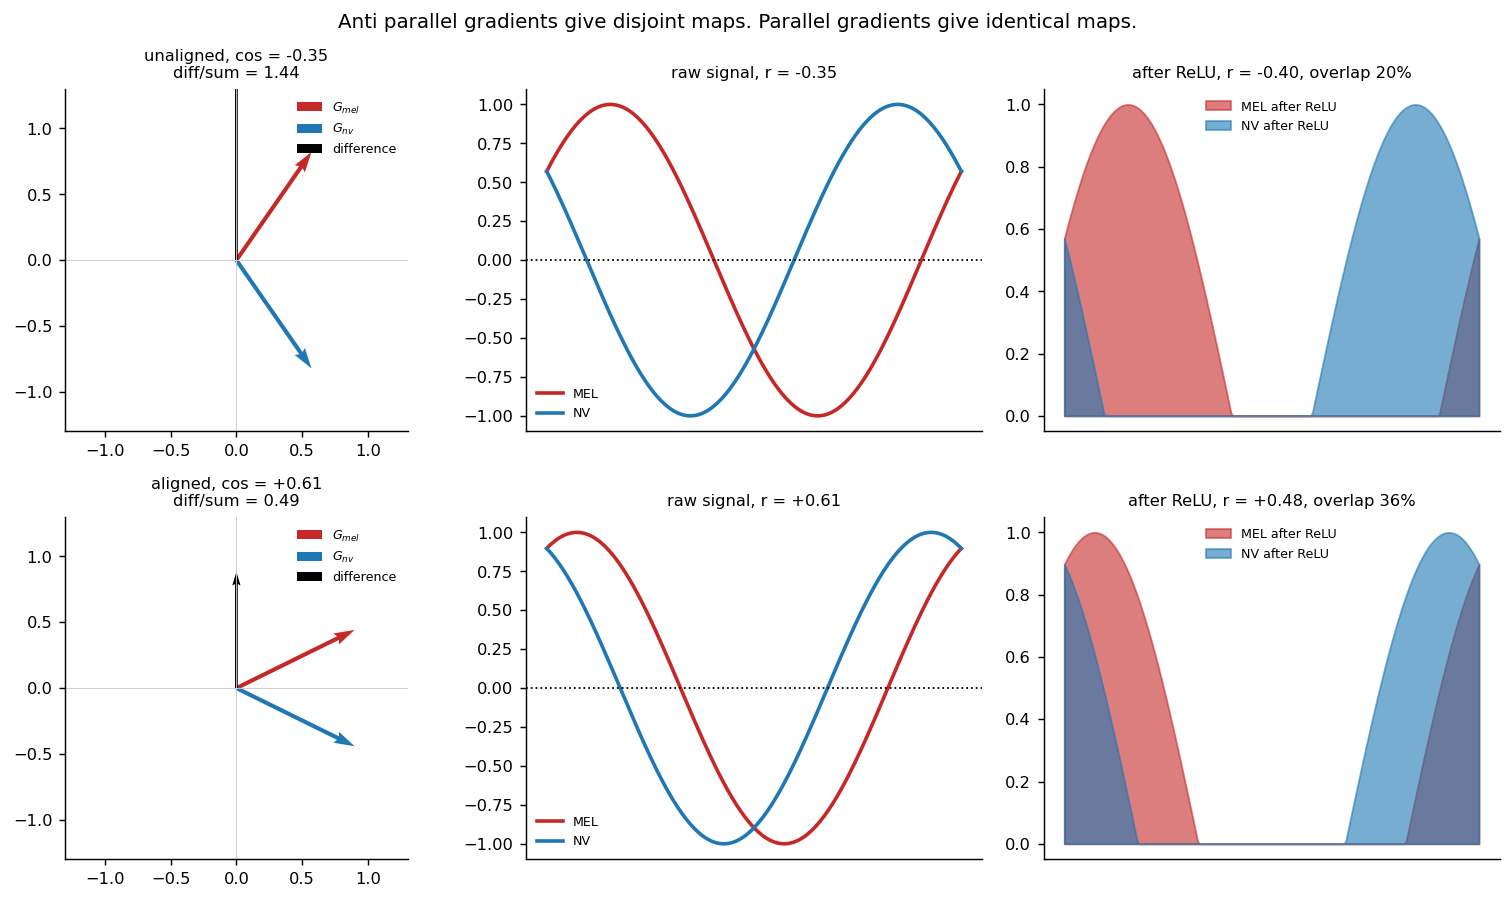

In [13]:
# =============================================================================
# The geometry, drawn. Two class gradients as vectors.
# ha0 anti parallel, ha5 nearly parallel. The ReLU then cuts each in half.
# =============================================================================
fig, ax = plt.subplots(2, 3, figsize=(12, 7))
CASES = [("unaligned, cos = -0.35", -0.35, 0), ("aligned, cos = +0.61", 0.61, 1)]

for name, cs, row in CASES:
    th = np.arccos(cs) / 2
    vm = np.array([np.cos(th), np.sin(th)])
    vn = np.array([np.cos(-th), np.sin(-th)])

    a = ax[row, 0]
    a.quiver(0, 0, *vm, angles="xy", scale_units="xy", scale=1,
             color=C_MEL, width=.012, label="$G_{mel}$")
    a.quiver(0, 0, *vn, angles="xy", scale_units="xy", scale=1,
             color=C_NV, width=.012, label="$G_{nv}$")
    a.quiver(0, 0, *(vm - vn), angles="xy", scale_units="xy", scale=1,
             color="k", width=.008, label="difference")
    a.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
    a.set_title(f"{name}\ndiff/sum = {np.sqrt((1-cs)/(1+cs)):.2f}", fontsize=9)
    a.legend(fontsize=7, frameon=False)
    a.axhline(0, color="#ccc", lw=.5); a.axvline(0, color="#ccc", lw=.5)

    x = np.linspace(0, 2 * np.pi, 200)
    gm, gn = np.cos(x - th), np.cos(x + th)
    a = ax[row, 1]
    a.plot(x, gm, color=C_MEL, lw=2, label="MEL")
    a.plot(x, gn, color=C_NV, lw=2, label="NV")
    a.axhline(0, color="k", ls=":", lw=1)
    a.set_title(f"raw signal, r = {np.corrcoef(gm, gn)[0,1]:+.2f}", fontsize=9)
    a.legend(fontsize=7, frameon=False); a.set_xticks([])

    rm, rn = np.maximum(gm, 0), np.maximum(gn, 0)
    ov = ((rm > 0) & (rn > 0)).mean()
    a = ax[row, 2]
    a.fill_between(x, rm, color=C_MEL, alpha=.6, label="MEL after ReLU")
    a.fill_between(x, rn, color=C_NV, alpha=.6, label="NV after ReLU")
    a.set_title(f"after ReLU, r = {np.corrcoef(rm, rn)[0,1]:+.2f}, "
                f"overlap {ov:.0%}", fontsize=9)
    a.legend(fontsize=7, frameon=False); a.set_xticks([])

fig.suptitle("Anti parallel gradients give disjoint maps. "
             "Parallel gradients give identical maps.", fontsize=11)
fig.tight_layout()
fig.savefig(OUT / "fig_gradient_geometry.png")
plt.show()

  gap ha0 done
  gap ha5 done
  cls ha0 done
  cls ha5 done

cosine between MEL and NV at each stage, 1 = indistinguishable

              1_raw_grad  2_times_attn  3_head_mean  4_query_sum  5_after_relu
pooling ckpt                                                                  
cls     ha0       -0.585        -0.746       -0.852       -0.852         0.022
        ha5        0.707         0.767        0.959        0.959         0.991
gap     ha0       -0.352        -0.438       -0.685       -0.712         0.072
        ha5        0.610         0.564        0.852        0.864         0.979


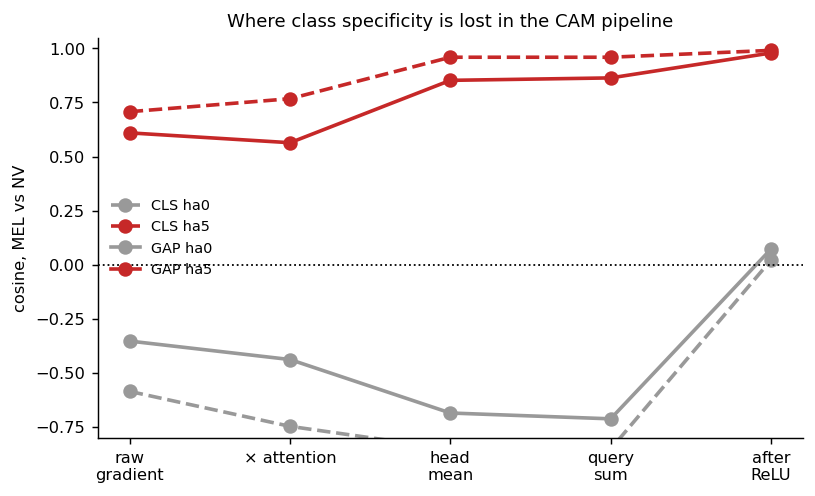

In [14]:
# =============================================================================
# Class separation measured at every stage of the CAM pipeline.
# Raw gradients are only moderately parallel. The final maps are near
# identical. This locates the step responsible.
# =============================================================================
def cos(a, b):
    a, b = a.flatten().float(), b.flatten().float()
    return float(F.cosine_similarity(a, b, dim=0))

rows = []
for pt in POOLINGS:
    mp = POOLINGS[pt] == "mean"
    for ck in ["ha0", "ha5"]:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            A, Gm, Gn = grad_tensors(m, to_tensor(native(r.image_rel_path)))
            if mp:
                a = A[:, :, 1:, 1:]
                gm, gn = Gm[:, :, 1:, 1:], Gn[:, :, 1:, 1:]
            else:
                a = A[:, :, 0, 1:]
                gm, gn = Gm[:, :, 0, 1:], Gn[:, :, 0, 1:]
            pm, pn = a * gm, a * gn
            hm, hn = pm.mean(1), pn.mean(1)
            qm, qn = (hm.sum(1), hn.sum(1)) if mp else (hm, hn)
            rows.append({
                "pooling": pt, "ckpt": ck, "image_id": r.image_id,
                "1_raw_grad": cos(gm, gn),
                "2_times_attn": cos(pm, pn),
                "3_head_mean": cos(hm, hn),
                "4_query_sum": cos(qm, qn),
                "5_after_relu": cos(F.relu(qm), F.relu(qn))})
        print(f"  {pt} {ck} done")

ST = pd.DataFrame(rows)
ST.to_csv(OUT / "s1_pipeline_stages.csv", index=False)
COLS = ["1_raw_grad", "2_times_attn", "3_head_mean", "4_query_sum", "5_after_relu"]
print("\ncosine between MEL and NV at each stage, 1 = indistinguishable\n")
print(ST.groupby(["pooling", "ckpt"])[COLS].median().round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
for (pt, ck), g in ST.groupby(["pooling", "ckpt"]):
    ax.plot(range(5), g[COLS].median().values, marker="o", lw=2, ms=7,
            ls="-" if pt == "gap" else "--",
            color="#999999" if ck == "ha0" else C_MEL,
            label=f"{pt.upper()} {ck}")
ax.axhline(0, color="k", ls=":", lw=1)
ax.set(xticks=range(5),
       xticklabels=["raw\ngradient", "× attention", "head\nmean",
                    "query\nsum", "after\nReLU"],
       ylabel="cosine, MEL vs NV", ylim=(-0.8, 1.05))
ax.legend(frameon=False, fontsize=8)
ax.set_title("Where class specificity is lost in the CAM pipeline", fontsize=10)
fig.savefig(OUT / "fig_pipeline_stages.png")
plt.show()

  gap ha0 done
  gap ha5 done
  cls ha0 done
  cls ha5 done

per head cosine, MEL vs NV. Spread is what matters.

               mean     sd    min    q25  median    max
pooling ckpt                                           
cls     ha0  -0.397  0.503 -0.998 -0.818  -0.528  0.960
        ha5   0.699  0.349 -0.805  0.695   0.817  0.976
gap     ha0  -0.373  0.362 -0.977 -0.676  -0.441  0.587
        ha5   0.639  0.206 -0.367  0.560   0.676  0.961


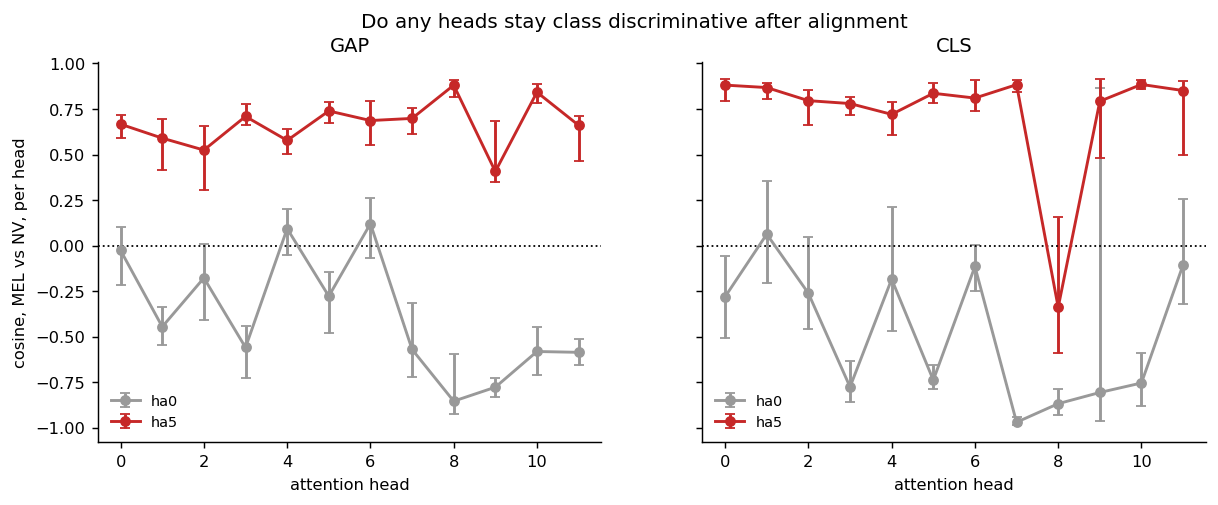

In [15]:
# =============================================================================
# Head averaging caused the largest single loss of class specificity.
# It is a consensus operator: it amplifies what heads agree on and cancels
# what they disagree about. If class information survives in a minority of
# heads, uniform averaging destroys it.
#
# This measures the per head cosine distribution. A wide spread means some
# heads remain discriminative and a weighted reduction could recover them.
# A tight spread near the mean means every head collapsed and nothing can.
# =============================================================================
def head_maps(model, x, block=BLOCK):
    """Per head CAM contribution for both classes, before head averaging."""
    base = _unwrap_model(model)
    A, Gm, Gn = grad_tensors(model, x, block)
    if bool(getattr(base, "use_mean_pooling", False)):
        a, gm, gn = A[:, :, 1:, 1:], Gm[:, :, 1:, 1:], Gn[:, :, 1:, 1:]
        return (a * gm).sum(2)[0], (a * gn).sum(2)[0]      # [H, K]
    a, gm, gn = A[:, :, 0, 1:], Gm[:, :, 0, 1:], Gn[:, :, 0, 1:]
    return (a * gm)[0], (a * gn)[0]

rows = []
for pt in POOLINGS:
    for ck in ["ha0", "ha5"]:
        m = load_model(pt, ck)
        for _, r in eval_df.iterrows():
            hm, hn = head_maps(m, to_tensor(native(r.image_rel_path)))
            c = F.cosine_similarity(hm, hn, dim=1).cpu().numpy()
            for h, v in enumerate(c):
                rows.append({"pooling": pt, "ckpt": ck, "head": h,
                             "image_id": r.image_id, "cos": float(v)})
        print(f"  {pt} {ck} done")

HD = pd.DataFrame(rows)
HD.to_csv(OUT / "s1_per_head.csv", index=False)

print("\nper head cosine, MEL vs NV. Spread is what matters.\n")
print(HD.groupby(["pooling", "ckpt"]).cos
        .agg(mean="mean", sd="std", min="min", q25=lambda s: s.quantile(.25),
             median="median", max="max").round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for i, pt in enumerate(POOLINGS):
    for ck, c in [("ha0", "#999999"), ("ha5", C_MEL)]:
        s = (HD[(HD.pooling == pt) & (HD.ckpt == ck)]
             .groupby("head").cos.describe())
        ax[i].errorbar(s.index, s["50%"], yerr=[s["50%"] - s["25%"],
                                                s["75%"] - s["50%"]],
                       fmt="o-", color=c, lw=1.6, ms=5, capsize=3, label=ck)
    ax[i].axhline(0, color="k", ls=":", lw=1)
    ax[i].set(xlabel="attention head", title=f"{pt.upper()}")
    ax[i].legend(frameon=False, fontsize=8)
ax[0].set_ylabel("cosine, MEL vs NV, per head")
fig.suptitle("Do any heads stay class discriminative after alignment",
             fontsize=11)
fig.savefig(OUT / "fig_per_head.png")
plt.show()

In [16]:
# =============================================================================
# HEAD WEIGHTED CAM. Replace the uniform head mean with a weighting that
# favours heads where the two class gradients disagree.
#
#   w_h  proportional to  (1 - cos_h) / 2,  clipped at zero
#
# The weights depend only on the two gradients, both available at inference,
# so this is a valid post hoc method. No retraining, no ground truth.
#
# Watch both columns. Specificity without localisation is worthless.
# =============================================================================
def cam_head_weighted(model, x, mode="uniform", topk=3, block=BLOCK):
    base = _unwrap_model(model)
    h, w = base.patch_embed.patch_shape
    hm, hn = head_maps(model, x, block)                    # [H, K] each
    c = F.cosine_similarity(hm, hn, dim=1)                 # [H]

    if mode == "uniform":
        wt = torch.ones_like(c)
    elif mode == "disagree":
        wt = ((1 - c) / 2).clamp_min(0)
    elif mode == "topk":
        wt = torch.zeros_like(c)
        wt[c.argsort()[:topk]] = 1.0                       # most disagreeing
    else:
        raise ValueError(mode)
    wt = wt / (wt.sum() + 1e-12)

    f = lambda t: F.relu((wt[:, None] * t).sum(0)).cpu().numpy().reshape(h, w)
    return f(hm), f(hn)

MODES = ["uniform", "disagree", "topk"]
rows = []
for pt in POOLINGS:
    m = load_model(pt, "ha5")
    for _, r in eval_df.iterrows():
        L = LESION[r.image_id]
        x = to_tensor(native(r.image_rel_path))
        u = HUM.get(r.image_id)
        ui = u[L] if u is not None else None
        for md in MODES:
            cm, cn = cam_head_weighted(m, x, md)
            a, b = norm01(cm), norm01(cn)
            tg = a if r.gt_label == "MEL" else b
            rows.append({
                "pooling": pt, "mode": md, "image_id": r.image_id,
                "r_lesion": (float(np.corrcoef(a[L], b[L])[0, 1])
                             if a[L].std() > 1e-9 and b[L].std() > 1e-9 else np.nan),
                "lesion_auc": (float(roc_auc_score(L.ravel(), tg.ravel()))
                               if tg.std() > 1e-9 else np.nan),
                "human_in": (float(roc_auc_score(ui.astype(int), tg[L]))
                             if ui is not None and ui.sum() > 0 and not ui.all()
                             and tg[L].std() > 1e-9 else np.nan)})
    print(f"  {pt} done")

HW = pd.DataFrame(rows)
HW.to_csv(OUT / "s1_head_weighted.csv", index=False)

print("\nha5. uniform is the current construction. centre oracle = 0.828\n")
print(HW.groupby(["pooling", "mode"])[["r_lesion", "lesion_auc", "human_in"]]
        .median().round(3).reindex(
            [(p, m) for p in POOLINGS for m in MODES]).to_string())

print("\npaired against uniform")
for pt in POOLINGS:
    for md in ["disagree", "topk"]:
        for col in ["r_lesion", "lesion_auc", "human_in"]:
            q = (HW[HW.pooling == pt].pivot_table(index="image_id",
                                                  columns="mode", values=col)
                 .reindex(columns=["uniform", md]).dropna())
            if len(q) < 5:
                continue
            _, pv = wilcoxon(q[md], q.uniform)
            print(f"  {pt.upper()} {md:9} {col:11} "
                  f"{q.uniform.median():+.3f} -> {q[md].median():+.3f}  "
                  f"p {pv:.1e}  n {len(q)}")

  gap done
  cls done

ha5. uniform is the current construction. centre oracle = 0.828

                  r_lesion  lesion_auc  human_in
pooling mode                                    
gap     uniform      0.900       0.988     0.743
        disagree     0.811       0.990     0.726
        topk         0.471       0.974     0.720
cls     uniform      0.917       0.988     0.731
        disagree     0.878       0.989     0.733
        topk         0.386       0.916     0.639

paired against uniform
  GAP disagree  r_lesion    +0.900 -> +0.811  p 1.7e-07  n 34
  GAP disagree  lesion_auc  +0.988 -> +0.990  p 3.0e-01  n 34
  GAP disagree  human_in    +0.743 -> +0.726  p 2.2e-01  n 31
  GAP topk      r_lesion    +0.900 -> +0.471  p 1.2e-10  n 34
  GAP topk      lesion_auc  +0.988 -> +0.974  p 4.6e-04  n 34
  GAP topk      human_in    +0.743 -> +0.720  p 6.5e-01  n 31
  CLS disagree  r_lesion    +0.917 -> +0.878  p 1.7e-05  n 34
  CLS disagree  lesion_auc  +0.988 -> +0.989  p 2.3e-02  n 34


  gap done
  cls done
            r_lesion  lesion_auc  human_in
pooling k                                 
cls     1     -0.021       0.428     0.480
        2      0.380       0.847     0.578
        3      0.386       0.916     0.639
        4      0.577       0.956     0.682
        6      0.695       0.988     0.750
        8      0.807       0.989     0.687
        12     0.917       0.988     0.731
gap     1      0.452       0.873     0.671
        2      0.502       0.959     0.705
        3      0.471       0.974     0.720
        4      0.496       0.978     0.762
        6      0.661       0.985     0.714
        8      0.753       0.988     0.755
        12     0.900       0.988     0.743


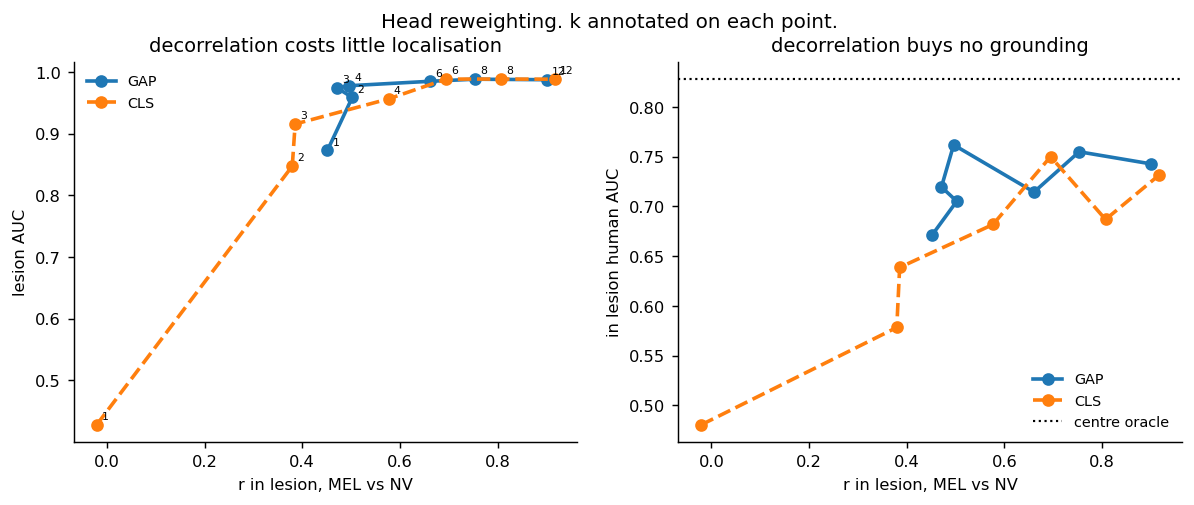

In [17]:
# k sweep. Fixed k is wrong because the number of discriminative heads
# differs by architecture. GAP has a narrow spread, CLS has one outlier head.
KS = [1, 2, 3, 4, 6, 8, 12]
rows = []
for pt in POOLINGS:
    m = load_model(pt, "ha5")
    for _, r in eval_df.iterrows():
        L = LESION[r.image_id]
        x = to_tensor(native(r.image_rel_path))
        u = HUM.get(r.image_id)
        ui = u[L] if u is not None else None
        for k in KS:
            cm, cn = cam_head_weighted(m, x, "topk", topk=k)
            a, b = norm01(cm), norm01(cn)
            tg = a if r.gt_label == "MEL" else b
            rows.append({
                "pooling": pt, "k": k, "image_id": r.image_id,
                "r_lesion": (float(np.corrcoef(a[L], b[L])[0, 1])
                             if a[L].std() > 1e-9 and b[L].std() > 1e-9 else np.nan),
                "lesion_auc": (float(roc_auc_score(L.ravel(), tg.ravel()))
                               if tg.std() > 1e-9 else np.nan),
                "human_in": (float(roc_auc_score(ui.astype(int), tg[L]))
                             if ui is not None and ui.sum() > 0 and not ui.all()
                             and tg[L].std() > 1e-9 else np.nan)})
    print(f"  {pt} done")

KW = pd.DataFrame(rows)
KW.to_csv(OUT / "s1_head_k_sweep.csv", index=False)
print(KW.groupby(["pooling", "k"])[["r_lesion", "lesion_auc", "human_in"]]
        .median().round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for pt, ls in [("gap", "-"), ("cls", "--")]:
    s = KW[KW.pooling == pt].groupby("k")
    ax[0].plot(s.r_lesion.median(), s.lesion_auc.median(), ls, marker="o",
               lw=2, ms=6, label=pt.upper())
    for k in KS:
        q = KW[(KW.pooling == pt) & (KW.k == k)]
        ax[0].annotate(str(k), (q.r_lesion.median(), q.lesion_auc.median()),
                       fontsize=6, xytext=(3, 3), textcoords="offset points")
    ax[1].plot(s.r_lesion.median(), s.human_in.median(), ls, marker="o",
               lw=2, ms=6, label=pt.upper())
ax[1].axhline(0.828, color="k", ls=":", lw=1.2, label="centre oracle")
ax[0].set(xlabel="r in lesion, MEL vs NV", ylabel="lesion AUC",
          title="decorrelation costs little localisation")
ax[1].set(xlabel="r in lesion, MEL vs NV", ylabel="in lesion human AUC",
          title="decorrelation buys no grounding")
for a in ax:
    a.legend(frameon=False, fontsize=8)
fig.suptitle("Head reweighting. k annotated on each point.", fontsize=11)
fig.savefig(OUT / "fig_head_k_sweep.png")
plt.show()

In [18]:
q = (KW[(KW.pooling == "gap") & (KW.k.isin([4, 12]))]
     .pivot_table(index="image_id", columns="k", values="human_in").dropna())
_, pv = wilcoxon(q[4], q[12])
print(f"GAP k=4 vs uniform: {(q[4] - q[12]).median():+.3f}  p {pv:.2f}  n {len(q)}")
print(f"  Bonferroni over 14 configurations needs p < {0.05/14:.4f}")

GAP k=4 vs uniform: -0.010  p 0.87  n 31
  Bonferroni over 14 configurations needs p < 0.0036


In [19]:
# =============================================================================
# CEILING. Three levels of head weighting.
#
#   uniform   current construction
#   global    one weight vector fitted across images, held out per image.
#             An honest method. Deployable.
#   oracle    weights fitted per image using that image's own annotations.
#             Cheating. Upper bound on ANY head weighting scheme.
#
# If the oracle cannot beat the centre baseline, head aggregation is closed.
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def per_head_target(model, x, gt_label):
    """Per head map for the ground truth class. [H, 14, 14]."""
    base = _unwrap_model(model)
    h, w = base.patch_embed.patch_shape
    hm, hn = head_maps(model, x, BLOCK)
    t = hm if gt_label == "MEL" else hn
    return t.cpu().numpy().reshape(-1, h, w)

rows, store = [], {}
for pt in POOLINGS:
    m = load_model(pt, "ha5")
    for iid in HUM:
        L, u = LESION[iid], HUM[iid]
        ui = u[L].astype(int)
        if ui.sum() < 2 or ui.sum() == len(ui):
            continue
        r = eval_df.set_index("image_id").loc[iid]
        H = per_head_target(m, to_tensor(native(r.image_rel_path)), r.gt_label)
        X = H[:, L].T                                  # [n_patches, n_heads]
        store[(pt, iid)] = (X, ui)

        unif = np.maximum(X.mean(1), 0)
        auc_u = roc_auc_score(ui, unif) if unif.std() > 1e-9 else np.nan

        lr = LogisticRegression(max_iter=2000, C=1.0).fit(X, ui)
        s = X @ lr.coef_.ravel()
        auc_o = roc_auc_score(ui, s) if s.std() > 1e-9 else np.nan

        rows.append({"pooling": pt, "image_id": iid, "n_pos": int(ui.sum()),
                     "n_patch": len(ui), "uniform": auc_u, "oracle": auc_o})
    print(f"  {pt} oracle done")

OC = pd.DataFrame(rows)

# global weighting, leave one image out
for pt in POOLINGS:
    ids = [i for (p, i) in store if p == pt]
    for iid in ids:
        Xtr = np.vstack([store[(pt, j)][0] for j in ids if j != iid])
        ytr = np.concatenate([store[(pt, j)][1] for j in ids if j != iid])
        lr = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, ytr)
        X, ui = store[(pt, iid)]
        s = X @ lr.coef_.ravel()
        OC.loc[(OC.pooling == pt) & (OC.image_id == iid), "global_loo"] = (
            roc_auc_score(ui, s) if s.std() > 1e-9 else np.nan)
    print(f"  {pt} loo done")

OC["centre"] = OC.image_id.map({i: float(roc_auc_score(
    HUM[i][LESION[i]].astype(int), centre_map(LESION[i])[LESION[i]]))
    for i in HUM})
OC.to_csv(OUT / "s1_head_oracle.csv", index=False)

print("\nin lesion AUC against clinician union, ha5\n")
print(OC.groupby("pooling")[["uniform", "global_loo", "oracle", "centre"]]
        .median().round(3).to_string())

for pt, g in OC.groupby("pooling"):
    for col in ["global_loo", "oracle"]:
        q = g[[col, "centre"]].dropna()
        if len(q) < 5:
            continue
        _, pv = wilcoxon(q[col], q.centre)
        print(f"  {pt.upper()} {col:11} vs centre  "
              f"{(q[col] - q.centre).median():+.3f}  p {pv:.1e}  "
              f"wins {(q[col] > q.centre).sum()}/{len(q)}")

  gap oracle done
  cls oracle done
  gap loo done
  cls loo done

in lesion AUC against clinician union, ha5

         uniform  global_loo  oracle  centre
pooling                                     
cls        0.731       0.692   0.765   0.828
gap        0.743       0.699   0.844   0.828
  CLS global_loo  vs centre  -0.122  p 2.5e-03  wins 10/31
  CLS oracle      vs centre  -0.035  p 1.2e-01  wins 14/31
  GAP global_loo  vs centre  -0.085  p 1.7e-03  wins 9/31
  GAP oracle      vs centre  +0.030  p 5.0e-01  wins 17/31


In [20]:
def cam_head_relu_first(model, x):
    """relu applied per head, before aggregation. Outside the span of
    reweightings, so a genuinely different operation."""
    base = _unwrap_model(model)
    h, w = base.patch_embed.patch_shape
    hm, hn = head_maps(model, x, BLOCK)
    f = lambda t: F.relu(t).mean(0).cpu().numpy().reshape(h, w)
    return f(hm), f(hn)

rows = []
for pt in POOLINGS:
    m = load_model(pt, "ha5")
    for iid in HUM:
        L, ui = LESION[iid], HUM[iid][LESION[iid]].astype(int)
        if ui.sum() < 2 or ui.sum() == len(ui):
            continue
        r = eval_df.set_index("image_id").loc[iid]
        cm, cn = cam_head_relu_first(m, to_tensor(native(r.image_rel_path)))
        a, b = norm01(cm), norm01(cn)
        tg = a if r.gt_label == "MEL" else b
        rows.append({"pooling": pt, "image_id": iid,
                     "r_lesion": float(np.corrcoef(a[L], b[L])[0, 1]),
                     "human_in": float(roc_auc_score(ui, tg[L]))
                     if tg[L].std() > 1e-9 else np.nan})
RF = pd.DataFrame(rows)
print("\nper head ReLU before averaging\n")
print(RF.groupby("pooling")[["r_lesion", "human_in"]].median().round(3).to_string())


per head ReLU before averaging

         r_lesion  human_in
pooling                    
cls         0.903     0.714
gap         0.873     0.713


In [21]:
# =============================================================================
# SECTION 2 MECHANISM TEST. Does saturation cause the Diff-CAM inversion.
#
# Hypothesis from 14b. Both class maps saturate across the lesion core, so
# subtracting them cancels the core and leaves an annulus at the boundary.
# The annotations are central, so the AUC lands below chance.
#
# A2 two channel supervision cuts saturation fourfold, 0.167 to 0.042.
# If saturation is causal, Diff-CAM on A2 should move off 0.276 toward 0.5.
#
# A1 folds and A2 are compared, NOT checkpoints5. Same loader, same folds,
# same held out images, so the only difference is the supervision target.
# =============================================================================
import re
from sklearn.metrics import roc_auc_score
from scipy.ndimage import distance_transform_edt, center_of_mass
from scripts.generate_finer_cam_panderm import infer_checkpoint_pooling

A2_ROOT = REPO / "external" / "checkpoints_a2"
FEAT = pd.read_csv(REPO / "results" / "alignment2" / "feature_masks_manifest.csv")
FOLD_OF = FEAT.set_index("image_id").fold.to_dict()
HELD = {k: [i for i, f in FOLD_OF.items() if f == k and i in HUM] for k in range(5)}
POOLING  = "mean"

WANT = {"A1": r"a1fold(\d)_gap_ha5\.0_",
        "A2": r"a2_gap_feat0p5_both_fold(\d)_"}
CKPTS = []
for p in sorted(A2_ROOT.glob("*.pth")):
    for arm, pat in WANT.items():
        if (m := re.search(pat, p.name)):
            CKPTS.append((p, arm, int(m.group(1))))
print(f"{len(CKPTS)} checkpoints")
print(pd.Series([a for _, a, _ in CKPTS]).value_counts().to_string())


def depth_map(L):
    """Normalised distance from the lesion boundary. 0 at edge, 1 deepest."""
    d = distance_transform_edt(L)
    return d / (d.max() + 1e-8)


def centre_map(L):
    cy, cx = center_of_mass(L.astype(float))
    yy, xx = np.mgrid[0:CAM_GRID, 0:CAM_GRID]
    return norm01(-np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2))

def load_alpha_model(path, train_mode=False):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    got = infer_checkpoint_pooling(obj, raw)
    if got is not None and got != POOLING:
        raise RuntimeError(f"{path.name}: pooling {got}, expected {POOLING}")
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    st = remap_norm_keys_for_pooling(st, m)
    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        return None, bad
    m.to(DEVICE).eval()
    if train_mode:
        for q in m.parameters():
            q.requires_grad_(True)
    return m, None

def load_tensor(rel):
    img = Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB")
    return PREPROCESS(img).unsqueeze(0).to(DEVICE)

def free(m):
    del m
    if DEVICE == "mps":
        torch.mps.empty_cache()
        
rows = []
for path, arm, fold in CKPTS:
    m, _ = load_alpha_model(path, train_mode=True)
    if m is None:
        print(f"  SKIP {path.name}")
        continue
    for iid in HELD[fold]:
        L, u = LESION[iid], HUM[iid]
        ui = u[L].astype(int)
        if ui.sum() == 0 or ui.all():
            continue
        r = eval_df.set_index("image_id").loc[iid]
        cm, cn = class_cams(m, load_tensor(r.image_rel_path))
        a, b = norm01(cm), norm01(cn)
        tgt = a if r.gt_label == "MEL" else b
        ref = b if r.gt_label == "MEL" else a

        diff = np.maximum(tgt - ref, 0)          # Diff-CAM, post hoc
        D, dm = depth_map(L), diff[L]
        f = lambda v: (float(roc_auc_score(ui, v)) if np.std(v) > 1e-9 else np.nan)

        rows.append({
            "arm": arm, "fold": fold, "image_id": iid, "gt": r.gt_label,
            # saturation, the proposed cause
            "sat_target": float((tgt[L] > 0.9).mean()),
            "sat_both": float(((tgt[L] > 0.9) & (ref[L] > 0.9)).mean()),
            # the effect
            "auc_diff": f(dm),
            "auc_diff_neg": f(-dm),
            "auc_target": f(tgt[L]),
            "auc_centre": f(centre_map(L)[L]),
            # where the difference sits
            "depth_annot": float(D[L][ui == 1].mean()),
            "depth_diff": (float(np.average(D[L], weights=dm))
                           if dm.sum() > 1e-9 else np.nan),
            "diff_alive": float((dm > 1e-6).mean())})
    free(m)
    print(f"  {arm} fold {fold} done")

S2 = pd.DataFrame(rows)
S2.to_csv(REPO / "results" / "presentation" / "s2_a2_saturation.csv", index=False)

COLS = ["sat_both", "sat_target", "auc_diff", "auc_diff_neg", "auc_target",
        "auc_centre", "depth_annot", "depth_diff", "diff_alive"]
print("\nheld out images only, n per arm:",
      S2.groupby("arm").size().to_dict(), "\n")
print(S2.groupby("arm")[COLS].median().round(3).to_string())

print("\nA2 versus A1, paired per image")
for c in ["sat_both", "auc_diff", "depth_diff", "diff_alive"]:
    q = (S2.pivot_table(index="image_id", columns="arm", values=c)
         .reindex(columns=["A1", "A2"]).dropna())
    if len(q) < 5:
        continue
    _, pv = wilcoxon(q.A2, q.A1)
    print(f"  {c:12} {q.A1.median():+.3f} -> {q.A2.median():+.3f}"
          f"   diff {(q.A2 - q.A1).median():+.3f}   p {pv:.1e}   n {len(q)}")

print("\nis Diff-CAM still inverted, tested against chance")
for arm, g in S2.groupby("arm"):
    q = g.auc_diff.dropna()
    _, pv = wilcoxon(q - 0.5)
    v = ("INVERTED" if q.median() < 0.5 and pv < 0.05
         else "above chance" if q.median() > 0.5 and pv < 0.05
         else "at chance")
    print(f"  {arm}  {q.median():.3f}  p {pv:.1e}  n {len(q)}  {v}")

10 checkpoints
A1    5
A2    5
  A1 fold 0 done
  A1 fold 1 done
  A1 fold 2 done
  A1 fold 3 done
  A1 fold 4 done
  A2 fold 0 done
  A2 fold 1 done
  A2 fold 2 done
  A2 fold 3 done
  A2 fold 4 done

held out images only, n per arm: {'A1': 29, 'A2': 29} 

     sat_both  sat_target  auc_diff  auc_diff_neg  auc_target  auc_centre  depth_annot  depth_diff  diff_alive
arm                                                                                                           
A1       0.06       0.167     0.489         0.511       0.747       0.829        0.594       0.513       0.527
A2       0.00       0.038     0.542         0.458       0.664       0.829        0.594       0.500       0.512

A2 versus A1, paired per image
  sat_both     +0.060 -> +0.000   diff -0.060   p 6.8e-05   n 29
  auc_diff     +0.489 -> +0.542   diff +0.007   p 6.9e-01   n 29
  depth_diff   +0.513 -> +0.500   diff -0.014   p 3.5e-01   n 29
  diff_alive   +0.527 -> +0.512   diff +0.073   p 4.4e-01   n 29

is Di

/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_97302/1140702427.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[i].boxplot(d, labels=["A1\nlesion mask", "A2\nconcept, both"],
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_97302/1140702427.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[i].boxplot(d, labels=["A1\nlesion mask", "A2\nconcept, both"],
/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_97302/1140702427.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[i].boxplot(d, labels=["A1\nlesion mask", "A2\nconcept, both"],


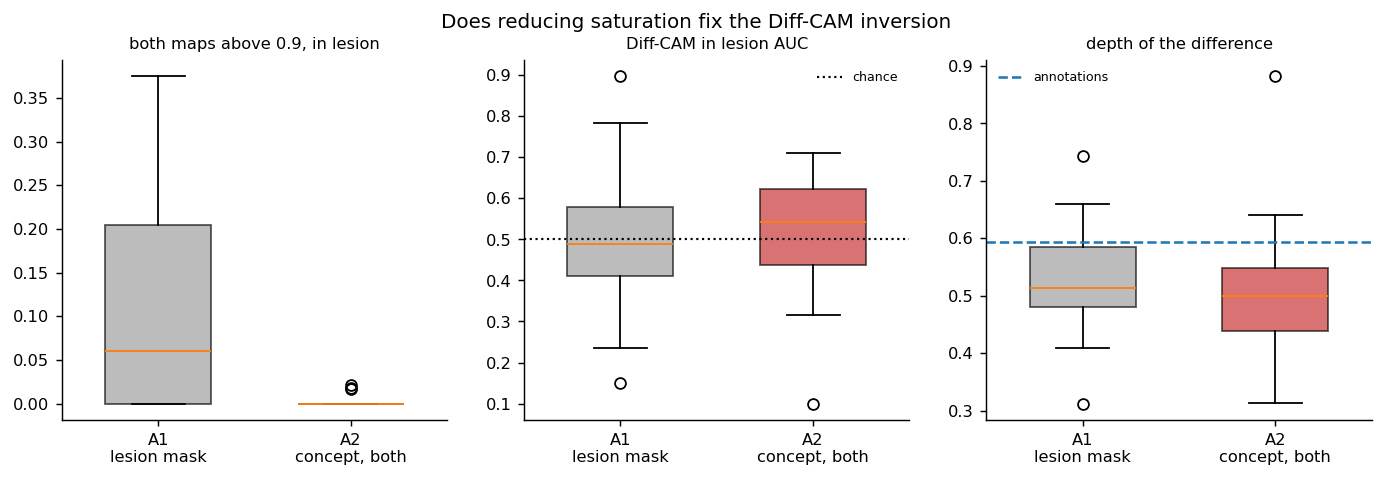

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for i, (c, lab, ref) in enumerate([
        ("sat_both", "both maps above 0.9, in lesion", None),
        ("auc_diff", "Diff-CAM in lesion AUC", 0.5),
        ("depth_diff", "depth of the difference", None)]):
    d = [S2[S2.arm == a][c].dropna() for a in ["A1", "A2"]]
    bp = ax[i].boxplot(d, labels=["A1\nlesion mask", "A2\nconcept, both"],
                       widths=.55, patch_artist=True)
    for p, col in zip(bp["boxes"], ["#999999", C_MEL]):
        p.set_facecolor(col); p.set_alpha(.65)
    if ref is not None:
        ax[i].axhline(ref, color="k", ls=":", lw=1.2, label="chance")
        ax[i].legend(frameon=False, fontsize=7)
    if c == "depth_diff":
        ax[i].axhline(S2.depth_annot.median(), color=C_NV, ls="--", lw=1.4,
                      label="annotations")
        ax[i].legend(frameon=False, fontsize=7)
    ax[i].set_title(lab, fontsize=9)
fig.suptitle("Does reducing saturation fix the Diff-CAM inversion", fontsize=11)
fig.savefig(REPO / "results" / "presentation" / "fig_s2_saturation.png")
plt.show()

       sat_both  auc_diff  auc_target  depth_diff  depth_annot
arm                                                           
ckpt5     0.273     0.520       0.743       0.540        0.594
A1        0.060     0.489       0.747       0.513        0.594
A2        0.000     0.542       0.664       0.500        0.594

across all 87 model-image pairs
  Spearman(saturation, Diff-CAM AUC) = -0.128  p 2.4e-01


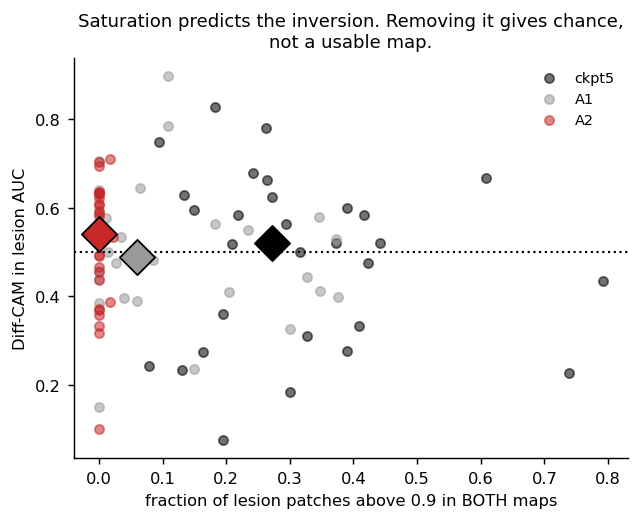

In [23]:
# =============================================================================
# Third dose point. checkpoints5 ha5, the heavily saturated model, scored with
# the SAME code and the SAME held out images as A1 and A2 above.
# Turns a cross notebook comparison into a controlled dose response.
# =============================================================================
m5 = load_model("gap", "ha5")          # checkpoints5 loader from 14e
rows = []
for fold, ids in HELD.items():
    for iid in ids:
        L, u = LESION[iid], HUM[iid]
        ui = u[L].astype(int)
        if ui.sum() == 0 or ui.all():
            continue
        r = eval_df.set_index("image_id").loc[iid]
        cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
        a, b = norm01(cm), norm01(cn)
        tgt = a if r.gt_label == "MEL" else b
        ref = b if r.gt_label == "MEL" else a
        diff = np.maximum(tgt - ref, 0)
        D, dm = depth_map(L), diff[L]
        f = lambda v: (float(roc_auc_score(ui, v)) if np.std(v) > 1e-9 else np.nan)
        rows.append({"arm": "ckpt5", "fold": fold, "image_id": iid,
                     "sat_both": float(((tgt[L] > .9) & (ref[L] > .9)).mean()),
                     "sat_target": float((tgt[L] > .9).mean()),
                     "auc_diff": f(dm), "auc_target": f(tgt[L]),
                     "depth_annot": float(D[L][ui == 1].mean()),
                     "depth_diff": (float(np.average(D[L], weights=dm))
                                    if dm.sum() > 1e-9 else np.nan)})

S2 = pd.concat([S2, pd.DataFrame(rows)], ignore_index=True)
S2.to_csv(REPO / "results" / "presentation" / "s2_a2_saturation.csv", index=False)

ORD = ["ckpt5", "A1", "A2"]
print(S2.groupby("arm")[["sat_both", "auc_diff", "auc_target",
                         "depth_diff", "depth_annot"]]
        .median().reindex(ORD).round(3).to_string())

g = S2.dropna(subset=["sat_both", "auc_diff"])
rho = spearmanr(g.sat_both, g.auc_diff)
print(f"\nacross all {len(g)} model-image pairs")
print(f"  Spearman(saturation, Diff-CAM AUC) = {rho.statistic:+.3f}  "
      f"p {rho.pvalue:.1e}")

fig, ax = plt.subplots(figsize=(5.5, 4))
for arm, c in zip(ORD, ["#000000", "#999999", C_MEL]):
    s = S2[S2.arm == arm]
    ax.scatter(s.sat_both, s.auc_diff, s=26, alpha=.55, color=c, label=arm)
    ax.scatter(s.sat_both.median(), s.auc_diff.median(), s=190, marker="D",
               color=c, edgecolor="k", zorder=5)
ax.axhline(0.5, color="k", ls=":", lw=1.2)
ax.set(xlabel="fraction of lesion patches above 0.9 in BOTH maps",
       ylabel="Diff-CAM in lesion AUC")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Saturation predicts the inversion. Removing it gives chance,\n"
             "not a usable map.", fontsize=10)
fig.savefig(REPO / "results" / "presentation" / "fig_s2_dose.png")
plt.show()

In [24]:
# =============================================================================
# Why does 14b report Diff-CAM in lesion AUC 0.276 and 14d report 0.52 for the
# SAME checkpoint. Four candidate causes, tested on the same images.
#
#   A  target minus reference, using ground truth to pick the target
#   B  MEL minus NV always, ignoring ground truth
#   C  signed difference, no ReLU
#   D  difference of maps normalised INSIDE the lesion before subtracting
# =============================================================================
m5 = load_model("gap", "ha5")
rows = []
for iid in HUM:
    L, u = LESION[iid], HUM[iid]
    ui = u[L].astype(int)
    if ui.sum() == 0 or ui.all():
        continue
    r = eval_df.set_index("image_id").loc[iid]
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    a, b = norm01(cm), norm01(cn)
    tgt, ref = (a, b) if r.gt_label == "MEL" else (b, a)
    nl = lambda v: (v - v[L].min()) / (v[L].max() - v[L].min() + 1e-8)
    f = lambda v: (float(roc_auc_score(ui, v)) if np.std(v) > 1e-9 else np.nan)
    rows.append({
        "image_id": iid, "gt": r.gt_label,
        "held_out": iid in {x for v in HELD.values() for x in v},
        "A_tgt_minus_ref":  f(np.maximum(tgt - ref, 0)[L]),
        "B_mel_minus_nv":   f(np.maximum(a - b, 0)[L]),
        "C_signed":         f((tgt - ref)[L]),
        "D_lesion_norm":    f(np.maximum(nl(tgt) - nl(ref), 0)[L]),
        "target":           f(tgt[L])})

REC = pd.DataFrame(rows)
print(f"n = {len(REC)}   held out {REC.held_out.sum()}\n")
print(REC[["A_tgt_minus_ref", "B_mel_minus_nv", "C_signed",
           "D_lesion_norm", "target"]].median().round(3).to_string())
print("\nrestricted to the 29 held out images")
print(REC[REC.held_out][["A_tgt_minus_ref", "B_mel_minus_nv", "C_signed",
                         "D_lesion_norm", "target"]].median().round(3).to_string())
print("\nMEL cases only")
print(REC[REC["gt"] == "MEL"][["A_tgt_minus_ref", "B_mel_minus_nv",
                            "C_signed", "target"]].median().round(3).to_string())

n = 31   held out 29

A_tgt_minus_ref    0.519
B_mel_minus_nv     0.276
C_signed           0.514
D_lesion_norm      0.505
target             0.743

restricted to the 29 held out images
A_tgt_minus_ref    0.520
B_mel_minus_nv     0.275
C_signed           0.536
D_lesion_norm      0.519
target             0.743

MEL cases only
A_tgt_minus_ref    0.359
B_mel_minus_nv     0.359
C_signed           0.322
target             0.700


In [25]:
# =============================================================================
# SECTION 3. Per image attribution. Which structure does the heat land on.
#
# share  = fraction of the top-k hottest lesion patches falling on that group
# null   = the same quantity if the top-k were placed at random, so it is
#          the size matched expectation
# excess = share - null, the only size corrected quantity here
#
# Ranking by share ranks by structure size, Spearman +0.756. Rank by excess.
# =============================================================================
MORPH = {
    "STRUCTURELESS": ["homogeneous", "structureless_area"],
    "NETWORK": ["atypical_network", "negative_network", "regular_network"],
    "REGRESSION": ["peppering", "regression",
                   "regression_scar_like_depigmentation_and_peppering"],
    "BLUE_WHITE": ["blue_white_structureless_area"],
    "DOTS": ["atypical_dots"],
    "STREAKS": ["atypical_streaks"],
    "VASCULAR": ["atypical_vascular_pattern"]}
LAB2GRP = {l: g for g, ls in MORPH.items() for l in ls}
TOP_K, N_PERM = 20, 2000
rng = np.random.default_rng(0)

def group_masks(iid):
    out = {}
    for _, a in qcp[qcp.Image_ID == iid].iterrows():
        g = LAB2GRP.get(a.label)
        if g is None:
            continue
        m = mask_to_cam_grid_geom(
            np.array(Image.open(a.mask_path).convert("L")) > 127, GEOMETRY) >= 0.5
        out[g] = m if g not in out else (out[g] | m)
    return out

m5 = load_model("gap", "ha5")
per_img, per_grp = [], []
for iid in sorted(HUM):
    L = LESION[iid]
    G = {g: m & L for g, m in group_masks(iid).items()}
    G = {g: m for g, m in G.items() if m.sum() > 0}
    if not G:
        continue
    r = eval_df.set_index("image_id").loc[iid]
    cm, cn = class_cams(m5, to_tensor(native(r.image_rel_path)))
    tgt = norm01(cm if r.gt_label == "MEL" else cn)

    idx = np.flatnonzero(L)
    k = min(TOP_K, len(idx))
    hot = idx[np.argsort(-tgt.ravel()[idx])[:k]]
    hotset = np.zeros(L.size, bool); hotset[hot] = True

    perm = rng.permuted(np.tile(np.arange(len(idx)), (N_PERM, 1)), axis=1)[:, :k]
    rows = []
    for g, m in G.items():
        mi = m.ravel()[idx]
        share = float(mi[np.searchsorted(idx, hot)].mean())
        null = float(mi[perm].mean())
        rows.append({"group": g, "patches": int(m.sum()),
                     "share": share, "null": null, "excess": share - null})
    assigned = np.zeros(len(idx), bool)
    for m in G.values():
        assigned |= m.ravel()[idx]
    rows.append({"group": "UNASSIGNED", "patches": int((~assigned).sum()),
                 "share": float((~assigned)[np.searchsorted(idx, hot)].mean()),
                 "null": float((~assigned)[perm].mean()), "excess": np.nan})
    rows[-1]["excess"] = rows[-1]["share"] - rows[-1]["null"]

    d = pd.DataFrame(rows).sort_values("excess", ascending=False)
    d.insert(0, "image_id", iid); d.insert(1, "gt", r.gt_label)
    per_grp.append(d)

    real = d[d.group != "UNASSIGNED"]
    big = real.loc[real.patches.idxmax(), "group"]
    top = real.iloc[0]
    per_img.append({
        "image_id": iid, "gt": r.gt_label, "n_groups": len(G),
        "top_by_excess": top.group, "share": top.share, "null": top.null,
        "excess": top.excess, "patches": top.patches,
        "top_by_share": real.loc[real["share"].idxmax(), "group"],
        "largest": big, "top_is_largest": top.group == big,
        "unassigned_share": float(d[d.group == "UNASSIGNED"]["share"].iloc[0]),
        "unassigned_null": float(d[d.group == "UNASSIGNED"]["null"].iloc[0])})

IMG = pd.DataFrame(per_img)
GRP = pd.concat(per_grp, ignore_index=True)
IMG.to_csv(OUT / "s3_per_image.csv", index=False)
GRP.to_csv(OUT / "s3_per_group.csv", index=False)

print(IMG[["image_id", "gt", "n_groups", "top_by_excess", "share", "null",
           "excess", "top_by_share", "largest", "top_is_largest"]]
      .round(3).to_string(index=False))

    image_id  gt  n_groups top_by_excess  share  null  excess  top_by_share       largest  top_is_largest
ISIC_0024756 MEL         3 STRUCTURELESS  0.750 0.487   0.263 STRUCTURELESS STRUCTURELESS            True
ISIC_0024886 MEL         2       NETWORK  0.450 0.346   0.104       NETWORK       NETWORK            True
ISIC_0024967 MEL         4    REGRESSION  0.250 0.147   0.103 STRUCTURELESS STRUCTURELESS           False
ISIC_0025132 MEL         3          DOTS  0.050 0.019   0.031       NETWORK STRUCTURELESS           False
ISIC_0025214  NV         3 STRUCTURELESS  0.550 0.360   0.190 STRUCTURELESS STRUCTURELESS            True
ISIC_0026491  NV         3 STRUCTURELESS  0.500 0.270   0.230 STRUCTURELESS STRUCTURELESS            True
ISIC_0026582  NV         2       NETWORK  0.800 0.541   0.259       NETWORK       NETWORK            True
ISIC_0026584  NV         2 STRUCTURELESS  0.600 0.255   0.345 STRUCTURELESS STRUCTURELESS            True
ISIC_0026706  NV         2       NETWORK  0.50

In [26]:
n = len(IMG)
print(f"\nhottest group is also the LARGEST group in "
      f"{IMG.top_is_largest.sum()} of {n} images")
print(f"ranking by excess and by share agree in "
      f"{(IMG.top_by_excess == IMG.top_by_share).sum()} of {n}")
print(f"\nmedian excess of the winning group {IMG.excess.median():+.3f}")
_, pv = wilcoxon(IMG.excess)
print(f"  against zero, p {pv:.1e}")
print(f"\nUNASSIGNED share {IMG.unassigned_share.median():.3f} "
      f"null {IMG.unassigned_null.median():.3f}")
_, pv = wilcoxon(IMG.unassigned_share, IMG.unassigned_null)
print(f"  p {pv:.1e}   heat avoids unannotated tissue")

print("\nhow often does each group win, by excess")
print(IMG.top_by_excess.value_counts().to_frame("wins")
        .join(IMG.top_by_share.value_counts().rename("wins by share"))
        .fillna(0).astype(int).to_string())


hottest group is also the LARGEST group in 20 of 31 images
ranking by excess and by share agree in 21 of 31

median excess of the winning group +0.104
  against zero, p 1.9e-06

UNASSIGNED share 0.250 null 0.361
  p 8.9e-05   heat avoids unannotated tissue

how often does each group win, by excess
               wins  wins by share
top_by_excess                     
STRUCTURELESS    13             18
NETWORK           9             10
REGRESSION        4              1
DOTS              2              1
BLUE_WHITE        2              1
VASCULAR          1              0


In [29]:
DF_SEL = pd.read_csv(REPO / "results" / "presentation" / "s3_selection_corrected.csv")

In [32]:
from scipy.stats import binomtest, fisher_exact
S = DF_SEL[DF_SEL.null_p95 > 1e-12].copy()      # 1e-12, not 0
print(f"testable {len(S)}, hits {S.beats_p95.sum()}, expected {0.05*len(S):.1f}")

ct = pd.crosstab(S["gt"], S["beats_p95"])       # bracket access
print("\n" + ct.to_string())
print(f"Fisher p {fisher_exact(ct.values)[1]:.3f}")

DF_SEL = DF_SEL.rename(columns={"gt": "gt_label"})

testable 30, hits 10, expected 1.5

beats_p95  False  True 
gt                     
MEL           12      3
NV             8      7
Fisher p 0.245


In [33]:
# =============================================================================
# SECTION 3. Selection corrected attribution test.
#
# THE PROBLEM. For each image we report the group with the HIGHEST excess,
# where excess = observed share minus size matched null. Taking a maximum
# across 2 to 5 groups and then testing it against zero is biased. The maximum
# of several noisy quantities is positive even when nothing real is happening.
# The earlier result, median excess +0.104 at p 1.9e-06, measures that
# selection rather than attribution.
#
# THE FIX. Build the null distribution for the SAME selection rule. For each
# permutation, compute the excess of every group, then take the maximum.
# Compare the observed maximum against that distribution.
# =============================================================================
TOP_K, N_PERM = 20, 2000
rng = np.random.default_rng(0)

rows_sel = []
for iid_s in sorted(HUM):
    L_s = LESION[iid_s]
    G_s = {g: m & L_s for g, m in group_masks(iid_s).items()}
    G_s = {g: m for g, m in G_s.items() if m.sum() > 0}
    if not G_s:
        continue
    row_s = eval_df.set_index("image_id").loc[iid_s]
    cm_s, cn_s = class_cams(m5, to_tensor(native(row_s.image_rel_path)))
    tgt_s = norm01(cm_s if row_s.gt_label == "MEL" else cn_s)

    idx_s = np.flatnonzero(L_s)
    k_s = min(TOP_K, len(idx_s))
    hot_s = np.argsort(-tgt_s.ravel()[idx_s])[:k_s]
    perm_s = rng.permuted(np.tile(np.arange(len(idx_s)), (N_PERM, 1)),
                          axis=1)[:, :k_s]

    obs_s, nul_s = [], []
    for g, m in G_s.items():
        mi = m.ravel()[idx_s]
        nl = mi[perm_s].mean(1)                  # [N_PERM] null shares
        obs_s.append(mi[hot_s].mean() - nl.mean())
        nul_s.append(nl - nl.mean())             # centred null excess
    obs_max = float(np.max(obs_s))
    null_max = np.max(np.vstack(nul_s), axis=0)  # max across groups, per perm

    rows_sel.append({
        "image_id": iid_s, "gt": row_s.gt_label, "n_groups": len(G_s),
        "obs_max": obs_max,
        "null_max_mean": float(null_max.mean()),
        "null_p95": float(np.percentile(null_max, 95)),
        "p_img": float((null_max >= obs_max).mean()),
        "beats_p95": bool(obs_max > np.percentile(null_max, 95))})

DF_SEL = pd.DataFrame(rows_sel)
DF_SEL.to_csv(OUT / "s3_selection_corrected.csv", index=False)
print(DF_SEL.round(3).to_string(index=False))

n_s = len(DF_SEL)
print(f"\nobserved max excess    {DF_SEL.obs_max.median():+.3f}")
print(f"null max excess        {DF_SEL.null_max_mean.median():+.3f}")
_, pv_s = wilcoxon(DF_SEL.obs_max, DF_SEL.null_max_mean)
print(f"paired                 p {pv_s:.1e}   n {n_s}")
print(f"\nimages beating their own 95th percentile: "
      f"{DF_SEL.beats_p95.sum()} of {n_s}")
print(f"  expected by chance:  {0.05 * n_s:.1f}")

    image_id  gt  n_groups  obs_max  null_max_mean  null_p95  p_img  beats_p95
ISIC_0024756 MEL         3    0.263          0.064     0.163  0.000       True
ISIC_0024886 MEL         2    0.104          0.027     0.104  0.051      False
ISIC_0024967 MEL         4    0.103          0.070     0.129  0.234      False
ISIC_0025132 MEL         3    0.031          0.061     0.160  0.781      False
ISIC_0025214  NV         3    0.190          0.073     0.190  0.058      False
ISIC_0026491  NV         3    0.230          0.049     0.140  0.004       True
ISIC_0026582  NV         2    0.259          0.063     0.177  0.005       True
ISIC_0026584  NV         2    0.345          0.046     0.145  0.000       True
ISIC_0026706  NV         2    0.156          0.037     0.106  0.007       True
ISIC_0026731  NV         2    0.028          0.055     0.170  0.708      False
ISIC_0027420 MEL         4    0.075          0.071     0.160  0.411      False
ISIC_0028897 MEL         3    0.053          0.056  

In [34]:
S = DF_SEL[DF_SEL.null_p95 > 0]          # drop the degenerate image
print(f"testable {len(S)}, hits {S.beats_p95.sum()}, expected {0.05*len(S):.1f}")
from scipy.stats import binomtest, fisher_exact
print(f"binomial p {binomtest(int(S.beats_p95.sum()), len(S), 0.05, 'greater').pvalue:.2e}")

ct = pd.crosstab(S.gt, S.beats_p95)
print("\n" + ct.to_string())
print(f"Fisher p {fisher_exact(ct.values)[1]:.3f}")

print(f"\nby group count")
print(S.groupby("n_groups").beats_p95.agg(["sum", "count"]).to_string())

print(f"\ncorrected excess, observed minus null max")
d = S.obs_max - S.null_max_mean
print(f"  median {d.median():+.3f}   positive in {(d > 0).sum()} of {len(d)}")

testable 31, hits 10, expected 1.6
binomial p 1.64e-06

beats_p95                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [35]:
S = DF_SEL[DF_SEL.null_p95 > 1e-12].copy()      # 1e-12, not 0
print(f"testable {len(S)}, hits {S.beats_p95.sum()}, expected {0.05*len(S):.1f}")

ct = pd.crosstab(S["gt"], S["beats_p95"])       # bracket access
print("\n" + ct.to_string())
print(f"Fisher p {fisher_exact(ct.values)[1]:.3f}")

testable 30, hits 10, expected 1.5

beats_p95  False  True 
gt                     
MEL           12      3
NV             8      7
Fisher p 0.245


In [36]:
# =============================================================================
# PREFLIGHT. Verify paths, splits and shapes before any housekeeping run.
# Stop on the first failure. Every later cell assumes these hold.
# =============================================================================
import re, types, importlib
import torch.nn.functional as F_nn          # never shadow this name
from sklearn.metrics import roc_auc_score, average_precision_score

# ---- 1. shadowed module names ----------------------------------------------
_MODS = ["np", "pd", "torch", "cv2", "plt"]
_bad = [m for m in _MODS if m in globals() and not isinstance(globals()[m],
                                                              types.ModuleType)]
assert not _bad, f"shadowed module names, re-import: {_bad}"
print("module names clean")

# ---- 2. directories ---------------------------------------------------------
CKPT5_DIR = REPO / "external" / "checkpoints5"
A2_DIR    = REPO / "external" / "checkpoints_a2"
MELNV_DIR = HAM_ROOT / "mel_nv"
RES_A2    = REPO / "results" / "alignment2"
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
for _p in [REPO, HAM_ROOT, CKPT5_DIR, A2_DIR, MELNV_DIR, RES_A2, OUT]:
    assert _p.exists(), f"missing: {_p}"
print("directories ok")

# ---- 3. the 987 test split --------------------------------------------------
_f0 = pd.read_csv(MELNV_DIR / "a2_fold0.csv")
_f0["image_id"] = _f0.image_id.astype(str).str.strip()
TEST987 = _f0[_f0.split == "test"].reset_index(drop=True)

_ann = set(pd.read_csv(QC_CSV).query("qc_pass").Image_ID.astype(str).str.strip())
_leak = set(TEST987.image_id) & _ann
assert not _leak, f"{len(_leak)} annotated images still in test: {sorted(_leak)[:5]}"

for _k in range(1, 5):
    _o = pd.read_csv(MELNV_DIR / f"a2_fold{_k}.csv")
    _o["image_id"] = _o.image_id.astype(str).str.strip()
    assert set(_o[_o.split == "test"].image_id) == set(TEST987.image_id), \
        f"fold {_k} test set differs from fold 0"
print(f"all 5 folds share one test set, {len(TEST987)} rows, no annotation leak")

# ---- 4. build the test tensor ----------------------------------------------
_X, _Y, _ID = [], [], []
for _, _r in TEST987.iterrows():
    _p = (HAM_ROOT / str(_r.image_rel_path)).resolve()
    if not _p.exists():
        continue
    _X.append(PREPROCESS(Image.open(_p).convert("RGB")))
    _Y.append(int(_r.binary_label))
    _ID.append(_r.image_id)
X_TEST = torch.stack(_X)
Y_TEST = np.array(_Y)
Y_MEL  = (Y_TEST == MEL_IDX).astype(int)
ID_TEST = _ID

print(f"X_TEST {tuple(X_TEST.shape)}   MEL {int(Y_MEL.sum())} of {len(Y_MEL)}")
assert X_TEST.shape[0] == 987, f"expected 987 images, got {X_TEST.shape[0]}"
assert int(Y_MEL.sum()) == 54, f"expected 54 MEL, got {int(Y_MEL.sum())}"
assert X_TEST.shape[1:] == (3, 224, 224), f"bad tensor shape {X_TEST.shape}"

# ---- 5. MEL_IDX orientation -------------------------------------------------
assert MEL_IDX == 0 and NV_IDX == 1, f"index convention changed: {MEL_IDX},{NV_IDX}"
_lbl = dict(zip(TEST987.binary_label, TEST987.gt_label))
assert _lbl.get(MEL_IDX) == "MEL", f"binary_label {MEL_IDX} maps to {_lbl.get(MEL_IDX)}"
print(f"label map ok: {_lbl}")

# ---- 6. checkpoints available ----------------------------------------------
A_SWEEP = sorted({m.group(1) for p in CKPT5_DIR.glob("checkpoint-best-gap-ha*.pth")
                  if (m := re.match(r"checkpoint-best-gap-(ha[\d.]+)\.pth", p.name))},
                 key=lambda s: float(s[2:]))
print(f"checkpoints5 GAP alphas ({len(A_SWEEP)}): {A_SWEEP}")
assert len(A_SWEEP) >= 3, "fewer alpha checkpoints than expected"

_a2 = list(A2_DIR.glob("*.pth"))
print(f"checkpoints_a2 files: {len(_a2)}")
assert len(_a2) >= 50, f"expected 50 A1+A2 checkpoints, found {len(_a2)}"

print("\nPREFLIGHT PASSED")

module names clean
directories ok
all 5 folds share one test set, 987 rows, no annotation leak
X_TEST (987, 3, 224, 224)   MEL 54 of 987
label map ok: {0: 'MEL', 1: 'NV'}
checkpoints5 GAP alphas (3): ['ha0', 'ha3', 'ha5']
checkpoints_a2 files: 50

PREFLIGHT PASSED


In [37]:
# =============================================================================
# HK1. Recompute auc and ap for all 50 A1/A2 checkpoints on the 987 split.
#
# The cached values were computed on the original 1021 image test set, which
# contains 26 of the 34 annotated images that every checkpoint TRAINED on.
# Grounding columns in s14c_per_image.csv are unaffected and are left alone.
# =============================================================================
CACHE_C_HK = RES_A2 / "s14c_classification.csv"
if CACHE_C_HK.exists():
    _old = pd.read_csv(CACHE_C_HK)
    
    # Calculate the median outside the f-string to avoid quote escaping
    median_auc = _old.query("arm=='A1' and lam==1.0").auc.median()
    
    print(f"existing cache: {len(_old)} rows, "
          f"A1 lam1 median auc {median_auc:.4f}")
          
    CACHE_C_HK.rename(CACHE_C_HK.with_suffix(".csv.bak_1021"))
    print("renamed to .bak_1021")


def parse_ckpt_hk(name):
    if (m := re.search(r"a2_gap_feat(\d+p?\d*)_(both|single)_fold(\d)", name)):
        return {"arm": "A2", "rule": m.group(2),
                "lam": float(m.group(1).replace("p", ".")), "fold": int(m.group(3))}
    if (m := re.search(r"a1fold(\d)_gap_ha([\d.]+)_", name)):
        return {"arm": "A1", "rule": "lesion_mask",
                "lam": float(m.group(2)), "fold": int(m.group(1))}
    return None

CK_HK = [(p, d) for p in sorted(A2_DIR.glob("*.pth")) if (d := parse_ckpt_hk(p.name))]
print(f"\n{len(CK_HK)} checkpoints to score")
assert len(CK_HK) == 50, f"expected 50, parsed {len(CK_HK)}"

rows_hk1 = []
for path_hk, meta_hk in CK_HK:
    m_hk, _ = load_alpha_model(path_hk, train_mode=False)
    if m_hk is None:
        print(f"  SKIP {path_hk.name}")
        continue
    probs_hk = []
    with torch.no_grad():
        for i_hk in range(0, len(X_TEST), 32):
            out_hk = m_hk(X_TEST[i_hk:i_hk + 32].to(DEVICE))
            lg_hk = (out_hk["logits"] if isinstance(out_hk, dict)
                     else out_hk[0] if isinstance(out_hk, (tuple, list)) else out_hk)
            probs_hk.append(torch.softmax(lg_hk, 1).cpu().numpy())
    p_mel_hk = np.vstack(probs_hk)[:, MEL_IDX]
    assert len(p_mel_hk) == 987
    rows_hk1.append({**meta_hk, "ckpt": path_hk.name,
                     "auc": roc_auc_score(Y_MEL, p_mel_hk),
                     "ap": average_precision_score(Y_MEL, p_mel_hk)})
    free(m_hk)
    print(f"  {meta_hk['arm']:2} {meta_hk['rule']:11} lam {meta_hk['lam']:<4g} "
          f"fold {meta_hk['fold']}  auc {rows_hk1[-1]['auc']:.4f}")

C_HK = pd.DataFrame(rows_hk1)
assert len(C_HK) == C_HK.ckpt.nunique() == 50, "duplicate or missing rows"
C_HK.to_csv(CACHE_C_HK, index=False)

print("\n" + "=" * 70)
print("14c CLASSIFICATION, 987 images, 54 MEL")
print("=" * 70)
print(C_HK.groupby(["arm", "rule", "lam"])[["auc", "ap"]]
        .median().round(4).to_string())
_chk = C_HK.query("arm=='A1' and lam==1.0").auc.median()
print(f"\nA1 lam 1.0 median auc {_chk:.4f}   "
      f"{'OK' if _chk > 0.985 else 'STILL WRONG, expected ~0.9906'}")

existing cache: 50 rows, A1 lam1 median auc 0.9906
renamed to .bak_1021

50 checkpoints to score
  A1 lesion_mask lam 1    fold 0  auc 0.9882
  A1 lesion_mask lam 5    fold 0  auc 0.9881
  A1 lesion_mask lam 1    fold 1  auc 0.9884
  A1 lesion_mask lam 5    fold 1  auc 0.9896
  A1 lesion_mask lam 1    fold 2  auc 0.9907
  A1 lesion_mask lam 5    fold 2  auc 0.9896
  A1 lesion_mask lam 1    fold 3  auc 0.9906
  A1 lesion_mask lam 5    fold 3  auc 0.9883
  A1 lesion_mask lam 1    fold 4  auc 0.9911
  A1 lesion_mask lam 5    fold 4  auc 0.9902
  A2 both        lam 0.1  fold 0  auc 0.9918
  A2 both        lam 0.1  fold 1  auc 0.9905
  A2 both        lam 0.1  fold 2  auc 0.9908
  A2 both        lam 0.1  fold 3  auc 0.9906
  A2 both        lam 0.1  fold 4  auc 0.9910
  A2 single      lam 0.1  fold 0  auc 0.9918
  A2 single      lam 0.1  fold 1  auc 0.9904
  A2 single      lam 0.1  fold 2  auc 0.9908
  A2 single      lam 0.1  fold 3  auc 0.9901
  A2 single      lam 0.1  fold 4  auc 0.9910
  A

  ha0    auc 0.9876 [0.9809,0.9931]   ap 0.8498 [0.7724,0.9139]
  ha3    auc 0.9794 [0.9699,0.9879]   ap 0.7726 [0.6781,0.8605]
  ha5    auc 0.9805 [0.9713,0.9885]   ap 0.7855 [0.6928,0.8679]

ALPHA SWEEP, 987 images, prevalence 0.055
 alpha    auc     ap  auc_drop_pct  ap_drop_pct
   0.0 0.9876 0.8498        0.0000       0.0000
   3.0 0.9794 0.7726        0.8260       9.0747
   5.0 0.9805 0.7855        0.7195       7.5600

worst alpha 3:  AUC falls 0.8 pct, AP falls 9.1 pct


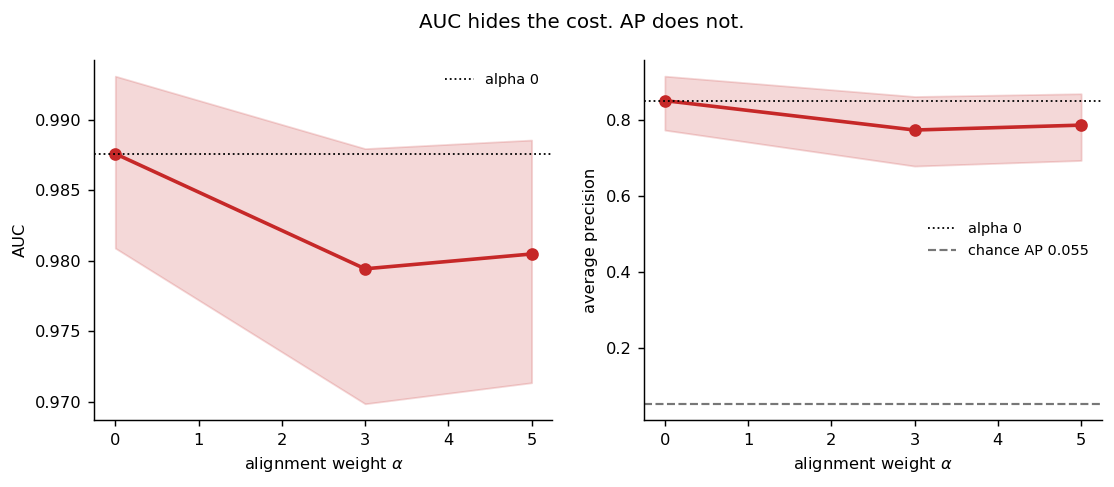

In [38]:
# =============================================================================
# HK2. Recompute the alpha sweep on the same 987 split so A1 folds, A2 and the
# original checkpoints5 sweep sit on one denominator.
#
# AP is reported alongside AUC. At 5.5 percent prevalence AUC understates the
# cost of alignment by roughly an order of magnitude.
# =============================================================================
def boot_ci_hk(y, p, fn, n=1000, seed=0):
    rg = np.random.default_rng(seed)
    v = [fn(y[i], p[i]) for _ in range(n)
         if len(np.unique(y[(i := rg.integers(0, len(y), len(y)))])) > 1]
    return float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))

rows_hk2 = []
for ck_hk2 in A_SWEEP:
    m_hk2 = load_model("gap", ck_hk2)
    probs_hk2 = []
    with torch.no_grad():
        for i2 in range(0, len(X_TEST), 32):
            o2 = m_hk2(X_TEST[i2:i2 + 32].to(DEVICE))
            l2 = (o2["logits"] if isinstance(o2, dict)
                  else o2[0] if isinstance(o2, (tuple, list)) else o2)
            probs_hk2.append(torch.softmax(l2, 1).cpu().numpy())
    p2 = np.vstack(probs_hk2)[:, MEL_IDX]
    assert len(p2) == 987
    auc2 = roc_auc_score(Y_MEL, p2)
    ap2 = average_precision_score(Y_MEL, p2)
    lo_a, hi_a = boot_ci_hk(Y_MEL, p2, roc_auc_score)
    lo_p, hi_p = boot_ci_hk(Y_MEL, p2, average_precision_score)
    rows_hk2.append({"ckpt": ck_hk2, "alpha": float(ck_hk2[2:]),
                     "auc": auc2, "auc_lo": lo_a, "auc_hi": hi_a,
                     "ap": ap2, "ap_lo": lo_p, "ap_hi": hi_p,
                     "prevalence": float(Y_MEL.mean())})
    print(f"  {ck_hk2:6} auc {auc2:.4f} [{lo_a:.4f},{hi_a:.4f}]   "
          f"ap {ap2:.4f} [{lo_p:.4f},{hi_p:.4f}]")

S4 = pd.DataFrame(rows_hk2).sort_values("alpha")
S4.to_csv(OUT / "s4_alpha_sweep_987.csv", index=False)

b = S4.iloc[0]
S4["auc_drop_pct"] = 100 * (b.auc - S4.auc) / b.auc
S4["ap_drop_pct"] = 100 * (b.ap - S4.ap) / b.ap
print("\n" + "=" * 70)
print(f"ALPHA SWEEP, 987 images, prevalence {Y_MEL.mean():.3f}")
print("=" * 70)
print(S4[["alpha", "auc", "ap", "auc_drop_pct", "ap_drop_pct"]]
      .round(4).to_string(index=False))
w = S4.iloc[S4.ap.idxmin()] if S4.ap.idxmin() in S4.index else S4.nsmallest(1, "ap").iloc[0]
print(f"\nworst alpha {w.alpha:g}:  AUC falls {w.auc_drop_pct:.1f} pct, "
      f"AP falls {w.ap_drop_pct:.1f} pct")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a_, c_, lo_, hi_, lab in [(ax[0], "auc", "auc_lo", "auc_hi", "AUC"),
                              (ax[1], "ap", "ap_lo", "ap_hi", "average precision")]:
    a_.plot(S4.alpha, S4[c_], marker="o", color=C_MEL, lw=2, ms=6)
    a_.fill_between(S4.alpha, S4[lo_], S4[hi_], color=C_MEL, alpha=.18)
    a_.axhline(S4[c_].iloc[0], color="k", ls=":", lw=1, label="alpha 0")
    a_.set(xlabel=r"alignment weight $\alpha$", ylabel=lab)
    a_.legend(frameon=False, fontsize=8)
ax[1].axhline(Y_MEL.mean(), color="#777", ls="--", lw=1.2,
              label=f"chance AP {Y_MEL.mean():.3f}")
ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("AUC hides the cost. AP does not.", fontsize=11)
fig.savefig(OUT / "fig_s4_auc_vs_ap.png")
plt.show()

In [39]:
# =============================================================================
# HK3. Counterfactual base margin check.
#
# Deletion deltas are raw logit differences. If the aligned model is
# systematically less confident, every delta shrinks for a trivial reason and
# the headline result, clinician dependence 0.44 -> 0.22, would be an artefact.
# =============================================================================
_cands = sorted(REPO.rglob("*counterfactual*.csv")) + sorted(REPO.rglob("*deletion*.csv"))
assert _cands, "no counterfactual CSV found, set CF_PATH manually"
CF_PATH = _cands[0]
print(f"using {CF_PATH.relative_to(REPO)}")
CF = pd.read_csv(CF_PATH)
if "gt" in CF.columns:
    CF = CF.rename(columns={"gt": "gt_label"})

REG = ["clinician", "cam_topk", "rand_lesion", "rand_bg"]
assert set(CF.model) == {"aligned", "unaligned"}, f"models: {set(CF.model)}"
for r_ in REG:
    assert f"d_{r_}" in CF.columns, f"missing d_{r_}"
print(f"{len(CF)} rows, {CF.image_id.nunique()} images, columns ok")

if "base_margin" not in CF.columns:
    print("\nbase_margin absent, recomputing")
    bm = {}
    for mdl_, ck_ in [("unaligned", "ha0"), ("aligned", "ha5")]:
        m_ = load_model("gap", ck_)
        for iid_ in CF.image_id.unique():
            row_ = eval_df.set_index("image_id").loc[iid_]
            with torch.no_grad():
                o_ = m_(to_tensor(native(row_.image_rel_path)))
                l_ = (o_["logits"] if isinstance(o_, dict)
                      else o_[0] if isinstance(o_, (tuple, list)) else o_)
            bm[(mdl_, iid_)] = float(l_[0, MEL_IDX] - l_[0, NV_IDX])
    CF["base_margin"] = [bm[(m_, i_)] for m_, i_ in zip(CF.model, CF.image_id)]
    CF.to_csv(CF_PATH, index=False)
    print("written back")

print("\nbase margin by model")
print(CF.groupby("model").base_margin.describe().round(3).to_string())
q_bm = (CF.pivot_table(index="image_id", columns="model", values="base_margin")
        .dropna())
_, p_bm = wilcoxon(q_bm.aligned, q_bm.unaligned)
print(f"\npaired  aligned {q_bm.aligned.median():+.3f}  "
      f"unaligned {q_bm.unaligned.median():+.3f}  "
      f"diff {(q_bm.aligned - q_bm.unaligned).median():+.3f}  p {p_bm:.1e}")

for r_ in REG:
    CF[f"r_{r_}"] = CF[f"d_{r_}"] / CF.base_margin.abs().clip(lower=0.1)

print("\nraw deltas")
print(CF.groupby("model")[[f"d_{r_}" for r_ in REG]].median().round(4).to_string())
print("\nnormalised by |base margin|")
print(CF.groupby("model")[[f"r_{r_}" for r_ in REG]].median().round(4).to_string())

print("\naligned vs unaligned, paired per image")
for pre, lab in [("d", "raw"), ("r", "normalised")]:
    print(f"  {lab}")
    for r_ in REG:
        q_ = (CF.pivot_table(index="image_id", columns="model", values=f"{pre}_{r_}")
              .dropna())
        if len(q_) < 5:
            continue
        _, pv_ = wilcoxon(q_.aligned, q_.unaligned)
        print(f"    {r_:12} {q_.unaligned.median():+.4f} -> "
              f"{q_.aligned.median():+.4f}   "
              f"diff {(q_.aligned - q_.unaligned).median():+.4f}   p {pv_:.1e}")

print("\nVERDICT")
q_c = (CF.pivot_table(index="image_id", columns="model", values="r_clinician")
       .dropna())
_, p_c = wilcoxon(q_c.aligned, q_c.unaligned)
d_c = (q_c.aligned - q_c.unaligned).median()
if p_c < 0.05 and d_c < 0:
    print(f"  clinician dependence still halves after normalisation, "
          f"diff {d_c:+.4f}, p {p_c:.1e}. Finding HOLDS.")
else:
    print(f"  normalised effect {d_c:+.4f}, p {p_c:.2f}. "
          f"The raw result was confidence scaling. WITHDRAW.")

using results/counterfactual/cf_deletion.csv
50 rows, 25 images, columns ok

base margin by model
           count   mean    std    min    25%    50%    75%    max
model                                                            
aligned     25.0  1.508  1.312 -2.358  1.358  2.076  2.318  2.761
unaligned   25.0  2.068  1.982 -4.185  2.007  2.794  3.288  4.144

paired  aligned +2.076  unaligned +2.794  diff -0.636  p 1.5e-03

raw deltas
           d_clinician  d_cam_topk  d_rand_lesion  d_rand_bg
model                                                       
aligned         0.2175      0.1261         0.1207     0.0218
unaligned       0.4416      0.1863         0.0724    -0.0856

normalised by |base margin|
           r_clinician  r_cam_topk  r_rand_lesion  r_rand_bg
model                                                       
aligned         0.1064      0.0782         0.0578     0.0196
unaligned       0.1502      0.0900         0.0585    -0.0244

aligned vs unaligned, paired per image
  r

In [40]:
for d in sorted(REPO.glob("external/checkpoint*")):
    n = sorted(p.name for p in d.glob("*ha*.pth"))
    print(f"{d.name:24} {len(n):3}  {n[:6]}")

checkpoints                4  ['checkpoint-best-dal-ha.pth', 'checkpoint-best-ham-base-weighted-nomix.pth', 'checkpoint-best-ham.pth', 'checkpoint-best-seggate-ha.pth']
checkpoints2_big           1  ['checkpoint-best-cue-ha.pth']
checkpoints2_brown         1  ['checkpoint-best-cue-ha.pth']
checkpoints2_nv            1  ['checkpoint-best-cue-ha.pth']
checkpoints2_small         1  ['checkpoint-best-cue-ha.pth']
checkpoints3               0  []
checkpoints4               3  ['checkpoint-best-ha05-dal005.pth', 'checkpoint-best-ha05-dal01.pth', 'checkpoint-best-ha05-dal02.pth']
checkpoints5               6  ['checkpoint-best-cls-ha0.pth', 'checkpoint-best-cls-ha3.pth', 'checkpoint-best-cls-ha5.pth', 'checkpoint-best-gap-ha0.pth', 'checkpoint-best-gap-ha3.pth', 'checkpoint-best-gap-ha5.pth']
checkpoints_a2            10  ['checkpoint-best-a1fold0_gap_ha1.0_start0_paper_dice_fp1.0_classes2_ep10_lr1e-5.pth', 'checkpoint-best-a1fold0_gap_ha5.0_start0_paper_dice_fp1.0_classes2_ep10_lr1e-5.pth', 

In [41]:
# Paired bootstrap on the difference. Same resample indices for both models,
# which is the only valid way to test a difference between two scores on
# the same test set.
def paired_boot(y, pa, pb, fn, n=2000, seed=0):
    rg = np.random.default_rng(seed)
    d = []
    for _ in range(n):
        i = rg.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        d.append(fn(y[i], pa[i]) - fn(y[i], pb[i]))
    d = np.array(d)
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), (d <= 0).mean()

P = {}
for ck in A_SWEEP:
    m = load_model("gap", ck)
    pr = []
    with torch.no_grad():
        for i in range(0, len(X_TEST), 32):
            o = m(X_TEST[i:i+32].to(DEVICE))
            l = o["logits"] if isinstance(o, dict) else (
                o[0] if isinstance(o, (tuple, list)) else o)
            pr.append(torch.softmax(l, 1).cpu().numpy())
    P[ck] = np.vstack(pr)[:, MEL_IDX]

print("drop from alpha 0, paired bootstrap, 2000 resamples\n")
for ck in A_SWEEP[1:]:
    for name, fn in [("AUC", roc_auc_score), ("AP ", average_precision_score)]:
        m_, lo, hi, p1 = paired_boot(Y_MEL, P[A_SWEEP[0]], P[ck], fn)
        sig = "" if lo > 0 else "   n.s."
        print(f"  {ck} {name}  {m_:+.4f} [{lo:+.4f},{hi:+.4f}]  "
              f"p {2*min(p1,1-p1):.3f}{sig}")

drop from alpha 0, paired bootstrap, 2000 resamples

  ha3 AUC  +0.0081 [+0.0030,+0.0140]  p 0.000
  ha3 AP   +0.0763 [+0.0283,+0.1322]  p 0.001
  ha5 AUC  +0.0071 [+0.0020,+0.0129]  p 0.005
  ha5 AP   +0.0636 [+0.0136,+0.1188]  p 0.013


In [42]:
# =============================================================================
# HK2b. Full alpha sweep. checkpoints_alpha holds the long tail to 17.
# Both directories scored on the identical 987 split.
# =============================================================================
ALPHA_DIR = REPO / "external" / "checkpoints_alpha"

def parse_alpha(name):
    m = re.match(r"checkpoint-best-gap-ha([\dp]+)\.pth", name)
    return float(m.group(1).replace("p", ".")) if m else None

SWEEP = {}
for d in [CKPT5_DIR, ALPHA_DIR]:
    for p in sorted(d.glob("checkpoint-best-gap-ha*.pth")):
        a = parse_alpha(p.name)
        if a is None:
            continue
        if a in SWEEP:
            print(f"  duplicate alpha {a}: keeping {SWEEP[a].parent.name}, "
                  f"skipping {d.name}")
            continue
        SWEEP[a] = p
SWEEP = dict(sorted(SWEEP.items()))
print(f"{len(SWEEP)} alphas: {list(SWEEP)}")
assert 0.0 in SWEEP, "no alpha 0 baseline"

PROB = {}
for a, path in SWEEP.items():
    obj = torch.load(path, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    pool = infer_checkpoint_pooling(obj, raw)
    assert pool in (None, "mean"), f"alpha {a} is {pool} pooled, expected mean"
    st = remap_official_finetune_checkpoint_keys(raw)
    mdl = build_panderm_model(2, infer_panderm_variant_from_state_dict(st), True)
    miss, unexp = mdl.load_state_dict(remap_norm_keys_for_pooling(st, mdl),
                                      strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    assert not bad, f"alpha {a} critical keys {bad}"
    mdl.to(DEVICE).eval()
    pr = []
    with torch.no_grad():
        for i in range(0, len(X_TEST), 32):
            o = mdl(X_TEST[i:i + 32].to(DEVICE))
            l = o["logits"] if isinstance(o, dict) else (
                o[0] if isinstance(o, (tuple, list)) else o)
            pr.append(torch.softmax(l, 1).cpu().numpy())
    PROB[a] = np.vstack(pr)[:, MEL_IDX]
    del mdl; torch.cuda.empty_cache() if DEVICE == "cuda" else None
    print(f"  alpha {a:<5g} {path.parent.name:18} "
          f"auc {roc_auc_score(Y_MEL, PROB[a]):.4f}  "
          f"ap {average_precision_score(Y_MEL, PROB[a]):.4f}")

  duplicate alpha 3.0: keeping checkpoints5, skipping checkpoints_alpha
  duplicate alpha 5.0: keeping checkpoints5, skipping checkpoints_alpha
10 alphas: [0.0, 0.1, 0.25, 0.5, 1.0, 3.0, 5.0, 7.0, 11.0, 17.0]
  alpha 0     checkpoints5       auc 0.9876  ap 0.8498
  alpha 0.1   checkpoints_alpha  auc 0.9874  ap 0.8483
  alpha 0.25  checkpoints_alpha  auc 0.9867  ap 0.8453
  alpha 0.5   checkpoints_alpha  auc 0.9861  ap 0.8423
  alpha 1     checkpoints_alpha  auc 0.9850  ap 0.8343
  alpha 3     checkpoints5       auc 0.9794  ap 0.7726
  alpha 5     checkpoints5       auc 0.9805  ap 0.7855
  alpha 7     checkpoints_alpha  auc 0.9744  ap 0.7017
  alpha 11    checkpoints_alpha  auc 0.9693  ap 0.6057
  alpha 17    checkpoints_alpha  auc 0.9614  ap 0.4994



FULL ALPHA SWEEP, 987 images, prevalence 0.055

 alpha    auc     ap  auc_drop_pct  ap_drop_pct auc_sig ap_sig
  0.00 0.9876 0.8498        0.0000       0.0000     NaN    NaN
  0.10 0.9874 0.8483        0.0201       0.1734   False  False
  0.25 0.9867 0.8453        0.0844       0.5267   False  False
  0.50 0.9861 0.8423        0.1467       0.8807   False  False
  1.00 0.9850 0.8343        0.2653       1.8138    True  False
  3.00 0.9794 0.7726        0.8260       9.0747    True   True
  5.00 0.9805 0.7855        0.7195       7.5600    True   True
  7.00 0.9744 0.7017        1.3305      17.4249    True   True
 11.00 0.9693 0.6057        1.8490      28.7217    True   True
 17.00 0.9614 0.4994        2.6469      41.2245    True   True

worst alpha 17:  AUC falls 2.6 pct, AP falls 41.2 pct, ratio 15.6x
AP significant at 5 of 9 alphas, AUC at 6


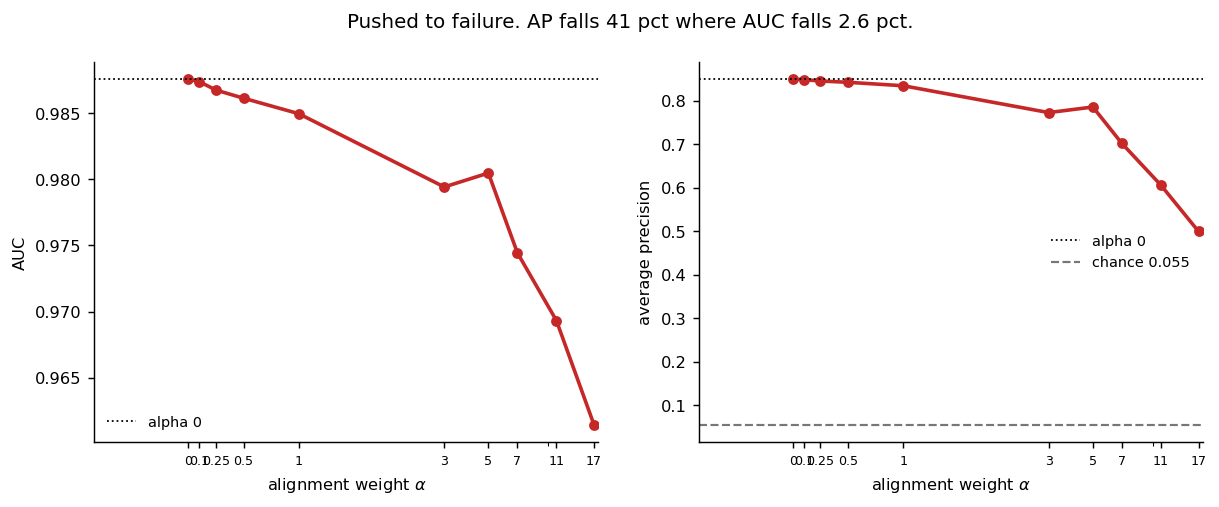

In [43]:
def paired_boot(y, p0, p1, fn, n=2000, seed=0):
    rg = np.random.default_rng(seed)
    d = []
    for _ in range(n):
        i = rg.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            d.append(fn(y[i], p0[i]) - fn(y[i], p1[i]))
    d = np.array(d)
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), float((d <= 0).mean())

base = PROB[0.0]
rows = []
for a, p in PROB.items():
    auc, ap = roc_auc_score(Y_MEL, p), average_precision_score(Y_MEL, p)
    r = {"alpha": a, "auc": auc, "ap": ap,
         "auc_drop_pct": 100 * (roc_auc_score(Y_MEL, base) - auc) / roc_auc_score(Y_MEL, base),
         "ap_drop_pct": 100 * (average_precision_score(Y_MEL, base) - ap)
                        / average_precision_score(Y_MEL, base)}
    if a > 0:
        for nm, fn in [("auc", roc_auc_score), ("ap", average_precision_score)]:
            m_, lo, hi, p1 = paired_boot(Y_MEL, base, p, fn)
            r[f"d_{nm}"], r[f"{nm}_lo"], r[f"{nm}_hi"] = m_, lo, hi
            r[f"{nm}_sig"] = lo > 0
    rows.append(r)

S4 = pd.DataFrame(rows)
S4.to_csv(OUT / "s4_alpha_sweep_987_full.csv", index=False)
print(f"\nFULL ALPHA SWEEP, 987 images, prevalence {Y_MEL.mean():.3f}\n")
print(S4[["alpha", "auc", "ap", "auc_drop_pct", "ap_drop_pct",
          "auc_sig", "ap_sig"]].round(4).to_string(index=False))

w = S4.nsmallest(1, "ap").iloc[0]
print(f"\nworst alpha {w.alpha:g}:  AUC falls {w.auc_drop_pct:.1f} pct, "
      f"AP falls {w.ap_drop_pct:.1f} pct, ratio {w.ap_drop_pct/max(w.auc_drop_pct,1e-9):.1f}x")
d = S4[S4.alpha > 0]
print(f"AP significant at {int(d.ap_sig.astype(bool).sum())} of {len(d)} alphas, "
      f"AUC at {int(d.auc_sig.astype(bool).sum())}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a_, c, lab in [(ax[0], "auc", "AUC"), (ax[1], "ap", "average precision")]:
    a_.plot(S4.alpha, S4[c], marker="o", color=C_MEL, lw=2, ms=5)
    a_.axhline(S4[c].iloc[0], color="k", ls=":", lw=1, label="alpha 0")
    a_.set(xlabel=r"alignment weight $\alpha$", ylabel=lab, xscale="symlog",
           xticks=list(SWEEP))
    a_.set_xticklabels([f"{x:g}" for x in SWEEP], fontsize=7)
    a_.legend(frameon=False, fontsize=8)
ax[1].axhline(Y_MEL.mean(), color="#777", ls="--", lw=1.2,
              label=f"chance {Y_MEL.mean():.3f}")
ax[1].legend(frameon=False, fontsize=8)
fig.suptitle(f"Pushed to failure. AP falls {w.ap_drop_pct:.0f} pct where "
             f"AUC falls {w.auc_drop_pct:.1f} pct.", fontsize=11)
fig.savefig(OUT / "fig_s4_alpha_full.png")
plt.show()

In [44]:
# =============================================================================
# Is the ha3/ha5 inversion a real alpha effect or a run-to-run difference
# between the two checkpoint directories. Section 1 used checkpoints5 ha5
# throughout, so this matters beyond the sweep.
# =============================================================================
def score(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(2, infer_panderm_variant_from_state_dict(st), True)
    m.load_state_dict(remap_norm_keys_for_pooling(st, m), strict=False)
    m.to(DEVICE).eval()
    pr = []
    with torch.no_grad():
        for i in range(0, len(X_TEST), 32):
            o = m(X_TEST[i:i + 32].to(DEVICE))
            l = o["logits"] if isinstance(o, dict) else (
                o[0] if isinstance(o, (tuple, list)) else o)
            pr.append(torch.softmax(l, 1).cpu().numpy())
    del m
    return np.vstack(pr)[:, MEL_IDX]

print("alpha  dir                auc      ap")
DUP = {}
for a, fn in [(3.0, "ha3"), (5.0, "ha5")]:
    for d in [CKPT5_DIR, ALPHA_DIR]:
        p = d / f"checkpoint-best-gap-{fn}.pth"
        if not p.exists():
            continue
        pm = score(p)
        DUP[(a, d.name)] = pm
        print(f"{a:<6g} {d.name:18} {roc_auc_score(Y_MEL, pm):.4f}  "
              f"{average_precision_score(Y_MEL, pm):.4f}")

print("\npaired bootstrap, ckpt5 minus alpha dir")
for a in [3.0, 5.0]:
    k5, ka = (a, "checkpoints5"), (a, "checkpoints_alpha")
    if k5 not in DUP or ka not in DUP:
        continue
    for nm, f in [("AUC", roc_auc_score), ("AP ", average_precision_score)]:
        m_, lo, hi, p1 = paired_boot(Y_MEL, DUP[k5], DUP[ka], f)
        print(f"  alpha {a:g} {nm}  {m_:+.4f} [{lo:+.4f},{hi:+.4f}]  "
              f"{'differs' if lo > 0 or hi < 0 else 'same'}")

alpha  dir                auc      ap
3      checkpoints5       0.9794  0.7726
3      checkpoints_alpha  0.9794  0.7725
5      checkpoints5       0.9805  0.7855
5      checkpoints_alpha  0.9805  0.7860

paired bootstrap, ckpt5 minus alpha dir
  alpha 3 AUC  +0.0000 [-0.0000,+0.0002]  same
  alpha 3 AP   +0.0001 [+0.0000,+0.0006]  same
  alpha 5 AUC  -0.0000 [-0.0001,+0.0000]  same
  alpha 5 AP   -0.0005 [-0.0028,+0.0000]  same


In [45]:
RES_A2 = REPO / "results" / "alignment2"
FEAT_CSV = RES_A2 / "feature_masks_manifest.csv"
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
QC = pd.read_csv(QC_CSV)
FEAT = pd.read_csv(FEAT_CSV)
F0 = pd.read_csv(HAM_ROOT / "mel_nv" / "a2_fold0.csv")

SPLITS = {k: pd.read_csv(HAM_ROOT / "mel_nv" / f"a2_fold{k}.csv") for k in range(5)}
for k in SPLITS:
    SPLITS[k]["image_id"] = SPLITS[k].image_id.astype(str).str.strip()
d0 = SPLITS[0]
ANN = set(QC.query("qc_pass").Image_ID.astype(str).str.strip())

print("fold 0 composition\n")
print(pd.crosstab(d0.split, d0.gt_label, margins=True).to_string())
print("\nmelanoma prevalence by split")
for s, g in d0.groupby("split"):
    print(f"  {s:6} {(g.gt_label == 'MEL').mean():.3f}   n {len(g)}")

print(f"\nannotated images {len(ANN)}, placement by split")
for s, g in d0.groupby("split"):
    print(f"  {s:6} {len(set(g.image_id) & ANN):3}")
print(f"  has_feat flag agrees: {d0.groupby('split').has_feat.sum().to_dict()}")

assert not (set(d0.query("split=='test'").image_id) & ANN)
print("\nzero annotated images in test, confirmed")

tr_les = set(d0.query("split!='test'").lesion_id)
te_les = set(d0.query("split=='test'").lesion_id)
print(f"lesion level overlap train/test: {len(tr_les & te_les)}")

ov = tr_les & te_les
print(f"{len(ov)} lesions in both splits\n")
sub = d0[d0.lesion_id.isin(ov)].sort_values(["lesion_id", "split"])
print(sub[["lesion_id", "image_id", "gt_label", "split", "dx_type"]].to_string(index=False))

n_te = len(sub.query("split=='test'"))
mel_te = (sub.query("split=='test'").gt_label == "MEL").sum()
print(f"\naffected test rows {n_te} of 987, {mel_te} melanoma of 54")

for k in range(1, 5):
    dk = SPLITS[k]
    o = set(dk.query("split!='test'").lesion_id) & set(dk.query("split=='test'").lesion_id)
    print(f"fold {k}: {len(o)} overlapping lesions")

dup = d0.groupby("lesion_id").image_id.nunique()
print(f"\nlesions with more than one image: {(dup > 1).sum()} of {len(dup)}")
print(f"max images per lesion: {dup.max()}")

fold 0 composition

gt_label   MEL    NV   All
split                     
test        54   933   987
train     1033  5317  6350
val         22   450   472
All       1109  6700  7809

melanoma prevalence by split
  test   0.055   n 987
  train  0.163   n 6350
  val    0.047   n 472

annotated images 34, placement by split
  test     0
  train   25
  val      0
  has_feat flag agrees: {'test': 0, 'train': 65, 'val': 0}

zero annotated images in test, confirmed
lesion level overlap train/test: 2
2 lesions in both splits

  lesion_id     image_id gt_label split dx_type
HAM_0001353 ISIC_0030759      MEL  test   histo
HAM_0001353 ISIC_0024886      MEL train   histo
HAM_0005085 ISIC_0029257       NV  test   histo
HAM_0005085 ISIC_0030225       NV train   histo

affected test rows 2 of 987, 1 melanoma of 54
fold 1: 2 overlapping lesions
fold 2: 2 overlapping lesions
fold 3: 1 overlapping lesions
fold 4: 1 overlapping lesions

lesions with more than one image: 1372 of 6008
max images per lesion

In [46]:
mask = ~d0.query("split=='test'").lesion_id.isin(ov).values
for a in [0.0, 5.0, 17.0]:
    if a not in PROB:
        continue
    print(f"alpha {a:<5g} all {roc_auc_score(Y_MEL, PROB[a]):.4f}   "
          f"clean {roc_auc_score(Y_MEL[mask], PROB[a][mask]):.4f}")

alpha 0     all 0.9876   clean 0.9890
alpha 5     all 0.9805   clean 0.9819
alpha 17    all 0.9614   clean 0.9629


In [47]:
missing = ANN - set(d0.image_id)
print(f"{len(missing)} annotated images not in the fold CSV")
print(sorted(missing))
print("\nreason from the feature manifest")
print(FEAT[FEAT.image_id.isin(missing)][["image_id", "usable", "rule", "why"]]
      .to_string(index=False))
print(f"\nin the manifest at all: {len(set(FEAT.image_id) & missing)} of {len(missing)}")

9 annotated images not in the fold CSV
['ISIC_0024967', 'ISIC_0025214', 'ISIC_0026706', 'ISIC_0027420', 'ISIC_0028944', 'ISIC_0029013', 'ISIC_0030718', 'ISIC_0032143', 'ISIC_0032462']

reason from the feature manifest
    image_id  usable         rule  why
ISIC_0024967    True     mel_only  NaN
ISIC_0025214    True mel_on_nevus  NaN
ISIC_0026706    True mel_on_nevus  NaN
ISIC_0027420    True     mel_only  NaN
ISIC_0028944    True mel_on_nevus  NaN
ISIC_0029013    True      nv_only  NaN
ISIC_0030718    True      nv_only  NaN

in the manifest at all: 7 of 9


In [48]:
ann_in = d0[d0.image_id.isin(ANN)][
    ["image_id", "split", "has_feat", "feat_mel_rel_path", "feat_nv_rel_path"]]
fold_of = FEAT.set_index("image_id").fold.to_dict()
ann_in["feat_fold"] = ann_in.image_id.map(fold_of)
print(ann_in.to_string(index=False))

print("\nfor fold 0, images with feat_fold == 0 should be HELD OUT")
h = ann_in[ann_in.feat_fold == 0]
print(f"  {len(h)} images assigned to fold 0")
print(f"  of those, has_feat == 1 in the fold 0 CSV: {int(h.has_feat.sum())}")
if h.has_feat.sum() > 0:
    print("  WARNING: held out images still carry a feature target in this CSV")
    print("  the training script must be filtering by fold separately")
else:
    print("  correct, held out images have their feature target removed")

print(f"\nanchors in fold 0 CSV: "
      f"{int(d0.has_feat.sum()) - len(set(d0.image_id) & ANN)}")

    image_id split  has_feat                         feat_mel_rel_path                         feat_nv_rel_path  feat_fold
ISIC_0024756 train         1 mel_nv/feature_masks/ISIC_0024756_mel.png mel_nv/feature_masks/ISIC_0024756_nv.png          4
ISIC_0024886 train         1 mel_nv/feature_masks/ISIC_0024886_mel.png mel_nv/feature_masks/ISIC_0024886_nv.png          4
ISIC_0025132 train         1 mel_nv/feature_masks/ISIC_0025132_mel.png mel_nv/feature_masks/ISIC_0025132_nv.png          2
ISIC_0028897 train         1 mel_nv/feature_masks/ISIC_0028897_mel.png mel_nv/feature_masks/ISIC_0028897_nv.png          2
ISIC_0029089 train         1 mel_nv/feature_masks/ISIC_0029089_mel.png mel_nv/feature_masks/ISIC_0029089_nv.png          1
ISIC_0029698 train         1 mel_nv/feature_masks/ISIC_0029698_mel.png mel_nv/feature_masks/ISIC_0029698_nv.png          3
ISIC_0030246 train         1 mel_nv/feature_masks/ISIC_0030246_mel.png mel_nv/feature_masks/ISIC_0030246_nv.png          1
ISIC_0030366 tra

In [49]:
FU = FEAT.query("usable")
fold_of = FU.set_index("image_id").fold.to_dict()
print("fold  supervised  heldout  anchors  missing_unexpected")
for k in range(5):
    dk = SPLITS[k]
    present = set(dk.image_id) & set(FU.image_id)
    absent = set(FU.image_id) - set(dk.image_id)
    expected = {i for i, f in fold_of.items() if f == k}
    anchors = int(dk.has_feat.sum()) - len(present)
    print(f"  {k}      {len(present):3}        {len(absent):3}     {anchors:3}"
          f"      {sorted(absent - expected)}")
    assert absent == expected, f"fold {k} holdout mismatch"
print("\nevery fold removes exactly its own held out images. Holdout correct.")

print(f"\nunion across folds: "
      f"{len(set().union(*[set(SPLITS[k].image_id) & set(FU.image_id) for k in range(5)]))}"
      f" of {len(FU)} usable images are supervised in at least one fold")

fold  supervised  heldout  anchors  missing_unexpected
  0       65          7       0      []
  1       65          7       0      []
  2       66          6       0      []
  3       66          6       0      []
  4       66          6       0      []

every fold removes exactly its own held out images. Holdout correct.

union across folds: 72 of 72 usable images are supervised in at least one fold


In [50]:
print(FU.groupby("rule").fold.agg(["min", "max", "nunique", "count"]).to_string())
print("\nanchors should show a single sentinel fold value, or NaN")
print(FU[FU.rule == "nevus_anchor"].fold.value_counts(dropna=False).to_string())

              min  max  nunique  count
rule                                  
mel_on_nevus    0    4        5     10
mel_only        0    4        5     16
nevus_anchor   -1   -1        1     40
nv_only         0    4        4      6

anchors should show a single sentinel fold value, or NaN
fold
-1    40


In [51]:
print(f"{len(FEAT)} rows, {FU.usable.sum()} usable\n")
print(FU.groupby("rule").agg(images=("image_id", "size"),
                             mel_patches=("mel_patches", "median"),
                             nv_patches=("nv_patches", "median"),
                             lesion_patches=("lesion_patches", "median"))
      .round(1).to_string())

mp, nv = (FU.mel_patches > 0).sum(), (FU.nv_patches > 0).sum()
print(f"\nimages with a positive target   MEL {mp}   NV {nv}   "
      f"ratio {max(mp,nv)/max(min(mp,nv),1):.1f} to 1")
print(f"total supervised patches        MEL {FU.mel_patches.sum():.0f}   "
      f"NV {FU.nv_patches.sum():.0f}")
print(f"contested, claimed by both      {FU.contested_patches.sum():.0f}")

ann_only = FU[FU.rule != "nevus_anchor"]
am, an = (ann_only.mel_patches > 0).sum(), (ann_only.nv_patches > 0).sum()
print(f"\nwithout anchors                 MEL {am}   NV {an}   "
      f"ratio {max(am,an)/max(min(am,an),1):.1f} to 1")
print("the anchors are what make the two channel arm trainable")

print(f"\nmelanoma features cover {ann_only.query('mel_patches>0').mel_frac_of_lesion.median():.3f} "
      f"of the lesion, median")
print("the in lesion negative set is the remaining tissue")

print("\nfold assignment, stratified by diagnosis")
print(pd.crosstab(FU.fold, FU.dx, margins=True).to_string())
print("\nby rule")
print(pd.crosstab(FU.fold, FU.rule).to_string())

72 rows, 72 usable

              images  mel_patches  nv_patches  lesion_patches
rule                                                         
mel_on_nevus      10         22.0        32.0            57.0
mel_only          16         15.0         0.0            46.0
nevus_anchor      40          0.0        33.5            33.5
nv_only            6          0.0        22.0            48.0

images with a positive target   MEL 26   NV 56   ratio 2.2 to 1
total supervised patches        MEL 560   NV 2242
contested, claimed by both      1

without anchors                 MEL 26   NV 16   ratio 1.6 to 1
the anchors are what make the two channel arm trainable

melanoma features cover 0.343 of the lesion, median
the in lesion negative set is the remaining tissue

fold assignment, stratified by diagnosis
dx    mel  nv  All
fold              
-1      0  40   40
0       3   4    7
1       3   4    7
2       3   3    6
3       3   3    6
4       3   3    6
All    15  57   72

by rule
rule  mel_on

In [57]:
sel = (HD[(HD.pooling == "gap") & (HD.ckpt == "ha5")]
       .sort_values(["image_id", "cos"]).groupby("image_id").head(3))
print(sel.head.value_counts().sort_index().rename("times in top 3").to_frame()
      .assign(pct=lambda d: (100 * d["times in top 3"] / sel.image_id.nunique()).round(0))
      .to_string())

AttributeError: 'function' object has no attribute 'value_counts'

In [59]:
# =============================================================================
# Head reweighting, visual inspection.
# Which heads survive selection, what the maps look like, and how the
# selected map compares with the clinician annotation.
# =============================================================================
PT, CK = "gap", "ha5"
m_hw = load_model(PT, CK)

def head_cosines(model, x):
    hm, hn = head_maps(model, x, BLOCK)
    return F.cosine_similarity(hm, hn, dim=1).cpu().numpy(), hm, hn

# ---- stability of the selection across images -------------------------------
picks = []
for iid_w in sorted(HUM):
    row_w = eval_df.set_index("image_id").loc[iid_w]
    c_w, _, _ = head_cosines(m_hw, to_tensor(native(row_w.image_rel_path)))
    picks += [{"image_id": iid_w, "head": int(h), "rank": r, "cos": float(c_w[h])}
              for r, h in enumerate(np.argsort(c_w)[:3])]
PICK = pd.DataFrame(picks)
PICK = PICK.rename(columns={"head": "head_idx"})
v = PICK["head_idx"].value_counts().sort_index()
print(pd.DataFrame({"times": v,
                    "pct": (100 * v / PICK.image_id.nunique()).round(0)}).to_string())
print(f"\n{PICK['head_idx'].nunique()} distinct heads ever selected, of 12")
print("how often each head is selected into the top 3\n")
print(pd.DataFrame({"times": v, "pct": (100 * v / PICK.image_id.nunique()).round(0)})
      .to_string())
# print(f"\n{PICK.head.nunique()} distinct heads ever selected, of 12")
# print("spread out means the selection is per image, concentrated means it is stable")

          times   pct
head_idx             
0             5  16.0
1            15  48.0
2            16  52.0
3             2   6.0
4            12  39.0
5             3  10.0
6             4  13.0
7             4  13.0
8             1   3.0
9            21  68.0
11           10  32.0

11 distinct heads ever selected, of 12
how often each head is selected into the top 3

          times   pct
head_idx             
0             5  16.0
1            15  48.0
2            16  52.0
3             2   6.0
4            12  39.0
5             3  10.0
6             4  13.0
7             4  13.0
8             1   3.0
9            21  68.0
11           10  32.0


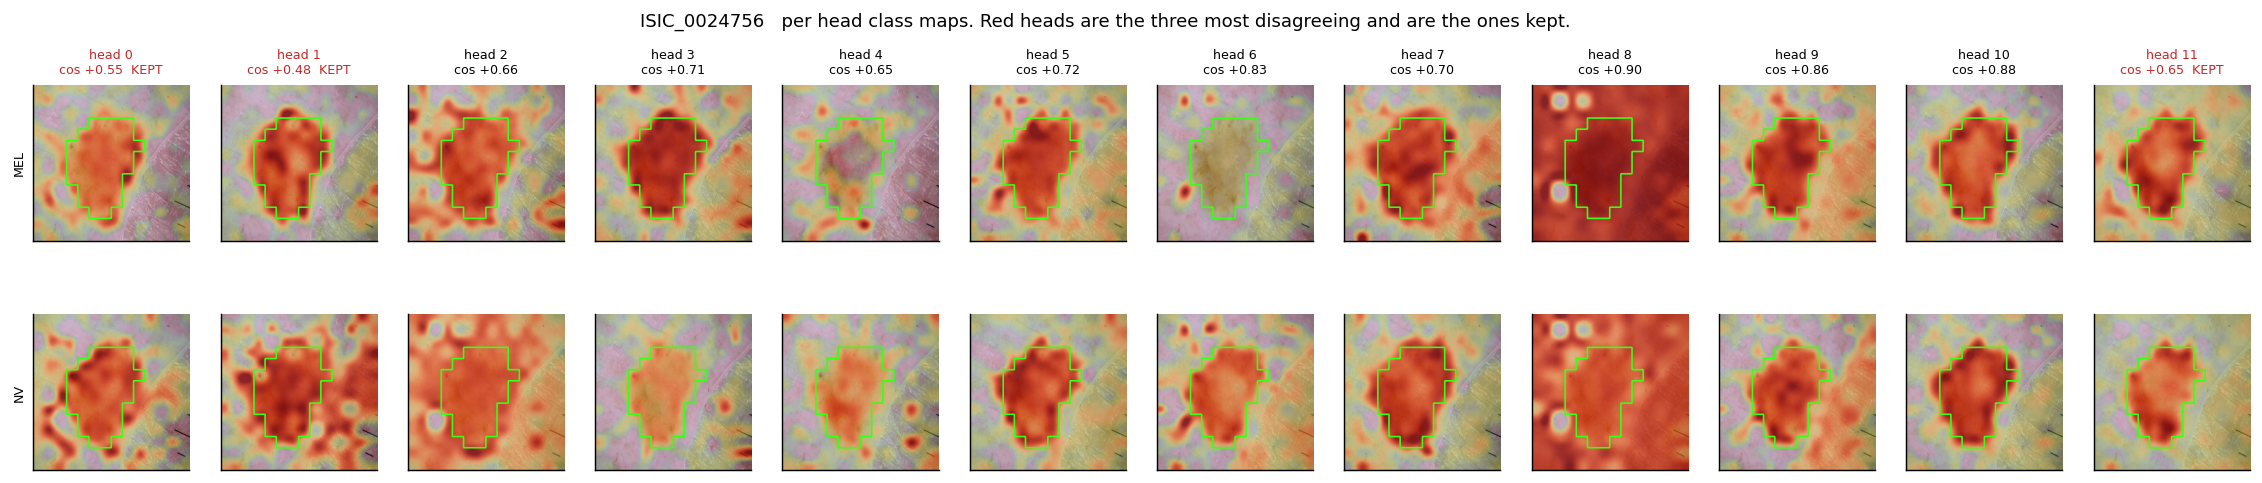

In [65]:
# ---- one image, all 12 heads, then uniform against top 3 --------------------
iid_w = sorted(HUM)[0]
row_w = eval_df.set_index("image_id").loc[iid_w]
x_w = to_tensor(native(row_w.image_rel_path))
rgb_w = transform_rgb(native(row_w.image_rel_path), GEOMETRY)
L_w, U_w = LESION[iid_w], HUM[iid_w]
g224 = lambda m: cv2.resize(m.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)
c_w, hm_w, hn_w = head_cosines(m_hw, x_w)
order = np.argsort(c_w)

def overlay(ax, rgb, cam, thresh=0.28, cmap="turbo", gamma=0.8, pct=None):
    c = np.asarray(cam, np.float32)
    if pct is not None:                      # rank based, robust to saturation
        c = (c >= np.percentile(c, pct)).astype(np.float32) * norm01(c)
    c = norm01(c)
    u = cv2.resize(c, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_CUBIC)
    al = np.clip((u - thresh) / (1 - thresh), 0, 1) ** gamma * 0.80
    ax.imshow(rgb)
    ax.imshow(u, cmap=cmap, alpha=al, vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(2, 12, figsize=(22, 4.2))
for j, h in enumerate(range(12)):
    for r, (t, lab) in enumerate([(hm_w, "MEL"), (hn_w, "NV")]):
        mp = norm01(t[h].cpu().numpy().reshape(CAM_GRID, CAM_GRID))
        overlay(ax[r, j], rgb_w, mp, thresh=0.3)
        ax[r, j].contour(g224(L_w), [.5], colors="#39FF14", linewidths=.9)
        if r == 0:
            ax[r, j].set_title(f"head {h}\ncos {c_w[h]:+.2f}"
                               + ("  KEPT" if h in order[:3] else ""),
                               fontsize=7,
                               color=C_MEL if h in order[:3] else "k")
        ax[r, j].set_ylabel(lab, fontsize=7) if j == 0 else None
fig.suptitle(f"{iid_w}   per head class maps. Red heads are the three most "
             f"disagreeing and are the ones kept.", fontsize=10)
plt.show()

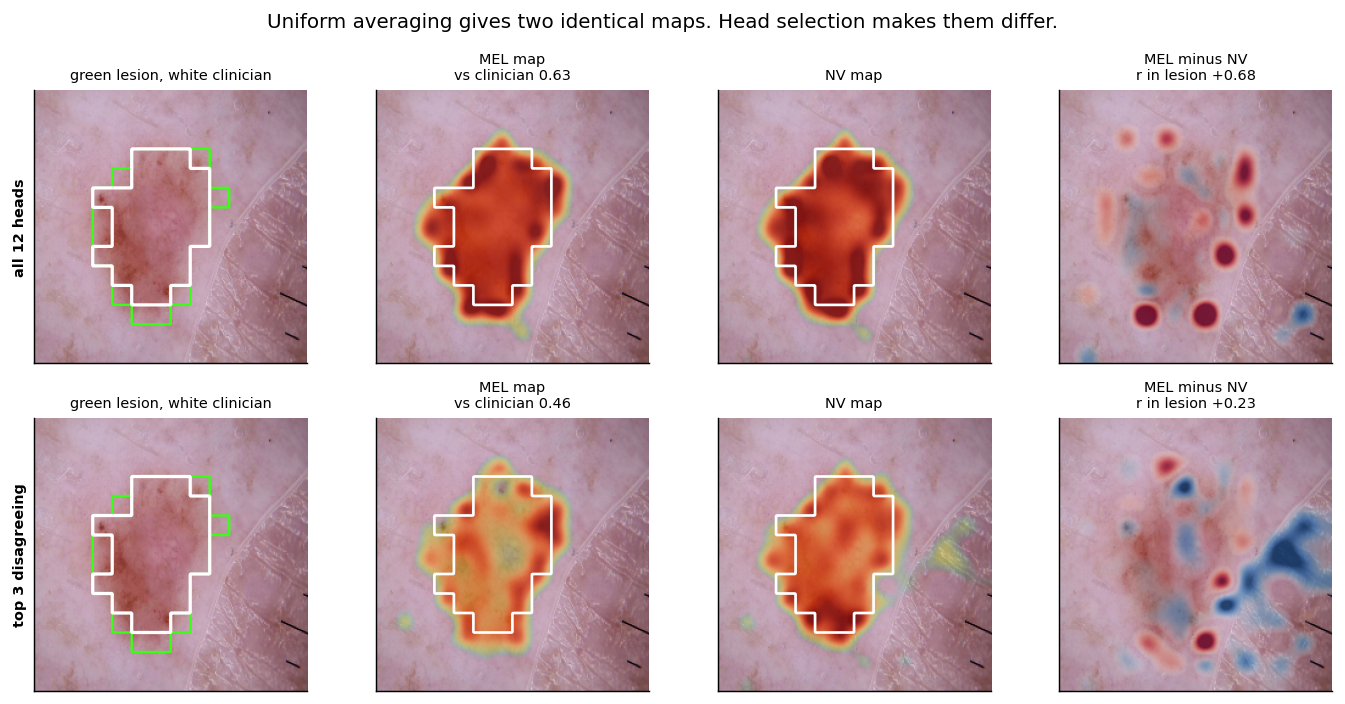

In [64]:
# ---- uniform against top 3, with the annotation overlaid --------------------
def overlay_signed(ax, rgb, cam, thresh=0.12):
    c = np.asarray(cam, np.float32)
    v = np.percentile(np.abs(c), 98) + 1e-8
    u = cv2.resize(c, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_CUBIC)
    al = np.clip((np.abs(u) / v - thresh) / (1 - thresh), 0, 1) ** 0.8 * 0.85
    ax.imshow(rgb)
    ax.imshow(u, cmap="RdBu_r", alpha=al, vmin=-v, vmax=v,
              interpolation="bilinear")
    ax.set_xticks([]); ax.set_yticks([])

tg = a_w if row_w.gt_label == "MEL" else b_w
au = roc_auc_score(ui, tg[L_w])
    
fig, ax = plt.subplots(2, 4, figsize=(13, 6))
for r, (mode, lab) in enumerate([("uniform", "all 12 heads"),
                                 ("topk", "top 3 disagreeing")]):
    cm_w, cn_w = cam_head_weighted(m_hw, x_w, mode, topk=3)
    a_w, b_w = norm01(cm_w), norm01(cn_w)
    rr = np.corrcoef(a_w[L_w], b_w[L_w])[0, 1]
    ui = U_w[L_w].astype(int)
    tg = a_w if row_w.gt_label == "MEL" else b_w
    au = roc_auc_score(ui, tg[L_w])

    ax[r, 0].imshow(rgb_w)
    ax[r, 0].contour(g224(L_w), [.5], colors="#39FF14", linewidths=1.3)
    ax[r, 0].contour(g224(U_w), [.5], colors="#FFFFFF", linewidths=1.8)
    ax[r, 0].set_title("green lesion, white clinician", fontsize=8)
    ax[r, 0].set_ylabel(lab, fontsize=8, fontweight="bold")
    for j, (v_, t_) in enumerate([(a_w, "MEL map"), (b_w, "NV map")]):
        overlay(ax[r, 1 + j], rgb_w, v_)
        ax[r, 1 + j].contour(g224(U_w), [.5], colors="#FFF", linewidths=1.5)
        extra = f"\nvs clinician {au:.2f}" if (t_ == "MEL map") == (row_w.gt_label == "MEL") else ""
        ax[r, 1 + j].set_title(t_ + extra, fontsize=8)
    overlay_signed(ax[r, 3], rgb_w, a_w - b_w)
    ax[r, 3].set_title(f"MEL minus NV\nr in lesion {rr:+.2f}", fontsize=8)
    for a_ in ax[r]:
        a_.set_xticks([]); a_.set_yticks([])
fig.suptitle("Uniform averaging gives two identical maps. "
             "Head selection makes them differ.", fontsize=11)
plt.show()

In [63]:
# ---- extra scores beyond AUC, all images ------------------------------------
rows_w = []
for iid_w2 in sorted(HUM):
    row2 = eval_df.set_index("image_id").loc[iid_w2]
    x2 = to_tensor(native(row2.image_rel_path))
    L2, U2 = LESION[iid_w2], HUM[iid_w2]
    ui2 = U2[L2].astype(int)
    if ui2.sum() == 0 or ui2.all():
        continue
    for mode in ["uniform", "topk"]:
        cm2, cn2 = cam_head_weighted(m_hw, x2, mode, topk=3)
        a2, b2 = norm01(cm2), norm01(cn2)
        tg2 = a2 if row2.gt_label == "MEL" else b2
        idx2 = np.flatnonzero(L2)
        k2 = max(1, int(round(0.10 * len(idx2))))
        hot2 = idx2[np.argsort(-tg2.ravel()[idx2])[:k2]]
        hotm = np.zeros(L2.size, bool); hotm[hot2] = True
        rows_w.append({
            "image_id": iid_w2, "mode": mode,
            "auc": roc_auc_score(ui2, tg2[L2]),
            "pointing": float(U2.ravel()[np.argmax(tg2.ravel() * L2.ravel())]),
            "mass_in_annot": float(tg2[U2 & L2].sum() / (tg2[L2].sum() + 1e-8)),
            "annot_frac": float((U2 & L2).sum() / L2.sum()),
            "iou_topk": float((hotm & U2.ravel()).sum()
                              / ((hotm | U2.ravel()).sum() + 1e-8)),
            "r_lesion": float(np.corrcoef(a2[L2], b2[L2])[0, 1])})
HW2 = pd.DataFrame(rows_w)
print(HW2.groupby("mode")[["auc", "pointing", "mass_in_annot", "annot_frac",
                           "iou_topk", "r_lesion"]].median().round(3).to_string())
print("\nmass_in_annot above annot_frac means heat prefers the annotated region")
for c in ["auc", "pointing", "mass_in_annot", "iou_topk", "r_lesion"]:
    q = HW2.pivot_table(index="image_id", columns="mode", values=c).dropna()
    _, pv = wilcoxon(q.topk, q.uniform)
    print(f"  {c:14} {q.uniform.median():+.3f} -> {q.topk.median():+.3f}   "
          f"p {pv:.2f}")

           auc  pointing  mass_in_annot  annot_frac  iou_topk  r_lesion
mode                                                                   
topk     0.720       1.0          0.721        0.68     0.118     0.487
uniform  0.743       1.0          0.710        0.68     0.107     0.909

mass_in_annot above annot_frac means heat prefers the annotated region
  auc            +0.743 -> +0.720   p 0.65
  pointing       +1.000 -> +1.000   p 0.48
  mass_in_annot  +0.710 -> +0.721   p 0.05
  iou_topk       +0.107 -> +0.118   p 0.16
  r_lesion       +0.909 -> +0.487   p 0.00


In [66]:
# =============================================================================
# Does head selection help FinerCAM.
#
# Two independent knobs, crossed.
#   alpha  strength of the class contrast, formed in logit space before ReLU
#   k      how many heads survive, selected by lowest MEL/NV cosine
#
# k=12 uniform reproduces the Section 3 alpha sweep, so that row is the
# control. Anything the combination buys must show up as a gain over it.
# =============================================================================
def finer_head_cam(model, x, gt_label, alpha=0.0, k=12, block=BLOCK):
    """FinerCAM contrast + per head selection, in one construction.

    Returns the target-class map and the reference-class map, both built
    from the SAME selected heads so the comparison is fair.
    """
    base = _unwrap_model(model)
    h, w = base.patch_embed.patch_shape
    ti, ri = (MEL_IDX, NV_IDX) if gt_label == "MEL" else (NV_IDX, MEL_IDX)

    base.clear_xai_state()
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        A = base.blocks[block].attn.last_attn
        y_t = logits[0, ti] - alpha * logits[0, ri]     # contrast for target
        y_r = logits[0, ri] - alpha * logits[0, ti]     # contrast for reference
        G_t = torch.autograd.grad(y_t, A, retain_graph=True)[0]
        G_r = torch.autograd.grad(y_r, A, retain_graph=True)[0]
    base.clear_xai_state()

    mp = bool(getattr(base, "use_mean_pooling", False))
    if mp:
        a = A[:, :, 1:, 1:]
        ht = (a * G_t[:, :, 1:, 1:]).sum(2)[0]          # [H, K]
        hr = (a * G_r[:, :, 1:, 1:]).sum(2)[0]
    else:
        a = A[:, :, 0, 1:]
        ht = (a * G_t[:, :, 0, 1:])[0]
        hr = (a * G_r[:, :, 0, 1:])[0]

    # head selection uses the SAME quantity as before, MEL vs NV cosine at
    # alpha 0, so k is comparable across the sweep
    cos_h = F.cosine_similarity(ht, hr, dim=1)
    wt = torch.zeros_like(cos_h)
    wt[cos_h.argsort()[:min(k, len(cos_h))]] = 1.0
    wt = wt / wt.sum()

    f = lambda t: F.relu((wt[:, None] * t).sum(0)).detach().cpu().numpy().reshape(h, w)
    return f(ht), f(hr), cos_h.detach().cpu().numpy()


# ---- validation. alpha 0 with k=12 must reproduce class_cams -----------------
iid_v2 = sorted(HUM)[0]
row_v2 = eval_df.set_index("image_id").loc[iid_v2]
x_v2 = to_tensor(native(row_v2.image_rel_path))
cm_v2, cn_v2 = class_cams(m_hw, x_v2)
ref_v2 = cm_v2 if row_v2.gt_label == "MEL" else cn_v2
t_v2, _, _ = finer_head_cam(m_hw, x_v2, row_v2.gt_label, alpha=0.0, k=12)
print(f"alpha 0, k 12 vs class_cams   corr "
      f"{np.corrcoef(t_v2.ravel(), ref_v2.ravel())[0, 1]:.6f}")
print("must be 1.000000 before trusting anything below\n")

alpha 0, k 12 vs class_cams   corr 1.000000
must be 1.000000 before trusting anything below



In [67]:
# ---- the 2 by 2 sweep --------------------------------------------------------
ALPHAS_C = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
KS_C = [3, 6, 12]

rows_c = []
for iid_c in sorted(HUM):
    row_c = eval_df.set_index("image_id").loc[iid_c]
    x_c = to_tensor(native(row_c.image_rel_path))
    L_c, U_c = LESION[iid_c], HUM[iid_c]
    ui_c = U_c[L_c].astype(int)
    if ui_c.sum() == 0 or ui_c.all():
        continue
    idx_c = np.flatnonzero(L_c)
    kk = max(1, int(round(0.10 * len(idx_c))))
    for al in ALPHAS_C:
        for k in KS_C:
            tm, rm, _ = finer_head_cam(m_hw, x_c, row_c.gt_label, al, k)
            t_n, r_n = norm01(tm), norm01(rm)
            hot = np.zeros(L_c.size, bool)
            hot[idx_c[np.argsort(-t_n.ravel()[idx_c])[:kk]]] = True
            rows_c.append({
                "image_id": iid_c, "gt_label": row_c.gt_label,
                "alpha": al, "k": k,
                "human_in": (roc_auc_score(ui_c, t_n[L_c])
                             if t_n[L_c].std() > 1e-9 else np.nan),
                "lesion_auc": (roc_auc_score(L_c.ravel(), t_n.ravel())
                               if t_n.std() > 1e-9 else np.nan),
                "r_lesion": (float(np.corrcoef(t_n[L_c], r_n[L_c])[0, 1])
                             if t_n[L_c].std() > 1e-9 and r_n[L_c].std() > 1e-9
                             else np.nan),
                "mass_in_annot": float(t_n[U_c & L_c].sum()
                                       / (t_n[L_c].sum() + 1e-8)),
                "iou_topk": float((hot & U_c.ravel()).sum()
                                  / ((hot | U_c.ravel()).sum() + 1e-8))})
    print(".", end="", flush=True)

FH = pd.DataFrame(rows_c)
FH.to_csv(OUT / "s3_finer_x_head.csv", index=False)
print(f"\n{FH.image_id.nunique()} images\n")

for col in ["human_in", "r_lesion", "lesion_auc"]:
    print(f"{col}")
    print(FH.pivot_table(index="alpha", columns="k", values=col,
                         aggfunc="median").round(3).to_string())
    print()

print("centre baseline 0.828   annotation covers 0.68 of the lesion\n")
base_med = FH.query("alpha==0 and k==12").human_in.median()
print(f"control, alpha 0 k 12   {base_med:.3f}\n")
print("every cell against that control, paired")
for al in ALPHAS_C:
    for k in KS_C:
        if al == 0 and k == 12:
            continue
        a_ = FH.query("alpha==@al and k==@k").set_index("image_id").human_in
        b_ = FH.query("alpha==0 and k==12").set_index("image_id").human_in
        q = pd.concat([a_.rename("x"), b_.rename("y")], axis=1).dropna()
        if len(q) < 5:
            continue
        _, pv = wilcoxon(q.x, q.y)
        d = (q.x - q.y).median()
        flag = "  BETTER" if d > 0 and pv < 0.05 else ("  worse" if d < 0 and pv < 0.05 else "")
        print(f"  alpha {al:<4g} k {k:<3} {q.x.median():.3f}   "
              f"diff {d:+.3f}   p {pv:.3f}{flag}")

best = FH.groupby(["alpha", "k"]).human_in.median().idxmax()
print(f"\nbest cell {best}, median {FH.groupby(['alpha','k']).human_in.median().max():.3f}")
print(f"still below the 0.828 baseline: "
      f"{FH.groupby(['alpha','k']).human_in.median().max() < 0.828}")

...............................
31 images

human_in
k         3      6      12
alpha                     
0.0    0.720  0.714  0.743
0.2    0.689  0.723  0.716
0.4    0.607  0.637  0.673
0.6    0.516  0.539  0.621
0.8    0.415  0.431  0.528
1.0    0.515  0.457  0.372

r_lesion
k         3      6      12
alpha                     
0.0    0.487  0.643  0.909
0.2    0.059  0.257  0.799
0.4   -0.259 -0.148  0.531
0.6   -0.670 -0.448 -0.110
0.8   -0.526 -0.583 -0.481
1.0   -0.385 -0.395 -0.397

lesion_auc
k         3      6      12
alpha                     
0.0    0.973  0.983  0.987
0.2    0.924  0.977  0.985
0.4    0.789  0.941  0.979
0.6    0.697  0.840  0.958
0.8    0.481  0.535  0.816
1.0    0.471  0.515  0.483

centre baseline 0.828   annotation covers 0.68 of the lesion

control, alpha 0 k 12   0.743

every cell against that control, paired
  alpha 0    k 3   0.720   diff -0.041   p 0.650
  alpha 0    k 6   0.714   diff +0.001   p 0.870
  alpha 0.2  k 3   0.689   diff -0.058   p 0.1

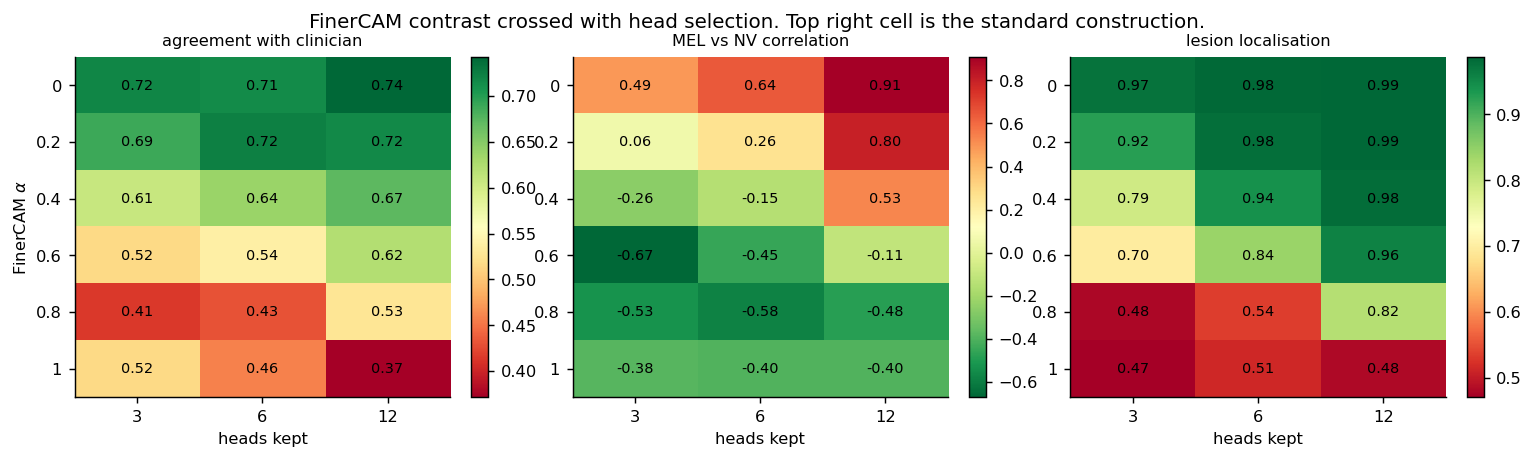

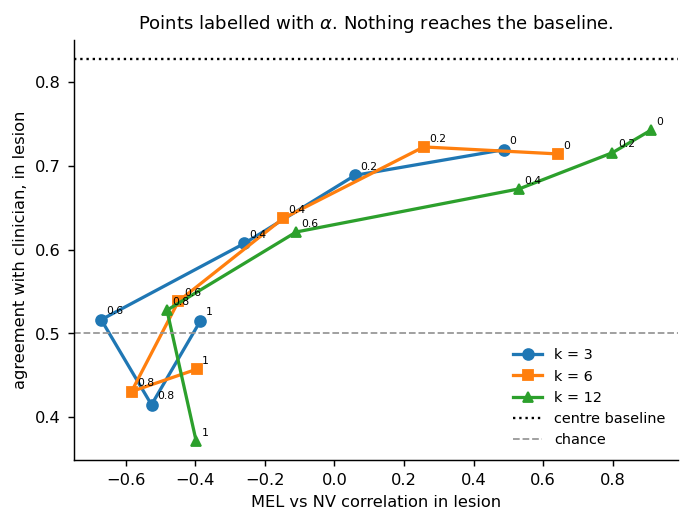

In [68]:
# ---- heatmap of the 2 by 2 grid ---------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
for i, (col, ttl, cmap) in enumerate([
        ("human_in", "agreement with clinician", "RdYlGn"),
        ("r_lesion", "MEL vs NV correlation", "RdYlGn_r"),
        ("lesion_auc", "lesion localisation", "RdYlGn")]):
    piv = FH.pivot_table(index="alpha", columns="k", values=col, aggfunc="median")
    im = ax[i].imshow(piv.values, cmap=cmap, aspect="auto")
    ax[i].set(xticks=range(len(piv.columns)), yticks=range(len(piv.index)),
              xticklabels=piv.columns, yticklabels=[f"{a:g}" for a in piv.index],
              xlabel="heads kept", ylabel=r"FinerCAM $\alpha$" if i == 0 else "")
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            ax[i].text(c, r, f"{piv.values[r, c]:.2f}", ha="center",
                       va="center", fontsize=8)
    ax[i].set_title(ttl, fontsize=9)
    plt.colorbar(im, ax=ax[i], fraction=.045)
fig.suptitle("FinerCAM contrast crossed with head selection. "
             "Top right cell is the standard construction.", fontsize=11)
fig.savefig(OUT / "fig_finer_x_head_grid.png")
plt.show()

# ---- the tradeoff curve ------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4.2))
for k, mk in zip(KS_C, ["o", "s", "^"]):
    s = FH[FH.k == k].groupby("alpha")[["r_lesion", "human_in"]].median()
    ax.plot(s.r_lesion, s.human_in, marker=mk, lw=1.8, ms=6, label=f"k = {k}")
    for al in ALPHAS_C:
        if al in s.index:
            ax.annotate(f"{al:g}", (s.loc[al, "r_lesion"], s.loc[al, "human_in"]),
                        fontsize=6, xytext=(3, 3), textcoords="offset points")
ax.axhline(0.828, color="k", ls=":", lw=1.3, label="centre baseline")
ax.axhline(0.5, color="#999", ls="--", lw=1, label="chance")
ax.set(xlabel="MEL vs NV correlation in lesion",
       ylabel="agreement with clinician, in lesion")
ax.legend(frameon=False, fontsize=8)
ax.set_title(r"Points labelled with $\alpha$. Nothing reaches the baseline.",
             fontsize=10)
fig.savefig(OUT / "fig_finer_x_head_tradeoff.png")
plt.show()

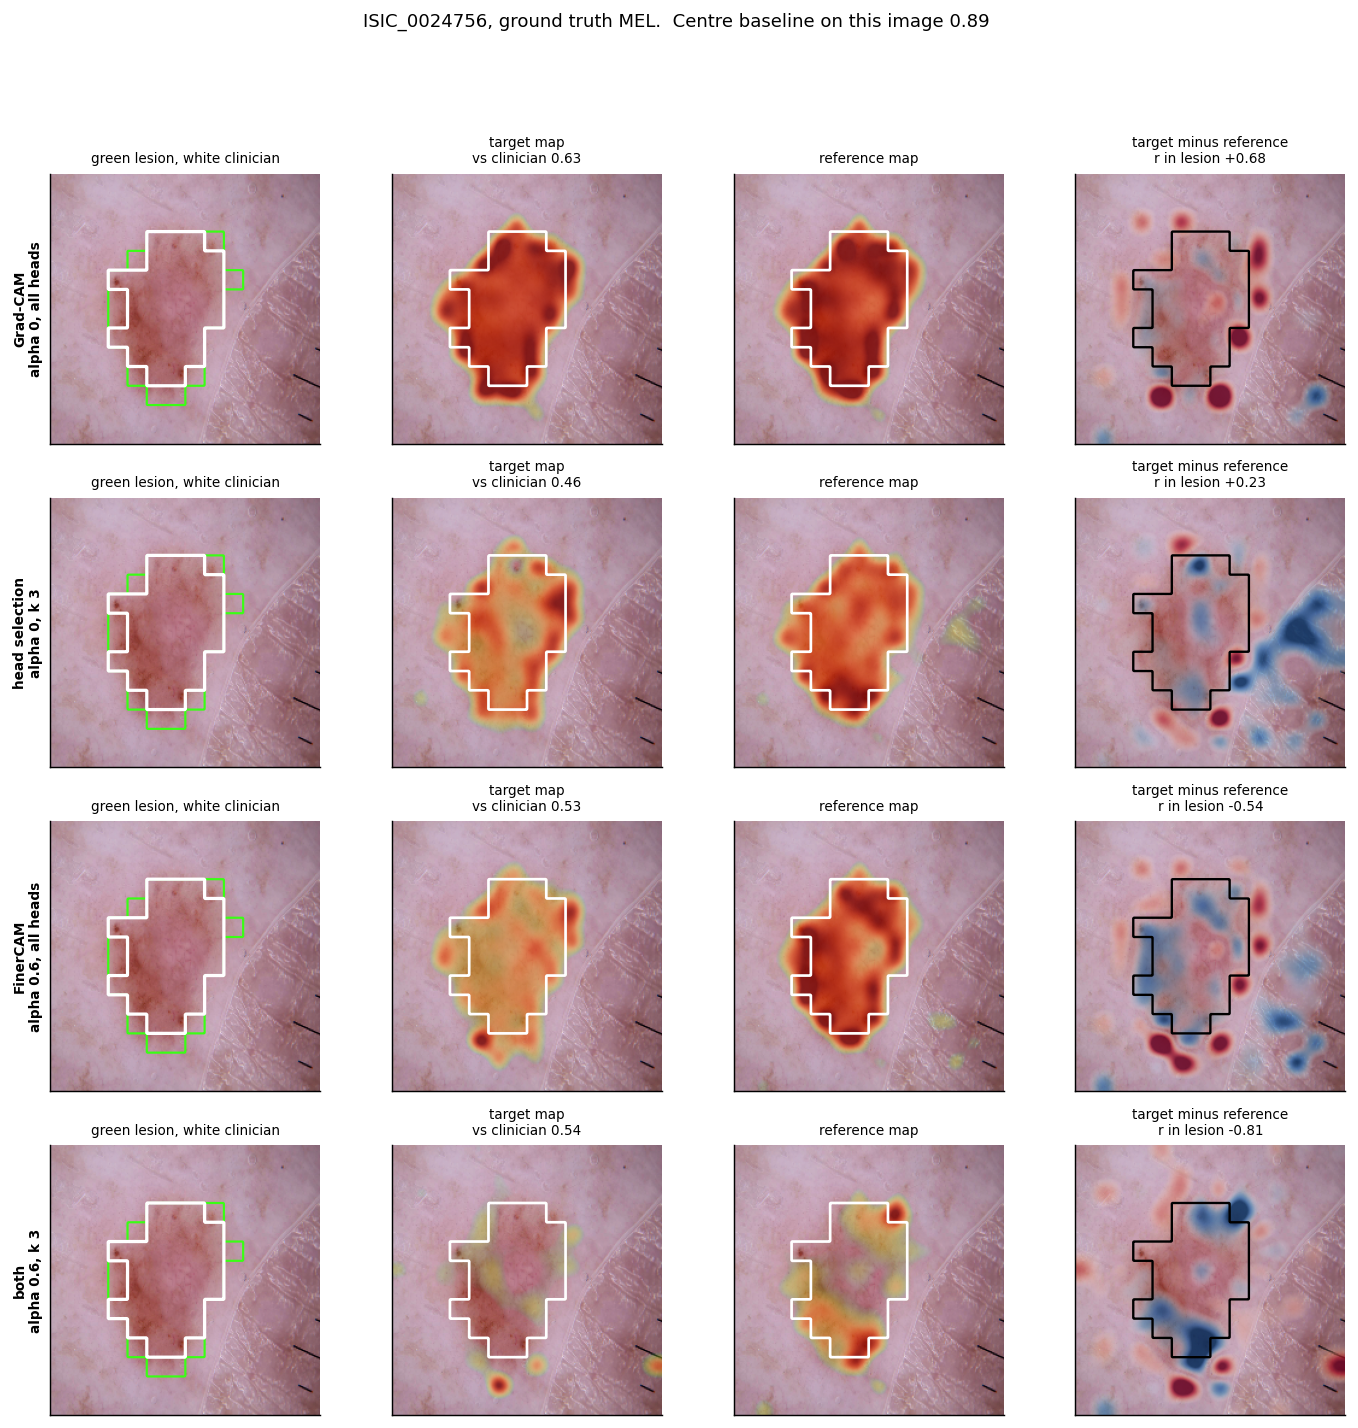

In [69]:
# ---- one image, four constructions -------------------------------------------
iid_f = sorted(HUM)[0]
row_f = eval_df.set_index("image_id").loc[iid_f]
x_f = to_tensor(native(row_f.image_rel_path))
rgb_f = transform_rgb(native(row_f.image_rel_path), GEOMETRY)
L_f, U_f = LESION[iid_f], HUM[iid_f]
ui_f = U_f[L_f].astype(int)
g224 = lambda m: cv2.resize(m.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)

CFG = [(0.0, 12, "Grad-CAM\nalpha 0, all heads"),
       (0.0, 3,  "head selection\nalpha 0, k 3"),
       (0.6, 12, "FinerCAM\nalpha 0.6, all heads"),
       (0.6, 3,  "both\nalpha 0.6, k 3")]

fig, ax = plt.subplots(len(CFG), 4, figsize=(13, 3.1 * len(CFG)))
for i, (al, k, lab) in enumerate(CFG):
    tm, rm, cos_h = finer_head_cam(m_hw, x_f, row_f.gt_label, al, k)
    t_n, r_n = norm01(tm), norm01(rm)
    au = roc_auc_score(ui_f, t_n[L_f]) if t_n[L_f].std() > 1e-9 else np.nan
    rr = (np.corrcoef(t_n[L_f], r_n[L_f])[0, 1]
          if t_n[L_f].std() > 1e-9 and r_n[L_f].std() > 1e-9 else np.nan)

    ax[i, 0].imshow(rgb_f)
    ax[i, 0].contour(g224(L_f), [.5], colors="#39FF14", linewidths=1.2)
    ax[i, 0].contour(g224(U_f), [.5], colors="#FFFFFF", linewidths=1.8)
    ax[i, 0].set_ylabel(lab, fontsize=7.5, fontweight="bold")
    ax[i, 0].set_title("green lesion, white clinician", fontsize=7.5)

    overlay(ax[i, 1], rgb_f, t_n, thresh=0.35)
    ax[i, 1].contour(g224(U_f), [.5], colors="#FFF", linewidths=1.5)
    ax[i, 1].set_title(f"target map\nvs clinician {au:.2f}", fontsize=7.5)

    overlay(ax[i, 2], rgb_f, r_n, thresh=0.35)
    ax[i, 2].contour(g224(U_f), [.5], colors="#FFF", linewidths=1.5)
    ax[i, 2].set_title("reference map", fontsize=7.5)

    overlay_signed(ax[i, 3], rgb_f, t_n - r_n)
    ax[i, 3].contour(g224(U_f), [.5], colors="#000", linewidths=1.3)
    ax[i, 3].set_title(f"target minus reference\nr in lesion {rr:+.2f}",
                       fontsize=7.5)
    for a_ in ax[i]:
        a_.set_xticks([]); a_.set_yticks([])

fig.suptitle(f"{iid_f}, ground truth {row_f.gt_label}.  "
             f"Centre baseline on this image "
             f"{roc_auc_score(ui_f, centre_map(L_f)[L_f]):.2f}", fontsize=10)
fig.savefig(OUT / "fig_finer_x_head_example.png")
plt.show()

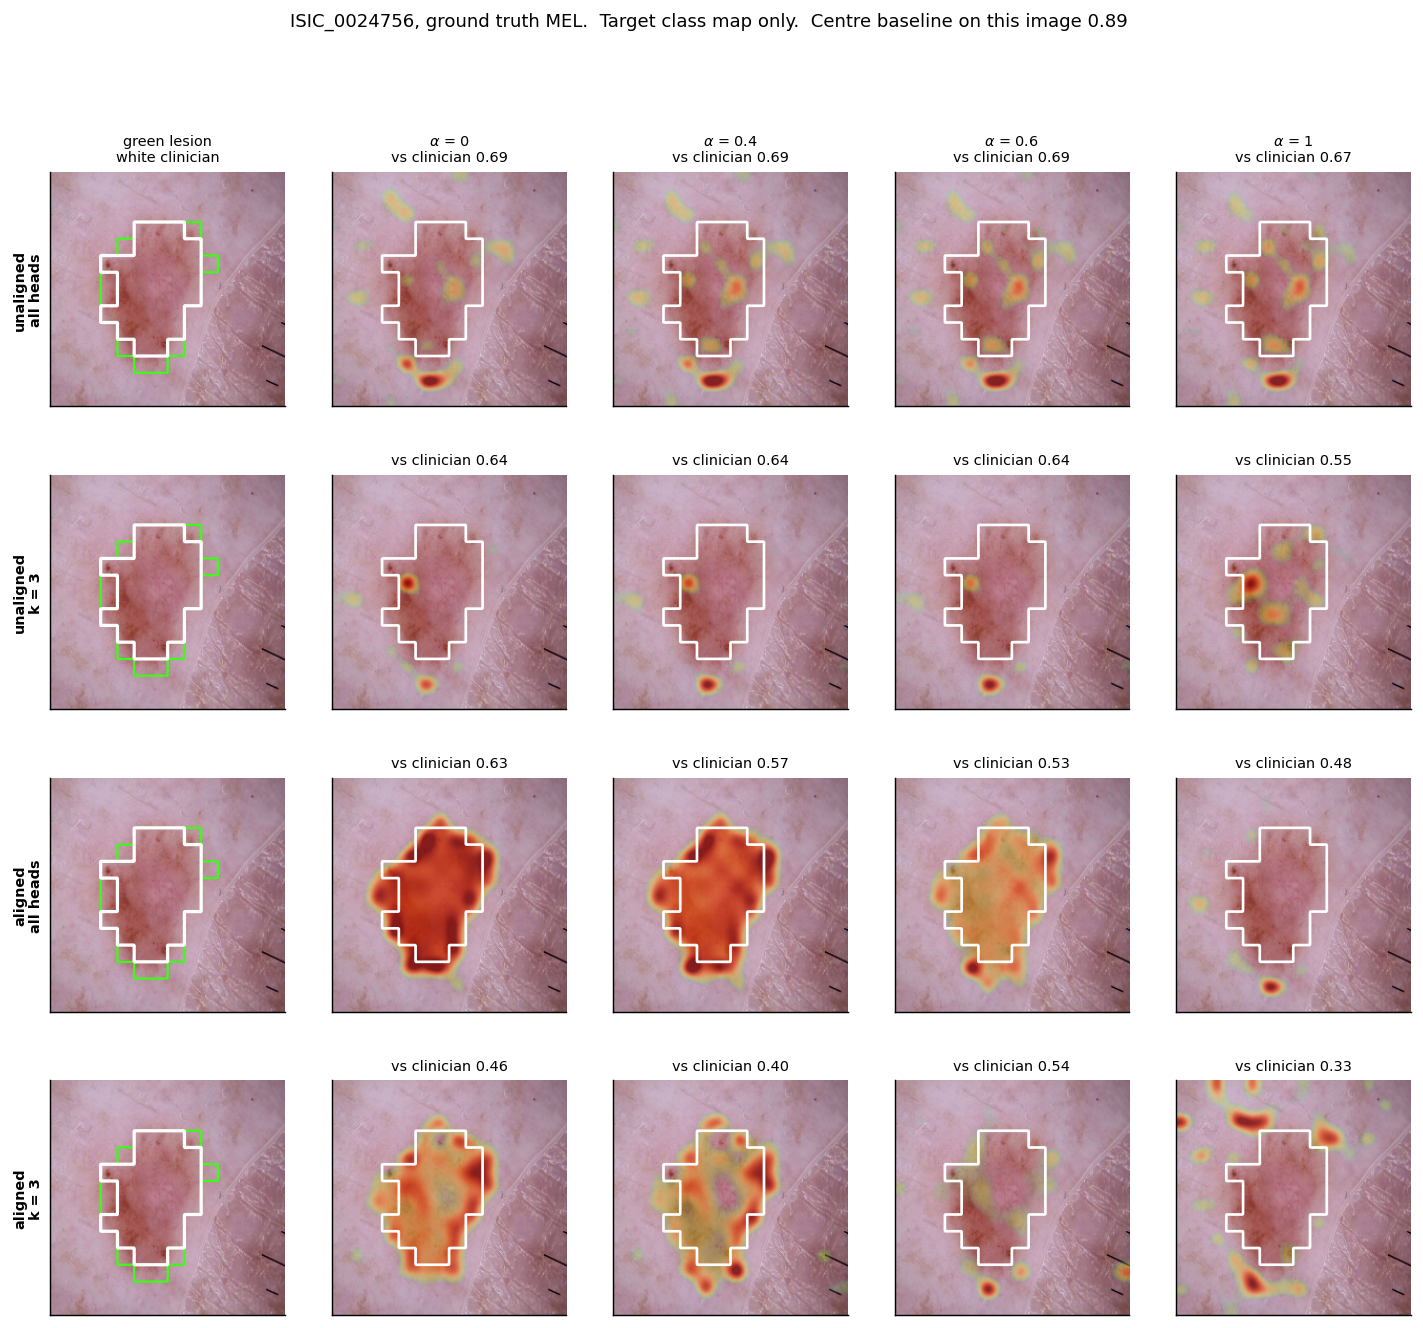

In [70]:
# =============================================================================
# Unaligned vs aligned, target class map only.
# Rows: model x head setting. Columns: FinerCAM alpha.
# Every panel is scored against the clinician annotation, in lesion.
# =============================================================================
m_ha0 = load_model("gap", "ha0")
m_ha5 = load_model("gap", "ha5")

iid_g = sorted(HUM)[0]
row_g = eval_df.set_index("image_id").loc[iid_g]
x_g = to_tensor(native(row_g.image_rel_path))
rgb_g = transform_rgb(native(row_g.image_rel_path), GEOMETRY)
L_g, U_g = LESION[iid_g], HUM[iid_g]
ui_g = U_g[L_g].astype(int)
g224 = lambda m: cv2.resize(m.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)

ALPHA_SHOW = [0.0, 0.4, 0.6, 1.0]
ROWS = [(m_ha0, 12, "unaligned\nall heads"),
        (m_ha0, 3,  "unaligned\nk = 3"),
        (m_ha5, 12, "aligned\nall heads"),
        (m_ha5, 3,  "aligned\nk = 3")]

ncol = len(ALPHA_SHOW) + 1
fig, ax = plt.subplots(len(ROWS), ncol, figsize=(2.7 * ncol, 2.9 * len(ROWS)))

for i, (mdl, k, lab) in enumerate(ROWS):
    ax[i, 0].imshow(rgb_g)
    ax[i, 0].contour(g224(L_g), [.5], colors="#39FF14", linewidths=1.2)
    ax[i, 0].contour(g224(U_g), [.5], colors="#FFFFFF", linewidths=1.8)
    ax[i, 0].set_ylabel(lab, fontsize=8, fontweight="bold")
    if i == 0:
        ax[i, 0].set_title("green lesion\nwhite clinician", fontsize=8)

    for j, al in enumerate(ALPHA_SHOW):
        tm, _, _ = finer_head_cam(mdl, x_g, row_g.gt_label, al, k)
        t_n = norm01(tm)
        au = (roc_auc_score(ui_g, t_n[L_g]) if t_n[L_g].std() > 1e-9 else np.nan)
        overlay(ax[i, j + 1], rgb_g, t_n, thresh=0.35)
        ax[i, j + 1].contour(g224(U_g), [.5], colors="#FFF", linewidths=1.5)
        ttl = (rf"$\alpha$ = {al:g}" + "\n") if i == 0 else ""
        ax[i, j + 1].set_title(f"{ttl}vs clinician {au:.2f}", fontsize=8)

    for a_ in ax[i]:
        a_.set_xticks([]); a_.set_yticks([])

cb = roc_auc_score(ui_g, centre_map(L_g)[L_g])
fig.suptitle(f"{iid_g}, ground truth {row_g.gt_label}.  Target class map only.  "
             f"Centre baseline on this image {cb:.2f}", fontsize=10)
fig.savefig(OUT / "fig_finer_unaligned_aligned.png")
plt.show()

In [71]:
rows_u = []
for iid_u in sorted(HUM):
    row_u = eval_df.set_index("image_id").loc[iid_u]
    x_u = to_tensor(native(row_u.image_rel_path))
    L_u, U_u = LESION[iid_u], HUM[iid_u]
    ui_u = U_u[L_u].astype(int)
    if ui_u.sum() == 0 or ui_u.all():
        continue
    for mdl, ck in [(m_ha0, "unaligned"), (m_ha5, "aligned")]:
        for k in [3, 12]:
            for al in ALPHA_SHOW:
                tm, rm, _ = finer_head_cam(mdl, x_u, row_u.gt_label, al, k)
                t_n, r_n = norm01(tm), norm01(rm)
                rows_u.append({
                    "image_id": iid_u, "model": ck, "k": k, "alpha": al,
                    "human_in": (roc_auc_score(ui_u, t_n[L_u])
                                 if t_n[L_u].std() > 1e-9 else np.nan),
                    "lesion_auc": (roc_auc_score(L_u.ravel(), t_n.ravel())
                                   if t_n.std() > 1e-9 else np.nan),
                    "r_lesion": (float(np.corrcoef(t_n[L_u], r_n[L_u])[0, 1])
                                 if t_n[L_u].std() > 1e-9 and r_n[L_u].std() > 1e-9
                                 else np.nan)})
    print(".", end="", flush=True)

UA = pd.DataFrame(rows_u)
UA.to_csv(OUT / "s3_finer_unaligned_aligned.csv", index=False)
print(f"\n\ncentre baseline {UA.get('centre', pd.Series([0.828])).median():.3f}\n")
for col in ["human_in", "lesion_auc", "r_lesion"]:
    print(col)
    print(UA.pivot_table(index=["model", "k"], columns="alpha",
                         values=col, aggfunc="median").round(3).to_string())
    print()

print("aligned minus unaligned, paired, at each setting")
for k in [3, 12]:
    for al in ALPHA_SHOW:
        q = (UA.query("k==@k and alpha==@al")
             .pivot_table(index="image_id", columns="model", values="human_in")
             .dropna())
        if len(q) < 5:
            continue
        _, pv = wilcoxon(q.aligned, q.unaligned)
        print(f"  k {k:<3} alpha {al:<4g}  "
              f"{q.unaligned.median():.3f} -> {q.aligned.median():.3f}   "
              f"diff {(q.aligned - q.unaligned).median():+.3f}   p {pv:.3f}")

...............................

centre baseline 0.828

human_in
alpha           0.0    0.4    0.6    1.0
model     k                             
aligned   3   0.720  0.607  0.516  0.515
          12  0.743  0.673  0.621  0.372
unaligned 3   0.424  0.461  0.475  0.491
          12  0.543  0.542  0.548  0.521

lesion_auc
alpha           0.0    0.4    0.6    1.0
model     k                             
aligned   3   0.973  0.789  0.697  0.471
          12  0.987  0.979  0.958  0.483
unaligned 3   0.667  0.671  0.610  0.575
          12  0.568  0.581  0.590  0.581

r_lesion
alpha           0.0    0.4    0.6    1.0
model     k                             
aligned   3   0.487 -0.259 -0.670 -0.385
          12  0.909  0.531 -0.110 -0.397
unaligned 3  -0.307 -0.380 -0.382 -0.441
          12 -0.329 -0.415 -0.426 -0.424

aligned minus unaligned, paired, at each setting
  k 3   alpha 0     0.424 -> 0.714   diff +0.219   p 0.000
  k 3   alpha 0.4   0.508 -> 0.581   diff +0.099   p 0.247
  k 3  

In [73]:
def finer_cam(model, x, gt_label, alpha=0.6, block=BLOCK):
    """Finer-CAM built on the SAME reduction as class_cams. The contrast is
    formed in logit space, then passed to build_attention_gradcam_map as a
    single column logit tensor so the downstream path is byte identical."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    ti, ri = (MEL_IDX, NV_IDX) if gt_label == "MEL" else (NV_IDX, MEL_IDX)
    with torch.enable_grad():
        logits, _ = unpack_model_outputs(
            model(x, return_patch_tokens=True, store_attn=True, attn_layer=block))
        y = (logits[:, ti] - alpha * logits[:, ri]).unsqueeze(1)   # [B, 1]
        t = torch.zeros(1, dtype=torch.long, device=logits.device)
        cam = build_attention_gradcam_map(model, y, t, create_graph=False).detach()
    base.clear_xai_state()
    return cam[0].float().cpu().numpy()

In [74]:
# =============================================================================
# PIPELINE AUDIT. Run before trusting any result.
#
# Every check is an INVARIANT, something that must hold regardless of what
# the experiment finds. A failure means the code is wrong, not that the
# result is surprising.
#
# Section E reintroduces the historical MEL-minus-NV bug on purpose and
# confirms the audit detects it.
# =============================================================================
import types
CHECKS = []
def chk(name, ok, detail=""):
    CHECKS.append({"check": name, "pass": bool(ok), "detail": str(detail)[:70]})
    print(f"  {'PASS' if ok else 'FAIL'}  {name}   {detail}")

print("=" * 78)
print("A. ENVIRONMENT")
print("=" * 78)
for m in ["np", "pd", "torch", "cv2", "F"]:
    chk(f"{m} is a module", m in globals() and isinstance(globals()[m], types.ModuleType),
        type(globals().get(m)).__name__)
for fn in ["class_cams", "finer_cam", "head_maps", "centre_map", "norm01",
           "to_tensor", "native", "load_model"]:
    chk(f"{fn} defined", fn in globals() and callable(globals()[fn]))

print("\n" + "=" * 78)
print("B. DATA LAYER")
print("=" * 78)

chk("MEL_IDX is 0, NV_IDX is 1", (MEL_IDX, NV_IDX) == (0, 1), f"{MEL_IDX},{NV_IDX}")

lm = eval_df.groupby("gt_label").binary_label.unique().to_dict() \
     if "binary_label" in eval_df.columns else {}
if lm:
    chk("gt_label MEL maps to binary_label 0",
        list(lm.get("MEL", [])) == [MEL_IDX], lm)

les_ok = all(v.dtype == bool and 0 < v.sum() < v.size for v in LESION.values())
chk("all lesion masks boolean and non degenerate", les_ok,
    f"{len(LESION)} masks")
chk("lesion grid is CAM_GRID square",
    all(v.shape == (CAM_GRID, CAM_GRID) for v in LESION.values()),
    f"{CAM_GRID}x{CAM_GRID}")

la = np.array([v.mean() for v in LESION.values()])
chk("median lesion coverage near 0.25", 0.20 < np.median(la) < 0.30,
    f"{np.median(la):.3f}")

hum_ok = all(v.shape == (CAM_GRID, CAM_GRID) and v.dtype == bool
             for v in HUM.values())
chk("all HUM masks boolean, correct grid", hum_ok, f"{len(HUM)} masks")

inside = np.array([(HUM[i] & LESION[i]).sum() / max(HUM[i].sum(), 1) for i in HUM])
chk("clinician annotations mostly inside the lesion", np.median(inside) > 0.85,
    f"median {np.median(inside):.3f}")

both = np.array([0 < HUM[i][LESION[i]].sum() < LESION[i].sum() for i in HUM])
chk("every HUM image has positives AND negatives in lesion", both.all(),
    f"{both.sum()} of {len(both)}")

print("\n" + "=" * 78)
print("C. MODEL LAYER")
print("=" * 78)

m0, m5 = load_model("gap", "ha0"), load_model("gap", "ha5")
chk("ha0 and ha5 are different objects", m0 is not m5)

_p0 = torch.cat([p.flatten()[:50] for p in list(m0.parameters())[:5]])
_p5 = torch.cat([p.flatten()[:50] for p in list(m5.parameters())[:5]])
chk("ha0 and ha5 have different weights",
    not torch.allclose(_p0, _p5), f"maxdiff {(_p0 - _p5).abs().max():.3e}")

_b = _unwrap_model(m5)
chk("model uses mean pooling for GAP", bool(getattr(_b, "use_mean_pooling", False)))
chk("patch grid matches CAM_GRID", _b.patch_embed.patch_shape == (CAM_GRID, CAM_GRID),
    _b.patch_embed.patch_shape)
chk("params require grad", all(p.requires_grad for p in list(m5.parameters())[:20]))

print("\n" + "=" * 78)
print("D. CAM CONSTRUCTION")
print("=" * 78)

iid_a = sorted(HUM)[0]
row_a = eval_df.set_index("image_id").loc[iid_a]
x_a = to_tensor(native(row_a.image_rel_path))
cm_a, cn_a = class_cams(m5, x_a)

chk("class_cams returns CAM_GRID square", cm_a.shape == (CAM_GRID, CAM_GRID), cm_a.shape)
chk("CAM is non negative after ReLU", cm_a.min() >= -1e-6, f"min {cm_a.min():.2e}")
chk("MEL and NV maps are not literally identical",
    not np.allclose(cm_a, cn_a), f"maxdiff {np.abs(cm_a - cn_a).max():.3e}")
chk("CAM has variance", cm_a.std() > 1e-6, f"std {cm_a.std():.3e}")

# determinism, same input twice
cm_b, _ = class_cams(m5, x_a)
chk("class_cams is deterministic", np.allclose(cm_a, cm_b, atol=1e-6),
    f"maxdiff {np.abs(cm_a - cm_b).max():.2e}")

# different images give different maps
iid_a2 = sorted(HUM)[1]
row_a2 = eval_df.set_index("image_id").loc[iid_a2]
cm_a2, _ = class_cams(m5, to_tensor(native(row_a2.image_rel_path)))
chk("different images give different maps", not np.allclose(cm_a, cm_a2),
    f"corr {np.corrcoef(cm_a.ravel(), cm_a2.ravel())[0,1]:+.3f}")

# head maps must average back to the full CAM
hm_a, hn_a = head_maps(m5, x_a)
rec = F.relu(hm_a.mean(0)).cpu().numpy().reshape(CAM_GRID, CAM_GRID)
chk("head maps average back to class_cams",
    np.corrcoef(norm01(rec).ravel(), norm01(cm_a).ravel())[0, 1] > 0.9999,
    f"corr {np.corrcoef(norm01(rec).ravel(), norm01(cm_a).ravel())[0,1]:.6f}")

# FinerCAM at alpha 0 must BE Grad-CAM
ref_a = cm_a if row_a.gt_label == "MEL" else cn_a
f0 = finer_cam(m5, x_a, row_a.gt_label, 0.0)
chk("finer_cam(alpha=0) equals the target Grad-CAM",
    np.corrcoef(f0.ravel(), ref_a.ravel())[0, 1] > 0.99999,
    f"corr {np.corrcoef(f0.ravel(), ref_a.ravel())[0,1]:.6f}")

if "finer_head_cam" in globals():
    fh0, _, _ = finer_head_cam(m5, x_a, row_a.gt_label, 0.0, 12)
    chk("finer_head_cam(alpha=0, k=12) equals the target Grad-CAM",
        np.corrcoef(fh0.ravel(), ref_a.ravel())[0, 1] > 0.99999,
        f"corr {np.corrcoef(fh0.ravel(), ref_a.ravel())[0,1]:.6f}")
    fh3, _, _ = finer_head_cam(m5, x_a, row_a.gt_label, 0.0, 3)
    chk("k=3 differs from k=12", not np.allclose(fh0, fh3))

print("\n" + "=" * 78)
print("E. TARGET SELECTION, the bug that bit before")
print("=" * 78)

def target_ref(model, x, gt_label):
    """The ONLY correct way to pick target and reference."""
    a, b = class_cams(model, x)
    return (a, b) if gt_label == "MEL" else (b, a)

mel_ids = [i for i in sorted(HUM)
           if eval_df.set_index("image_id").loc[i].gt_label == "MEL"]
nv_ids = [i for i in sorted(HUM)
          if eval_df.set_index("image_id").loc[i].gt_label == "NV"]
chk("both classes present in HUM", len(mel_ids) > 3 and len(nv_ids) > 3,
    f"MEL {len(mel_ids)}, NV {len(nv_ids)}")

# on a MEL image target must be the MEL map
im = mel_ids[0]
xm = to_tensor(native(eval_df.set_index("image_id").loc[im].image_rel_path))
am, bm = class_cams(m5, xm)
tm, rm = target_ref(m5, xm, "MEL")
chk("MEL image: target IS the MEL map", np.allclose(tm, am))

# on an NV image target must be the NV map
iv = nv_ids[0]
xv = to_tensor(native(eval_df.set_index("image_id").loc[iv].image_rel_path))
av, bv = class_cams(m5, xv)
tv, rv = target_ref(m5, xv, "NV")
chk("NV image: target IS the NV map", np.allclose(tv, bv))
chk("NV image: target is NOT the MEL map", not np.allclose(tv, av))

# the historical bug, reproduced on purpose
d_correct = np.maximum(tv - rv, 0)
d_buggy = np.maximum(av - bv, 0)
Lv = LESION[iv]
sgn = np.corrcoef((tv - rv)[Lv], (av - bv)[Lv])[0, 1]
chk("BUG DETECTOR: on NV, correct and buggy diff are opposite",
    sgn < -0.99, f"corr {sgn:+.4f}, must be -1")
chk("BUG DETECTOR: correct and buggy give different maps",
    not np.allclose(d_correct, d_buggy))

print("\n" + "=" * 78)
print("F. SCORING LAYER")
print("=" * 78)

ui_a = HUM[iid_a][LESION[iid_a]].astype(int)
v_a = norm01(ref_a)[LESION[iid_a]]
au = roc_auc_score(ui_a, v_a)

chk("AUC is rank invariant under positive scaling",
    abs(roc_auc_score(ui_a, v_a * 7.3) - au) < 1e-12,
    f"{au:.6f} vs {roc_auc_score(ui_a, v_a * 7.3):.6f}")
chk("AUC is rank invariant under positive shift",
    abs(roc_auc_score(ui_a, v_a + 5.0) - au) < 1e-12)
chk("negating the map gives 1 minus AUC",
    abs(roc_auc_score(ui_a, -v_a) - (1 - au)) < 1e-12,
    f"{roc_auc_score(ui_a, -v_a):.4f} vs {1-au:.4f}")
chk("argument order is (labels, scores)",
    roc_auc_score(ui_a, ui_a.astype(float)) == 1.0,
    "perfect score when scores equal labels")

cmap_a = centre_map(LESION[iid_a])
cy, cx = center_of_mass(LESION[iid_a].astype(float))
peak = np.unravel_index(cmap_a.argmax(), cmap_a.shape)
chk("centre map peaks at the LESION centroid, not image centre",
    abs(peak[0] - cy) < 1.5 and abs(peak[1] - cx) < 1.5,
    f"peak {peak}, centroid ({cy:.1f},{cx:.1f})")
chk("centre map is independent of any model",
    "model" not in centre_map.__code__.co_varnames)

print("\n" + "=" * 78)
print("G. REFERENCE VALUES, must reproduce")
print("=" * 78)

REF = [("lesion coverage median", np.median(la), 0.25, 0.03),
       ("centre baseline median",
        np.median([roc_auc_score(HUM[i][LESION[i]].astype(int),
                                 centre_map(LESION[i])[LESION[i]])
                   for i in HUM]), 0.828, 0.01)]

hi = []
for i in sorted(HUM):
    r = eval_df.set_index("image_id").loc[i]
    t, _ = target_ref(m5, to_tensor(native(r.image_rel_path)), r.gt_label)
    hi.append(roc_auc_score(HUM[i][LESION[i]].astype(int), norm01(t)[LESION[i]]))
REF.append(("aligned target vs clinician", np.median(hi), 0.743, 0.01))

rl = []
for i in sorted(HUM):
    r = eval_df.set_index("image_id").loc[i]
    a, b = class_cams(m5, to_tensor(native(r.image_rel_path)))
    L = LESION[i]
    rl.append(np.corrcoef(norm01(a)[L], norm01(b)[L])[0, 1])
REF.append(("ha5 MEL/NV correlation in lesion", np.median(rl), 0.900, 0.02))

for nm, got, want, tol in REF:
    chk(nm, abs(got - want) < tol, f"got {got:.3f}, expected {want:.3f}")

print("\n" + "=" * 78)
AUD = pd.DataFrame(CHECKS)
nf = (~AUD["pass"]).sum()
print(f"{len(AUD) - nf} of {len(AUD)} checks passed")
if nf:
    print(f"\n{nf} FAILURES\n")
    print(AUD[~AUD["pass"]].to_string(index=False))
else:
    print("\nALL INVARIANTS HOLD. Pipeline verified.")
print("=" * 78)

A. ENVIRONMENT
  PASS  np is a module   module
  PASS  pd is a module   module
  PASS  torch is a module   module
  PASS  cv2 is a module   module
  PASS  F is a module   module
  PASS  class_cams defined   
  PASS  finer_cam defined   
  PASS  head_maps defined   
  PASS  centre_map defined   
  PASS  norm01 defined   
  PASS  to_tensor defined   
  PASS  native defined   
  PASS  load_model defined   

B. DATA LAYER
  PASS  MEL_IDX is 0, NV_IDX is 1   0,1
  PASS  all lesion masks boolean and non degenerate   34 masks
  PASS  lesion grid is CAM_GRID square   14x14
  PASS  median lesion coverage near 0.25   0.250
  PASS  all HUM masks boolean, correct grid   31 masks
  PASS  clinician annotations mostly inside the lesion   median 1.000
  PASS  every HUM image has positives AND negatives in lesion   31 of 31

C. MODEL LAYER
  PASS  ha0 and ha5 are different objects   
  PASS  ha0 and ha5 have different weights   maxdiff 1.803e-05
  PASS  model uses mean pooling for GAP   
  PASS  patch 